In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from scipy.stats import ttest_ind
import matplotlib
import numpy as np

matplotlib.use('TkAgg')

config = {
    "font.family": 'serif',
    "font.size": 20,
    "mathtext.fontset": 'stix',
    "font.serif": ['Times New Roman'],
    'axes.unicode_minus': False
}
rcParams.update(config)

# 读取Excel数据
file_path = r'D:\研究生学习\博士学习\论文3\数据集\显微组分数据收集.xlsx'
df = pd.read_excel(file_path, sheet_name="显微组分汇总")

# 确保数据列名正确
basin_col = '盆地'
target_cols = ['Vitrinite', 'Inertinite', 'Liptinite']  # 要绘制的列名

# 创建画布和子图（2行3列），设置画布宽高比为4:3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()  # 将二维数组展平为一维

# 自定义配色方案
custom_palette = ["#299D92", "#E8C56B", "#E66F51"] # 用于小提琴图
custom_palette2 = ["#000000", "#000000", "#000000"]  # 用于散点图

# 对每个目标列绘制子图
for i, target_col in enumerate(target_cols):
    ax = axes[i]
    
    # 绘制小提琴图
    sns.violinplot(
        x=basin_col,
        y=target_col,
        data=df,
        palette=custom_palette,
        width=0.6,
        linewidth=1.0,
        inner=None,
        density_norm="width",
        ax=ax
    )
    
    # 添加叠加的箱型图
    sns.boxplot(
        x=basin_col,
        y=target_col,
        data=df,
        width=0.2,
        boxprops={'facecolor': 'white', 'edgecolor': 'black', 'zorder': 2},
        whiskerprops={'color': 'black', 'zorder': 2},
        medianprops={'color': 'black', 'linewidth': 1.5, 'zorder': 3},
        capprops={'color': 'black', 'zorder': 2},
        showfliers=False,
        ax=ax
    )
    
    # 添加散点图
    sns.stripplot(
        x=basin_col,
        y=target_col,
        data=df,
        palette=custom_palette2,
        alpha=0.6,
        size=4,
        jitter=0.2,
        edgecolor="none",
        hue=basin_col,
        dodge=False,
        ax=ax
    )
    ''' 
    # 计算显著性差异并绘制显著性线
    basins = df[basin_col].unique()
    basin_pairs = [(idx1, idx2) for idx1 in range(len(basins)) for idx2 in range(idx1 + 1, len(basins))]
    
    p_values = []
    for idx1, idx2 in basin_pairs:
        group1 = df[df[basin_col] == basins[idx1]][target_col]
        group2 = df[df[basin_col] == basins[idx2]][target_col]
        stat, p = ttest_ind(group1, group2, equal_var=False)
        p_values.append((idx1, idx2, p))
    
    # 设置显著性水平阈值
    alpha = 0.05
    max_y = df[target_col].max()
    # 进一步增大初始偏移量，使第一条线离图表更远
    y_offset = max_y * 0.1  # 原0.1调整为0.2
    # 增大线之间的间距，避免上下线过近
    line_height_increment = max_y * 0.15  # 原0.15调整为0.2

    
    # 绘制显著性差异线
    for idx, (idx1, idx2, p) in enumerate(p_values):
        if p < 0.001:
            sig_text = f'$\mathregular{{p < {p:.2e}}}$'
        elif p < 0.01:
            sig_text = f'p = {p:.3f}'
        elif p < 0.05:
            sig_text = f'p = {p:.2f}'
        else:
            sig_text = 'ns'  # 不显著时用 'ns' 表示
        
        y_pos = max_y + y_offset + idx * line_height_increment
        
        ax.plot([idx1, idx1], [max_y + y_offset + idx * line_height_increment - 0.2 * line_height_increment, y_pos],
                color='red', linewidth=1)
        ax.plot([idx1, idx2], [y_pos, y_pos], color='red', linewidth=1)
        ax.plot([idx2, idx2], [max_y + y_offset + idx * line_height_increment - 0.2 * line_height_increment, y_pos],
                color='red', linewidth=1)
        
        if p < 0.001:
            ax.text((idx1 + idx2) / 2, y_pos - 0.02 * max_y, sig_text, ha='center', va='top', fontsize=18, fontweight='normal', color='red')
        else:
            ax.text((idx1 + idx2) / 2, y_pos - 0.02 * max_y, sig_text, ha='center', va='top', fontsize=18, fontweight='normal')
    
    
    '''
    # 设置子图标题和标签
    # ax.set_title(target_col, fontsize=14, fontweight='normal')
    ax.set_xlabel('Basin type', fontsize=24, fontweight='normal')
    # 此处可根据需要自定义Y轴标签，示例中先定义一个映射字典
    label_mapping = {
        'A': '$\mathregular{A_d}$(%)',
        #'V': '$\mathregular{V}$$\mathregular{_a}$$\mathregular{_f}$(%)',
        'FC':'$\mathregular{FC_a}$$\mathregular{_d}$(%)',
        'H': '$\mathregular{H_d}$$\mathregular{_a}$$\mathregular{_f}$(%)',
        'O': '$\mathregular{O_d}$$\mathregular{_a}$$\mathregular{_f}$(%)',
        'N': '$\mathregular{N_d}$$\mathregular{_a}$$\mathregular{_f}$(%)'
    }
    ax.set_ylabel(label_mapping.get(target_col, f'{target_col} (%)'), fontsize=24, fontweight='normal')
    # 在每个图的左上角添加（a）（b）（c）...标记
    marker = chr(ord('a') + i)
    ax.text(0.02, 0.96, f'({marker})', transform=ax.transAxes, fontsize=24, fontweight='normal', va='top')
    # 设置刻度线和坐标轴边线
    ax.tick_params(axis='both', direction='in', length=4, width=0.8, labelsize=24)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    
   
# 优化布局，设置左右间距为0.3，上下间距为0.3，画布边缘内边距为0.5，使图之间更加紧凑
plt.tight_layout(pad=0.9, w_pad=0.3, h_pad=0.3)
# 保存图表
plt.savefig(r"D:\研究生学习\博士学习\论文3\绘图\显微组分小提琴箱型图.svg")

# 显示图表
plt.show()

C:\Users\38310\AppData\Local\Temp\ipykernel_25980\3817426080.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\38310\AppData\Local\Temp\ipykernel_25980\3817426080.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\38310\AppData\Local\Temp\ipykernel_25980\3817426080.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


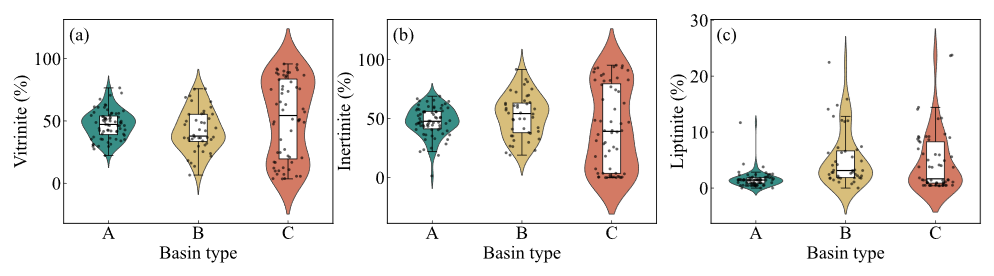

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import rcParams
import matplotlib
from mpl_toolkits.axes_grid1 import make_axes_locatable

matplotlib.use('TkAgg')
config = {
    "font.family": 'serif',
    "font.size": 16,
    "mathtext.fontset": 'stix',
    "font.serif": ['Times New Roman'],
    'axes.unicode_minus': False
}
rcParams.update(config)

# 读取Excel数据
file_path = r'D:\研究生学习\博士学习\论文3\数据集\工业分析元素分析焦油产率数据收集.xlsx'
df = pd.read_excel(file_path, sheet_name="分盆地汇总")

# 定义分析列
analysis_cols = ['Tar', 'M', 'A', 'V', 'FC', 'C', 'H', 'O', 'N', 'S']

# 定义工业分析和元素分析的标签
industrial_analysis_labels = {
'M': '$\mathregular{M_a}$$\mathregular{_d}$', 
'A': '$\mathregular{A_d}$', 
'V': '$\mathregular{V_d}$$\mathregular{_a}$$\mathregular{_f}$', 
'FC': '$\mathregular{FC_a}$$\mathregular{_d}$'}
elemental_analysis_labels = {
    'C': '$\mathregular{C_d}$$\mathregular{_a}$$\mathregular{_f}$', 
    'H': '$\mathregular{H_d}$$\mathregular{_a}$$\mathregular{_f}$', 
    'O': '$\mathregular{O_d}$$\mathregular{_a}$$\mathregular{_f}$', 
    'N': '$\mathregular{N_d}$$\mathregular{_a}$$\mathregular{_f}$', 
    'S': '$\mathregular{S_t}$$\mathregular{_,}$$\mathregular{_d}$'}

# 创建完整的列名映射
column_mapping = {
    'Tar': 'Tar',  # Tar产率
    **industrial_analysis_labels,
    **elemental_analysis_labels
}

# 获取所有盆地
basins = df['盆地'].unique()
all_datasets = [
    ('总数据', df[analysis_cols]),
    *[(basin, df[df['盆地'] == basin][analysis_cols]) for basin in basins]
]

# 创建画布，采用2行2列的子图布局
# plt.subplots(2, 2) 中的参数 2, 2 分别表示子图的行数和列数，即创建一个 2x2 的子图网格
# figsize=(16, 16) 表示设置整个画布的大小，宽和高均为 16 英寸
# constrained_layout=True 表示启用自动布局功能，自动调整子图、标题等元素的位置和间距，避免元素重叠
fig, axes = plt.subplots(2, 2, figsize=(16, 17.5), constrained_layout=True)
# 将二维的 axes 数组展平为一维数组，方便后续按顺序访问每个子图
axes = axes.flatten()

# 使用新的配色方案 (RdBu_r)
new_cmap = 'Blues'

# 绘制热力图
for i, (title, data) in enumerate(all_datasets):
    # 计算斯皮尔曼相关性
    #corr = data.corr(method='spearman')
    corr = data.corr()
    # 创建半角掩码（修改为不掩盖对角线）    
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # k=1表示从对角线+1开始掩盖
    # 绘制热力图
    ax = axes[i]
    # 获取完整列名列表
    full_column_names = [column_mapping[col] for col in analysis_cols]
    sns.heatmap(
        corr,
        mask=mask,
        ax=ax,
        cmap=new_cmap,  # 使用新的配色方案
        vmin=-1, vmax=1,
        center=0,
        square=True,
        linewidths=.5,
        cbar=False,  # 禁用默认的颜色条
        annot=True,
        fmt=".2f",
        annot_kws={"size": 16},
        xticklabels=full_column_names,  # 设置x轴标签
        yticklabels=full_column_names   # 设置y轴标签
    )

    # 旋转x轴标签以便更好地显示
    ax.set_xticklabels(full_column_names, fontsize=16)
    ax.set_yticklabels(full_column_names, fontsize=16)

    # 添加横向颜色条到下方
    # make_axes_locatable(ax)：将传入的坐标轴 ax 转换为可分割的对象，方便后续添加新的坐标轴
    # divider.append_axes("bottom", size="5%", pad=0.3)：在 ax 坐标轴的下方添加一个新的坐标轴作为颜色条的容器
    #   "bottom" 表示新坐标轴添加在原坐标轴下方
    #   size="5%" 表示新坐标轴的高度为原坐标轴高度的 5%
    #   pad=0.3 表示新坐标轴与原坐标轴之间的间距为原坐标轴高度的 0.3 倍
    # plt.colorbar(ax.collections[0], cax=cax, orientation='horizontal')：创建横向颜色条
    #   ax.collections[0]：指定要为哪个绘图对象添加颜色条，这里是热力图对象
    #   cax=cax：指定颜色条使用的坐标轴
    #   orientation='horizontal'：指定颜色条为横向显示
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="3%", pad=0.45)
    plt.colorbar(ax.collections[0], cax=cax, orientation='horizontal')


# 调整子图间距，各参数含义如下：
# bottom: 子图区域底部的位置，取值范围 0-1，此处设置为 0.15 表示子图区域底部位于画布高度的 15% 处
# hspace: 子图之间的垂直间距，为子图平均高度的倍数，此处设置为 0.4 可增大上下子图之间的间距
# wspace: 子图之间的水平间距，为子图平均宽度的倍数，此处设置为 0.2
# 其中 hspace 参数可以调整上下子图间距
plt.subplots_adjust(bottom=0.1, hspace=0.2, wspace=1)

# 保存高清图片
plt.savefig(r'D:\研究生学习\博士学习\论文3\绘图\分盆地斯皮尔曼相关性热力图.svg', dpi=600, bbox_inches='tight')

# 显示图形
plt.show()

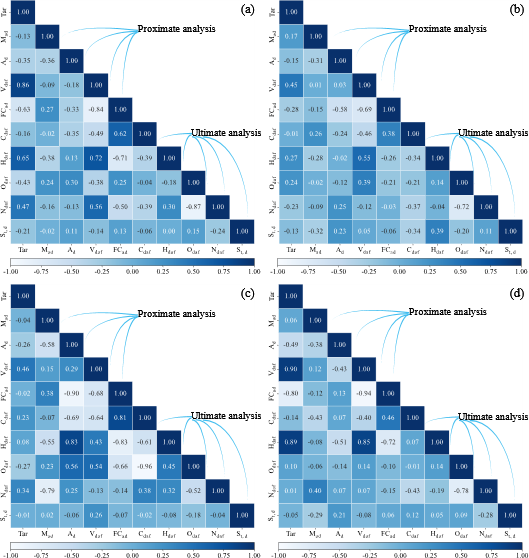

In [ ]:
import pandas as pd
import numpy
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import NullFormatter, FixedLocator
import matplotlib as mpl
from matplotlib import rcParams
from scipy import stats
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
# 读取Excel文件
df= pd.read_excel('D:\研究生学习\博士学习\论文3\数据集\不同机器学习预测值汇总.xlsx', sheet_name="RFtrain")


# 设置绘图的全局字体
config = {
    "font.family": 'serif',
    "font.size": 20,  # 12相当于小四大小
    "mathtext.fontset": 'stix',  # matplotlib渲染数学字体时使用的字体，和Times New Roman差别不大
    "font.serif": ['Times New Roman'],  # 宋体
    'axes.unicode_minus': False  # 处理负号，即-号
}
rcParams.update(config)
plt.rcParams['axes.linewidth'] = 1.5  # 设置子图边框宽度
plt.rcParams['axes.grid.axis'] = 'y'  # 设置为'y'表示只显示纵向网格线
plt.rcParams['axes.grid'] = True  # 开启网格线
plt.rcParams['grid.linestyle'] = '--'  # 设置网格线样式为虚线
plt.rcParams['grid.alpha'] = 0.5  # 设置网格线透明度
#plt.rcParams['axes.edgecolor'] = 'gray'  # 设置边框颜色为灰色
plt.rcParams['xtick.major.size'] = 6  # 设置x轴刻度线的大小
plt.rcParams['xtick.major.width'] = 1.5  # 设置x轴刻度线的宽度
plt.rcParams['ytick.major.size'] = 6  # 设置y轴刻度线的大小
plt.rcParams['ytick.major.width'] = 1.5  # 设置y轴刻度线的宽度
#plt.rcParams['font.size'] = 12  # 设置全局字体大小
#plt.rcParams['scatter.marker'] = 'x'  # 设置散点图形状为"x"
#plt.rcParams['scatter.color'] = 'r'  # 设置散点颜色为红色
#plt.rcParams['scatter.s'] = 100  # 设置散点大小为100
#plt.rcParams['lines.linestyle'] = '--'  # 设置线条样式为虚线





# 设置每个分类的颜色和标记
# 设置画布大小像素点
fig1= plt.figure(figsize=(12, 10), dpi=300)

#绘制散点图1
ax1 = plt.subplot(221)

plt.tick_params(axis='both', direction='in',)  # 刻度线设置
# 添加图例和标签
sns.regplot(x=df['真实all'], y=df['预测all'], ci=85,color='#007CB9',scatter_kws={'s':80,'color':'red','edgecolor': 'white'})
#plt.yticks(np.arange(-10, 50,10))  # 定义y轴刻度
# 在图上添加R方值
plt.text(0.25, 0.96, 'All samples', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.9, f'R$^2$=0.88', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.84, 'RMSE=1.62', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.78, 'MAE=1.18', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.95, 0.05, '(a)', ha='center', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.xlabel(r'$\mathrm{Tar}_{\mathrm{mea}}$(%)')
plt.ylabel(r'$\mathrm{Tar}_{\mathrm{RF}}$(%)')

#绘制散点图2
ax2 = plt.subplot(222)
plt.tick_params(axis='both', direction='in',)  # 刻度线设置
# 添加图例和标签
sns.regplot(x=df['真实A'], y=df['预测A'], ci=85,color='#007CB9',scatter_kws={'s':80,'color':'red','edgecolor': 'white'})
#plt.yticks(np.arange(-10, 50,10))  # 定义y轴刻度

# 在图上添加R方值
plt.text(0.25, 0.96, 'Basin A', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.9, f'R$^2$=0.64', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.84, 'RMSE=1.28', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.78, 'MAE=0.98', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.95, 0.05, '(b)', ha='center', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.xlabel(r'$\mathrm{Tar}_{\mathrm{mea}}$(%)')
#plt.ylabel(r'$Tar_{RF}$')
plt.ylabel(r'$\mathrm{Tar}_{\mathrm{RF}}$(%)')

#绘制散点图3
ax3 = plt.subplot(223)
plt.tick_params(axis='both', direction='in',)  # 刻度线设置
# 添加图例和标签
sns.regplot(x=df['真实B'], y=df['预测B'], ci=85,color='#007CB9',scatter_kws={'s':80,'color':'red','edgecolor': 'white'})
#plt.yticks(np.arange(-10, 50,10))  # 定义y轴刻度

# 在图上添加R方值
plt.text(0.25, 0.96, 'Basin B', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.9, f'R$^2$=0.84', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.84, 'RMSE=0.93', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.78, 'MAE=0.69', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.95, 0.05, '(c)', ha='center', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.xlabel(r'$\mathrm{Tar}_{\mathrm{mea}}$(%)')
#plt.ylabel(r'$Tar_{RF}$')
plt.ylabel(r'$\mathrm{Tar}_{\mathrm{RF}}$(%)')

#绘制散点图4
ax3 = plt.subplot(224)
plt.tick_params(axis='both', direction='in',)  # 刻度线设置
# 添加图例和标签
sns.regplot(x=df['真实C'], y=df['预测C'], ci=85,color='#007CB9',scatter_kws={'s':80,'color':'red','edgecolor': 'white'})

# 在图上添加R方值
plt.text(0.25, 0.96, 'Basin C', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.9, f'R$^2$=0.91', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.84, 'RMSE=1.74', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.78, 'MAE=1.18', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.95, 0.05, '(d)', ha='center', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.xlabel(r'$\mathrm{Tar}_{\mathrm{mea}}$(%)')
#plt.ylabel(r'$Tar_{RF}$')
plt.ylabel(r'$\mathrm{Tar}_{\mathrm{RF}}$(%)')
#plt.yticks(fontstyle='normal')
# 最后设置画布边距和子图间距 wspace，hspace 控制子图间距。
fig1.subplots_adjust(left=0.1, right=0.98, top=0.98, bottom=0.07,
                    wspace=0.2, hspace=0.2)
                    

plt.tight_layout(pad=0.5, w_pad=0.3, h_pad=0.3)
plt.savefig("D:\研究生学习\博士学习\论文3\绘图\RF模型不同盆地对比.svg")

# 显示图形
plt.show()

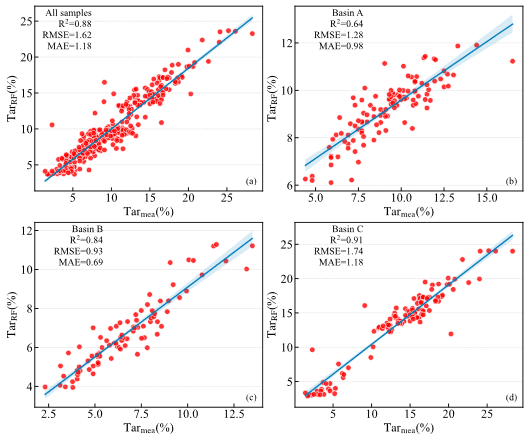

In [ ]:
import pandas as pd
import numpy
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import NullFormatter, FixedLocator
import matplotlib as mpl
from matplotlib import rcParams
from scipy import stats
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
# 读取Excel文件
df= pd.read_excel('D:\研究生学习\博士学习\论文3\数据集\不同机器学习预测值汇总.xlsx', sheet_name="MLPtrain")


# 设置绘图的全局字体
config = {
    "font.family": 'serif',
    "font.size": 20,  # 12相当于小四大小
    "mathtext.fontset": 'stix',  # matplotlib渲染数学字体时使用的字体，和Times New Roman差别不大
    "font.serif": ['Times New Roman'],  # 宋体
    'axes.unicode_minus': False  # 处理负号，即-号
}
rcParams.update(config)
plt.rcParams['axes.linewidth'] = 1.5  # 设置子图边框宽度
plt.rcParams['axes.grid.axis'] = 'y'  # 设置为'y'表示只显示纵向网格线
plt.rcParams['axes.grid'] = True  # 开启网格线
plt.rcParams['grid.linestyle'] = '--'  # 设置网格线样式为虚线
plt.rcParams['grid.alpha'] = 0.5  # 设置网格线透明度
#plt.rcParams['axes.edgecolor'] = 'gray'  # 设置边框颜色为灰色
plt.rcParams['xtick.major.size'] = 6  # 设置x轴刻度线的大小
plt.rcParams['xtick.major.width'] = 1.5  # 设置x轴刻度线的宽度
plt.rcParams['ytick.major.size'] = 6  # 设置y轴刻度线的大小
plt.rcParams['ytick.major.width'] = 1.5  # 设置y轴刻度线的宽度
#plt.rcParams['font.size'] = 12  # 设置全局字体大小
#plt.rcParams['scatter.marker'] = 'x'  # 设置散点图形状为"x"
#plt.rcParams['scatter.color'] = 'r'  # 设置散点颜色为红色
#plt.rcParams['scatter.s'] = 100  # 设置散点大小为100
#plt.rcParams['lines.linestyle'] = '--'  # 设置线条样式为虚线





# 设置每个分类的颜色和标记
# 设置画布大小像素点
fig1= plt.figure(figsize=(12, 10), dpi=300)

#绘制散点图1
ax1 = plt.subplot(221)

plt.tick_params(axis='both', direction='in',)  # 刻度线设置
# 添加图例和标签
sns.regplot(x=df['真实all'], y=df['预测all'], ci=85,color='#007CB9',scatter_kws={'s':80,'color':'#1f77b4','edgecolor': 'white'})
#plt.yticks(np.arange(-10, 50,10))  # 定义y轴刻度
# 在图上添加R方值
plt.text(0.25, 0.96, 'All samples', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.9, f'R$^2$=0.93', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.84, 'RMSE=1.27', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.78, 'MAE=0.95', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.95, 0.05, '(a)', ha='center', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.xlabel(r'$\mathrm{Tar}_{\mathrm{mea}}$(%)')
plt.ylabel(r'$\mathrm{Tar}_{\mathrm{MLP}}$(%)')

#绘制散点图2
ax2 = plt.subplot(222)
plt.tick_params(axis='both', direction='in',)  # 刻度线设置
# 添加图例和标签
sns.regplot(x=df['真实A'], y=df['预测A'], ci=85,color='#007CB9',scatter_kws={'s':80,'color':'red','edgecolor': 'white'})
#plt.yticks(np.arange(-10, 50,10))  # 定义y轴刻度

# 在图上添加R方值
plt.text(0.25, 0.96, 'Basin A', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.9, f'R$^2$=0.83', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.84, 'RMSE=0.87', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.78, 'MAE=0.66', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.95, 0.05, '(b)', ha='center', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.xlabel(r'$\mathrm{Tar}_{\mathrm{mea}}$(%)')
#plt.ylabel(r'$Tar_{RF}$')
plt.ylabel(r'$\mathrm{Tar}_{\mathrm{RMLPF}}$(%)')

#绘制散点图3
ax3 = plt.subplot(223)
plt.tick_params(axis='both', direction='in',)  # 刻度线设置
# 添加图例和标签
sns.regplot(x=df['真实B'], y=df['预测B'], ci=85,color='#007CB9',scatter_kws={'s':80,'color':'red','edgecolor': 'white'})
#plt.yticks(np.arange(-10, 50,10))  # 定义y轴刻度

# 在图上添加R方值
plt.text(0.25, 0.96, 'Basin B', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.9, f'R$^2$=0.73', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.84, 'RMSE=1.19', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.78, 'MAE=0.87', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.95, 0.05, '(c)', ha='center', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.xlabel(r'$\mathrm{Tar}_{\mathrm{mea}}$(%)')
#plt.ylabel(r'$Tar_{RF}$')
plt.ylabel(r'$\mathrm{Tar}_{\mathrm{MLP}}$(%)')

#绘制散点图4
ax3 = plt.subplot(224)
plt.tick_params(axis='both', direction='in',)  # 刻度线设置
# 添加图例和标签
sns.regplot(x=df['真实C'], y=df['预测C'], ci=85,color='#007CB9',scatter_kws={'s':80,'color':'red','edgecolor': 'white'})

# 在图上添加R方值
plt.text(0.25, 0.96, 'Basin C', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.9, f'R$^2$=0.91', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.84, 'RMSE=1.76', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.78, 'MAE=1.28', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.95, 0.05, '(d)', ha='center', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.xlabel(r'$\mathrm{Tar}_{\mathrm{mea}}$(%)')
#plt.ylabel(r'$Tar_{RF}$')
plt.ylabel(r'$\mathrm{Tar}_{\mathrm{MLP}}$(%)')
#plt.yticks(fontstyle='normal')
# 最后设置画布边距和子图间距 wspace，hspace 控制子图间距。
fig1.subplots_adjust(left=0.1, right=0.98, top=0.98, bottom=0.07,
                    wspace=0.2, hspace=0.2)
                    

plt.tight_layout(pad=0.5, w_pad=0.3, h_pad=0.3)
plt.savefig("D:\研究生学习\博士学习\论文3\绘图\MLP模型不同盆地对比.svg")

# 显示图形
plt.show()

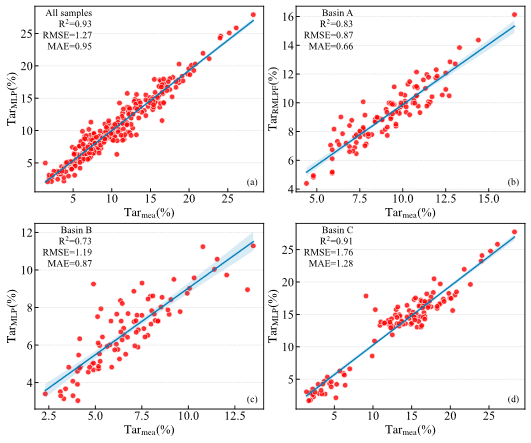

In [ ]:
import pandas as pd
import numpy
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import NullFormatter, FixedLocator
import matplotlib as mpl
from matplotlib import rcParams
from scipy import stats
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
# 读取Excel文件
df= pd.read_excel('D:\研究生学习\博士学习\论文3\数据集\不同机器学习预测值汇总.xlsx', sheet_name="XGtrain")


# 设置绘图的全局字体
config = {
    "font.family": 'serif',
    "font.size": 20,  # 12相当于小四大小
    "mathtext.fontset": 'stix',  # matplotlib渲染数学字体时使用的字体，和Times New Roman差别不大
    "font.serif": ['Times New Roman'],  # 宋体
    'axes.unicode_minus': False  # 处理负号，即-号
}
rcParams.update(config)
plt.rcParams['axes.linewidth'] = 1.5  # 设置子图边框宽度
plt.rcParams['axes.grid.axis'] = 'y'  # 设置为'y'表示只显示纵向网格线
plt.rcParams['axes.grid'] = True  # 开启网格线
plt.rcParams['grid.linestyle'] = '--'  # 设置网格线样式为虚线
plt.rcParams['grid.alpha'] = 0.5  # 设置网格线透明度
#plt.rcParams['axes.edgecolor'] = 'gray'  # 设置边框颜色为灰色
plt.rcParams['xtick.major.size'] = 6  # 设置x轴刻度线的大小
plt.rcParams['xtick.major.width'] = 1.5  # 设置x轴刻度线的宽度
plt.rcParams['ytick.major.size'] = 6  # 设置y轴刻度线的大小
plt.rcParams['ytick.major.width'] = 1.5  # 设置y轴刻度线的宽度
#plt.rcParams['font.size'] = 12  # 设置全局字体大小
#plt.rcParams['scatter.marker'] = 'x'  # 设置散点图形状为"x"
#plt.rcParams['scatter.color'] = 'r'  # 设置散点颜色为红色
#plt.rcParams['scatter.s'] = 100  # 设置散点大小为100
#plt.rcParams['lines.linestyle'] = '--'  # 设置线条样式为虚线





# 设置每个分类的颜色和标记
# 设置画布大小像素点
fig1= plt.figure(figsize=(12, 10), dpi=300)

#绘制散点图1
ax1 = plt.subplot(221)

plt.tick_params(axis='both', direction='in',)  # 刻度线设置
# 添加图例和标签
sns.regplot(x=df['真实all'], y=df['预测all'], ci=85,color='#007CB9',scatter_kws={'s':80,'color':'red','edgecolor': 'white'})
#plt.yticks(np.arange(-10, 50,10))  # 定义y轴刻度
# 在图上添加R方值
plt.text(0.25, 0.96, 'All samples', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.9, f'R$^2$=0.94', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.84, 'RMSE=1.1', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.78, 'MAE=0.82', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.95, 0.05, '(a)', ha='center', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.xlabel(r'$\mathrm{Tar}_{\mathrm{mea}}$(%)')
plt.ylabel(r'$\mathrm{Tar}_{\mathrm{XGBoost}}$(%)')

#绘制散点图2
ax2 = plt.subplot(222)
plt.tick_params(axis='both', direction='in',)  # 刻度线设置
# 添加图例和标签
sns.regplot(x=df['真实A'], y=df['预测A'], ci=85,color='#007CB9',scatter_kws={'s':80,'color':'red','edgecolor': 'white'})
#plt.yticks(np.arange(-10, 50,10))  # 定义y轴刻度

# 在图上添加R方值
plt.text(0.25, 0.96, 'Basin A', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.9, f'R$^2$=0.70', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.84, 'RMSE=1.17', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.78, 'MAE=0.91', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.95, 0.05, '(b)', ha='center', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.xlabel(r'$\mathrm{Tar}_{\mathrm{mea}}$(%)')
#plt.ylabel(r'$Tar_{RF}$')
plt.ylabel(r'$\mathrm{Tar}_{\mathrm{XGBoost}}$(%)')

#绘制散点图3
ax3 = plt.subplot(223)
plt.tick_params(axis='both', direction='in',)  # 刻度线设置
# 添加图例和标签
sns.regplot(x=df['真实B'], y=df['预测B'], ci=85,color='#007CB9',scatter_kws={'s':80,'color':'red','edgecolor': 'white'})
#plt.yticks(np.arange(-10, 50,10))  # 定义y轴刻度

# 在图上添加R方值
plt.text(0.25, 0.96, 'Basin B', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.9, f'R$^2$=0.88', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.84, 'RMSE=0.77', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.78, 'MAE=0.56', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.95, 0.05, '(c)', ha='center', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.xlabel(r'$\mathrm{Tar}_{\mathrm{mea}}$(%)')
#plt.ylabel(r'$Tar_{RF}$')
plt.ylabel(r'$\mathrm{Tar}_{\mathrm{XGBoost}}$(%)')

#绘制散点图4
ax3 = plt.subplot(224)
plt.tick_params(axis='both', direction='in',)  # 刻度线设置
# 添加图例和标签
sns.regplot(x=df['真实C'], y=df['预测C'], ci=85,color='#007CB9',scatter_kws={'s':80,'color':'red','edgecolor': 'white'})

# 在图上添加R方值
plt.text(0.25, 0.96, 'Basin C', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.9, f'R$^2$=0.92', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.84, 'RMSE=1.63', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.78, 'MAE=1.25', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.95, 0.05, '(d)', ha='center', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.xlabel(r'$\mathrm{Tar}_{\mathrm{mea}}$(%)')
#plt.ylabel(r'$Tar_{RF}$')
plt.ylabel(r'$\mathrm{Tar}_{\mathrm{XGBoost}}$(%)')
#plt.yticks(fontstyle='normal')
# 最后设置画布边距和子图间距 wspace，hspace 控制子图间距。
fig1.subplots_adjust(left=0.1, right=0.98, top=0.98, bottom=0.07,
                    wspace=0.2, hspace=0.2)
                    

plt.tight_layout(pad=0.5, w_pad=0.3, h_pad=0.3)
plt.savefig("D:\研究生学习\博士学习\论文3\绘图\XG模型不同盆地对比.svg")

# 显示图形
plt.show()

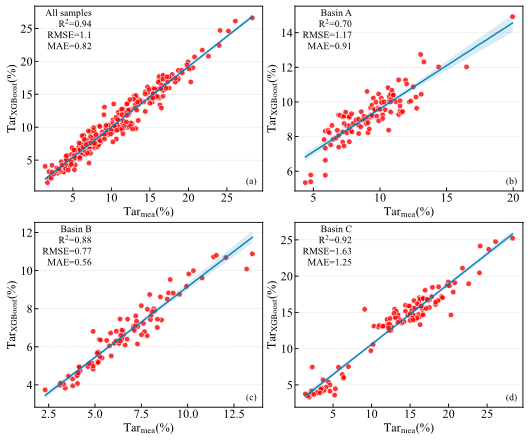

In [ ]:
import pandas as pd
import numpy
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import NullFormatter, FixedLocator
import matplotlib as mpl
from matplotlib import rcParams
from scipy import stats
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
# 读取Excel文件
df= pd.read_excel('D:\研究生学习\博士学习\论文3\数据集\不同机器学习预测值汇总.xlsx', sheet_name="Tabtrain")


# 设置绘图的全局字体
config = {
    "font.family": 'serif',
    "font.size": 20,  # 12相当于小四大小
    "mathtext.fontset": 'stix',  # matplotlib渲染数学字体时使用的字体，和Times New Roman差别不大
    "font.serif": ['Times New Roman'],  # 宋体
    'axes.unicode_minus': False  # 处理负号，即-号
}
rcParams.update(config)
plt.rcParams['axes.linewidth'] = 1.5  # 设置子图边框宽度
plt.rcParams['axes.grid.axis'] = 'y'  # 设置为'y'表示只显示纵向网格线
plt.rcParams['axes.grid'] = True  # 开启网格线
plt.rcParams['grid.linestyle'] = '--'  # 设置网格线样式为虚线
plt.rcParams['grid.alpha'] = 0.5  # 设置网格线透明度
#plt.rcParams['axes.edgecolor'] = 'gray'  # 设置边框颜色为灰色
plt.rcParams['xtick.major.size'] = 6  # 设置x轴刻度线的大小
plt.rcParams['xtick.major.width'] = 1.5  # 设置x轴刻度线的宽度
plt.rcParams['ytick.major.size'] = 6  # 设置y轴刻度线的大小
plt.rcParams['ytick.major.width'] = 1.5  # 设置y轴刻度线的宽度
#plt.rcParams['font.size'] = 12  # 设置全局字体大小
#plt.rcParams['scatter.marker'] = 'x'  # 设置散点图形状为"x"
#plt.rcParams['scatter.color'] = 'r'  # 设置散点颜色为红色
#plt.rcParams['scatter.s'] = 100  # 设置散点大小为100
#plt.rcParams['lines.linestyle'] = '--'  # 设置线条样式为虚线





# 设置每个分类的颜色和标记
# 设置画布大小像素点
fig1= plt.figure(figsize=(12, 10), dpi=300)

#绘制散点图1
ax1 = plt.subplot(221)

plt.tick_params(axis='both', direction='in',)  # 刻度线设置
# 添加图例和标签
sns.regplot(x=df['真实all'], y=df['预测all'], ci=85,color='#007CB9',scatter_kws={'s':80,'color':'red','edgecolor': 'white'})
#plt.yticks(np.arange(-10, 50,10))  # 定义y轴刻度
# 在图上添加R方值
plt.text(0.25, 0.96, 'All samples', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.9, f'R$^2$=0.92', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.84, 'RMSE=1.38', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.78, 'MAE=1.01', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.95, 0.05, '(a)', ha='center', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.xlabel(r'$\mathrm{Tar}_{\mathrm{mea}}$(%)')
plt.ylabel(r'$\mathrm{Tar}_{\mathrm{TabPFN}}$(%)')

#绘制散点图2
ax2 = plt.subplot(222)
plt.tick_params(axis='both', direction='in',)  # 刻度线设置
# 添加图例和标签
sns.regplot(x=df['真实A'], y=df['预测A'], ci=85,color='#007CB9',scatter_kws={'s':80,'color':'red','edgecolor': 'white'})
#plt.yticks(np.arange(-10, 50,10))  # 定义y轴刻度

# 在图上添加R方值
plt.text(0.25, 0.96, 'Basin A', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.9, f'R$^2$=0.71', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.84, 'RMSE=1.16', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.78, 'MAE=0.83', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.95, 0.05, '(b)', ha='center', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.xlabel(r'$\mathrm{Tar}_{\mathrm{mea}}$(%)')
#plt.ylabel(r'$Tar_{RF}$')
plt.ylabel(r'$\mathrm{Tar}_{\mathrm{TabPFN}}$(%)')

#绘制散点图3
ax3 = plt.subplot(223)
plt.tick_params(axis='both', direction='in',)  # 刻度线设置
# 添加图例和标签
sns.regplot(x=df['真实B'], y=df['预测B'], ci=85,color='#007CB9',scatter_kws={'s':80,'color':'red','edgecolor': 'white'})
#plt.yticks(np.arange(-10, 50,10))  # 定义y轴刻度

# 在图上添加R方值
plt.text(0.25, 0.96, 'Basin B', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.9, f'R$^2$=0.89', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.84, 'RMSE=0.74', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.78, 'MAE=0.54', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.95, 0.05, '(c)', ha='center', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.xlabel(r'$\mathrm{Tar}_{\mathrm{mea}}$(%)')
#plt.ylabel(r'$Tar_{RF}$')
plt.ylabel(r'$\mathrm{Tar}_{\mathrm{TabPFN}}$(%)')

#绘制散点图4
ax3 = plt.subplot(224)
plt.tick_params(axis='both', direction='in',)  # 刻度线设置
# 添加图例和标签
sns.regplot(x=df['真实C'], y=df['预测C'], ci=85,color='#007CB9',scatter_kws={'s':80,'color':'red','edgecolor': 'white'})

# 在图上添加R方值
plt.text(0.25, 0.96, 'Basin C', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.9, f'R$^2$=0.94', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.84, 'RMSE=1.36', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.25, 0.78, 'MAE=1.04', ha='right', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.text(0.95, 0.05, '(d)', ha='center', va='center', transform=plt.gca().transAxes, fontsize=16)
plt.xlabel(r'$\mathrm{Tar}_{\mathrm{mea}}$(%)')
#plt.ylabel(r'$Tar_{RF}$')
plt.ylabel(r'$\mathrm{Tar}_{\mathrm{TabPFN}}$(%)')
#plt.yticks(fontstyle='normal')
# 最后设置画布边距和子图间距 wspace，hspace 控制子图间距。
fig1.subplots_adjust(left=0.1, right=0.98, top=0.98, bottom=0.07,
                    wspace=0.2, hspace=0.2)
                    

plt.tight_layout(pad=0.5, w_pad=0.3, h_pad=0.3)
plt.savefig("D:\研究生学习\博士学习\论文3\绘图\Tab模型不同盆地对比.svg")

# 显示图形
plt.show()

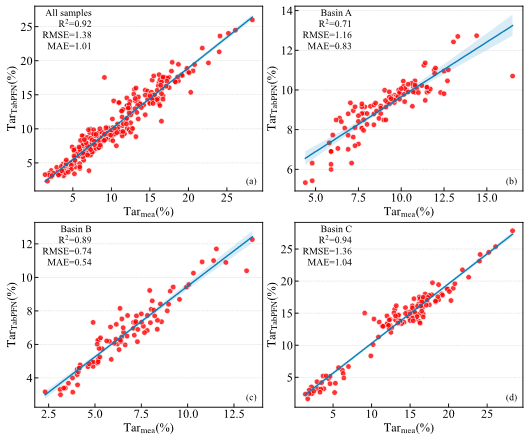

In [3]:
# 导入必要的库
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
from scipy import stats
import matplotlib
import time  # 导入time模块
import os
from sklearn.neural_network import MLPRegressor
# 导入TabPFN模型
from tabpfn import TabPFNRegressor

matplotlib.use('TkAgg')

# 记录程序开始时间
start_time = time.time()

config = {
    "font.family": 'serif',
    "font.size": 12,  # 相当于小四大小
    "mathtext.fontset": 'stix',  # matplotlib渲染数学字体时使用的字体，和Times New Roman差别不大
    "font.serif": ['STSong'],  # 宋体
    'axes.unicode_minus': False  # 处理负号，即-号
}
rcParams.update(config)

# 修改数据读取部分：读取已划分好的训练集和测试集
# 请确保Excel文件路径正确
excel_path = r'D:\研究生学习\博士学习\论文3\数据集\工业分析元素分析焦油产率数据归一化2.xlsx'  # 替换为实际文件路径
train_data = pd.read_excel(excel_path, sheet_name='alltrain')
test_data = pd.read_excel(excel_path, sheet_name='alltest')

# 提取特征和目标变量
X_train = train_data.loc[:,  "A":"N"]  # 特征列从M到S
y_train = train_data["Tar"]
X_test = test_data.loc[:,  "A":"N"]
y_test = test_data["Tar"]

# 定义MLP模型超参数分布，为模型进行参数寻优
param_dist = {
    'hidden_layer_sizes': [ (50, 50), (100, 50), (100, 100)],  # 隐藏层结构
    'activation': ['relu', 'tanh', 'logistic'],  # 激活函数
    'solver': ['adam', 'lbfgs', 'sgd'],  # 优化算法
    'solver': ['adam', 'lbfgs', 'sgd'],  # 优化算法
    'alpha': [0.0001, 0.001, 0.01, 0.1],  # L2正则化参数
    'learning_rate': ['constant', 'invscaling', 'adaptive'],  # 学习率策略
    'max_iter': [100, 200, 300, 400],  # 最大迭代次数
    'batch_size': [16, 32, 64, 128]  # 批量大小
}
# 创建MLP模型
model = MLPRegressor(random_state=42)

# 设置5折交叉验证
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 初始化随机搜索
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=100,  # 尝试30种不同的参数组合
    cv=cv,
    scoring='neg_root_mean_squared_error',  # 使用RMSE作为评估指标
    n_jobs=-1,  # 使用所有CPU核心
    verbose=2,  # 显示详细信息
    random_state=42
)

# 执行随机搜索
print("开始随机搜索最优参数...")
random_search.fit(X_train, y_train)

# 获取最优模型
best_model = random_search.best_estimator_
print(f"最佳参数组合: {random_search.best_params_}")
print(f"交叉验证最佳RMSE: {-random_search.best_score_:.4f}")

# 在测试集上评估性能
y_test_pred = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)

print("\n测试集最终评估指标:")
print(f"R²: {test_r2:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}, RMSE: {test_rmse:.4f}")

# 准备结果存储
results = []

# 打印每个参数组合的训练集和测试集指标
print("\n每个参数组合的评估结果：")
for i, params in enumerate(random_search.cv_results_['params']):
    # 获取当前参数组合的模型
    current_model = MLPRegressor(random_state=42, **params)
    current_model.fit(X_train, y_train)
    
    # 在训练集和测试集上预测
    y_train_pred = current_model.predict(X_train)
    y_test_pred = current_model.predict(X_test)
    
    # 计算评估指标
    train_r2 = r2_score(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    
    # 保存结果
    result = {
        '参数组合': i + 1,
        **params,
        '训练集_R2': train_r2,
        '训练集_MAE': train_mae,
        '训练集_MSE': train_mse,
        '训练集_RMSE': train_rmse,
        '测试集_R2': test_r2,
        '测试集_MAE': test_mae,
        '测试集_MSE': test_mse,
        '测试集_RMSE': test_rmse,
        '交叉验证_RMSE': -random_search.cv_results_['mean_test_score'][i]
    }
    results.append(result)
    
    # 打印结果
    print(f"\n参数组合 {i + 1}:")
    print(f"参数: {params}")
    print(f"训练集 - R²: {train_r2:.4f}, MAE: {train_mae:.4f}, MSE: {train_mse:.4f}, RMSE: {train_rmse:.4f}")
    print(f"测试集 - R²: {test_r2:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}, RMSE: {test_rmse:.4f}")
    print(f"交叉验证 - RMSE: {-random_search.cv_results_['mean_test_score'][i]:.4f}")

# 转换为DataFrame并保存到Excel
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='测试集_R2', ascending=False)  # 按测试集R²排序

# 指定保存文件路径
save_dir = r'D:\研究生学习\博士学习\论文3\数据集\模型参数'
excel_path = os.path.join(save_dir, 'MLP随机搜索结果all.xlsx')

# 保存到Excel
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    results_df.to_excel(writer, sheet_name='参数搜索结果', index=False)
    
    # 添加一个汇总表
    best_result = results_df.iloc[0].copy()
    pd.DataFrame(best_result).T.to_excel(writer, sheet_name='最佳参数', index=False)

print(f"\n所有参数组合的评估结果已保存至: {excel_path}")

# 计算并输出总运行时间
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\n代码运行时间：{elapsed_time:.2f} 秒")

开始随机搜索最优参数...
Fitting 5 folds for each of 100 candidates, totalling 500 fits


E:\anacoda3\envs\DL\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


最佳参数组合: {'solver': 'lbfgs', 'max_iter': 200, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (50, 50), 'batch_size': 32, 'alpha': 0.1, 'activation': 'relu'}
交叉验证最佳RMSE: 2.0230

测试集最终评估指标:
R²: 0.8738, MAE: 1.3626, MSE: 3.3645, RMSE: 1.8343

每个参数组合的评估结果：


E:\anacoda3\envs\DL\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
E:\anacoda3\envs\DL\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



参数组合 1:
参数: {'solver': 'sgd', 'max_iter': 400, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (50, 50), 'batch_size': 128, 'alpha': 0.01, 'activation': 'logistic'}
训练集 - R²: 0.4032, MAE: 2.9018, MSE: 14.1123, RMSE: 3.7566
测试集 - R²: 0.4167, MAE: 3.2417, MSE: 15.5501, RMSE: 3.9434
交叉验证 - RMSE: 4.8665

参数组合 2:
参数: {'solver': 'lbfgs', 'max_iter': 200, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (50, 50), 'batch_size': 32, 'alpha': 0.1, 'activation': 'relu'}
训练集 - R²: 0.8995, MAE: 1.1581, MSE: 2.3759, RMSE: 1.5414
测试集 - R²: 0.8738, MAE: 1.3626, MSE: 3.3645, RMSE: 1.8343
交叉验证 - RMSE: 2.0230


...

E:\anacoda3\envs\DL\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



参数组合 95:
参数: {'solver': 'lbfgs', 'max_iter': 300, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (100, 50), 'batch_size': 128, 'alpha': 0.01, 'activation': 'relu'}
训练集 - R²: 0.9173, MAE: 1.0492, MSE: 1.9563, RMSE: 1.3987
测试集 - R²: 0.8867, MAE: 1.2400, MSE: 3.0204, RMSE: 1.7379
交叉验证 - RMSE: 2.2494


E:\anacoda3\envs\DL\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(



参数组合 96:
参数: {'solver': 'sgd', 'max_iter': 100, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (100, 50), 'batch_size': 32, 'alpha': 0.01, 'activation': 'logistic'}
训练集 - R²: 0.3182, MAE: 3.1290, MSE: 16.1226, RMSE: 4.0153
测试集 - R²: 0.3284, MAE: 3.5210, MSE: 17.9060, RMSE: 4.2315
交叉验证 - RMSE: 4.5833

参数组合 97:
参数: {'solver': 'adam', 'max_iter': 400, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (50, 50), 'batch_size': 32, 'alpha': 0.1, 'activation': 'relu'}
训练集 - R²: 0.8153, MAE: 1.5466, MSE: 4.3670, RMSE: 2.0897
测试集 - R²: 0.8761, MAE: 1.3718, MSE: 3.3040, RMSE: 1.8177
交叉验证 - RMSE: 2.1960

参数组合 98:
参数: {'solver': 'sgd', 'max_iter': 300, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (100, 100), 'batch_size': 32, 'alpha': 0.001, 'activation': 'tanh'}
训练集 - R²: 0.8181, MAE: 1.5169, MSE: 4.3015, RMSE: 2.0740
测试集 - R²: 0.8804, MAE: 1.3633, MSE: 3.1881, RMSE: 1.7855
交叉验证 - RMSE: 2.2109

参数组合 99:
参数: {'solver': 'sgd', 'max_iter': 300, 'learning_rate': 'constant', 'hidden_layer_s

E:\anacoda3\envs\DL\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [5]:
# 导入必要的库
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
from scipy import stats
import matplotlib
import time  # 导入time模块
# 导入MLP相关库
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
matplotlib.use('TkAgg')

# 记录程序开始时间
start_time = time.time()

# 训练计时开始
train_start = time.time()


config = {
    "font.family": 'serif',
    "font.size": 12,  # 相当于小四大小
    "mathtext.fontset": 'stix',  # matplotlib渲染数学字体时使用的字体，和Times New Roman差别不大
    "font.serif": ['STSong'],  # 宋体
    'axes.unicode_minus': False  # 处理负号，即-号
}
rcParams.update(config)

# 读取Excel数据
excel_path = 'D:\研究生学习\博士学习\论文3\数据集\工业分析元素分析焦油产率数据归一化2.xlsx'  # 替换为实际文件路径
train_data = pd.read_excel(excel_path, sheet_name='alltrain')
test_data = pd.read_excel(excel_path, sheet_name='alltest')

# 提取特征和目标变量
X_train = train_data.loc[:,  "A":"N"]  # 特征列从M到S
y_train = train_data["Tar"]
X_test = test_data.loc[:,  "A":"N"]
y_test = test_data["Tar"]




# 建立MLP回归模型
model = MLPRegressor(
    hidden_layer_sizes=(50, 50),  # 增加隐藏层数量和神经元数量，增强模型复杂度
    activation='tanh',  # 激活函数，'relu' 表示使用修正线性单元函数，用于在神经元中引入非线性特性
    solver='lbfgs',  # 权重优化的求解器，'adam' 是一种基于自适应矩估计的优化算法，适用于较大数据集和较高维度的问题
    alpha=0.1,  # 减小L2正则化项参数，降低正则化强度，帮助模型更好拟合数据
    batch_size='auto',  # 训练模型时的批次大小，'auto' 表示批次大小为min(200, n_samples)
    learning_rate='constant',  # 学习率策略，'adaptive' 表示当训练损失在连续两次迭代中没有改善时，学习率会自动降低
    max_iter=400,  # 增加最大迭代次数，让模型有更多机会学习数据特征
    #early_stopping=True,  # 是否启用早停机制，若为True，则在验证集上的性能连续多次迭代没有改善时停止训练
    #validation_fraction=0.1,  # 当启用早停机制时，从训练集中划分出作为验证集的比例，这里表示划分10%的数据作为验证集
    random_state=42  # 随机数种子，保证每次运行代码时模型的初始化和数据划分结果一致，方便复现实验结果
)
model.fit(X_train, y_train)
train_end = time.time()
print(f"\n模型训练耗时：{train_end - train_start:.4f} 秒")

# 训练集预测计时开始
predict_start = time.time()
# 预测训练集
x_pred = model.predict(X_train)
predict_end = time.time()
print(f"训练集预测耗时：{predict_end - predict_start:.4f} 秒")

# 预测测试集
y_pred = model.predict(X_test)
end_time = time.time()


# 计算并输出总运行时间
elapsed_time = end_time - start_time
print(f"\n代码运行时间：{elapsed_time:.4f} 秒")
# 评估模型
MSE = mean_squared_error(y_train, x_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y_train, x_pred)
R2 = r2_score(y_train, x_pred)
train_mape = (abs((y_train - x_pred) / y_train)).mean() * 100

test_mape = (abs((y_test - y_pred) / y_test)).mean() * 100
mse = mean_squared_error(y_test, y_pred)
rmse= np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# 收集评估结果
evaluation_data = {
    '指标': ['训练集MSE', '训练集RMSE', '训练集MAE', '训练集R²', '训练集MAPE',
            '测试集MSE', '测试集RMSE', '测试集MAE', '测试集R²', '测试集MAPE'],
    '值': [MSE, RMSE, MAE, R2, train_mape,
          mse, rmse, mae, r2, test_mape]
}

# 将评估结果转换为DataFrame
evaluation_df = pd.DataFrame(evaluation_data)
# 打印评估结果
print(f'Mean Squared Error (MSE): {MSE:.4f}')
print(f'Root Mean Squared Error (RMSE): {RMSE:.4f}')
print(f'Mean Absolute Error (MAE): {MAE:.4f}')
print(f'R² Score: {R2:.4f}')
print(f'Mean Absolute Percentage Error (MAPE) for Training Data: {train_mape:.4f}%')
print(f'Mean Absolute Percentage Error (MAPE) for Testing Data: {test_mape:.4f}%')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R² Score: {r2:.4f}')

# 创建包含真实Y值和预测Y值的DataFrame
train_results = pd.DataFrame({'真实Y值':y_train.values , '预测Y值': x_pred})
test_results = pd.DataFrame({'真实Y值': y_test.values, '预测Y值': y_pred})


# feature_importances_df.to_excel(...)

# 修改结果文件名
with pd.ExcelWriter('D:\研究生学习\博士学习\论文3\数据集\模型参数\MLP训练测试结果盆地all.xlsx') as writer:
    train_results.to_excel(writer, sheet_name='train', index=False)
    test_results.to_excel(writer, sheet_name='test', index=False)
    evaluation_df.to_excel(writer, sheet_name='评估结果', index=False)




模型训练耗时：0.8369 秒
训练集预测耗时：0.0032 秒

代码运行时间：0.8410 秒
Mean Squared Error (MSE): 1.5404
Root Mean Squared Error (RMSE): 1.2411
Mean Absolute Error (MAE): 0.9363
R² Score: 0.9349
Mean Absolute Percentage Error (MAPE) for Training Data: 11.9870%
Mean Absolute Percentage Error (MAPE) for Testing Data: 17.7104%
Mean Squared Error (MSE): 4.0563
Root Mean Squared Error (RMSE): 2.0140
Mean Absolute Error (MAE): 1.4157
R² Score: 0.8479


E:\anacoda3\envs\DL\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [ ]:
# 导入必要的库
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
from scipy import stats
import matplotlib
import warnings
import re
import shap
import os
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.neural_network import MLPRegressor
import matplotlib.colors as mcolors
import time  # 导入time模块
from sklearn.ensemble import RandomForestRegressor  # 导入随机森林回归模型
import pickle  # 添加pickle库用于加载归一化参数
matplotlib.use('TkAgg')

# 记录程序开始时间
start_time = time.time()


config = {
    "font.family": 'serif',
    "font.size": 16,  # 相当于小四大小
    "mathtext.fontset": 'stix',  # matplotlib渲染数学字体时使用的字体，和Times New Roman差别不大
    "font.serif": ['Times New Roman'],  # 宋体
    'axes.unicode_minus': False  # 处理负号，即-号
}
rcParams.update(config)

# 读取Excel数据

warnings.filterwarnings("ignore", category=RuntimeWarning)  # 忽略特定类型的运行时警告，避免不必要的输出


def sanitize_filename(name):  # 定义一个函数，用于清理文件名中的非法字符    
    return re.sub(r'[\\/*?:"<>|]', '_', name)  # 使用正则表达式将Windows文件名中的非法字符替换为下划线


excel_path = r'D:\研究生学习\博士学习\论文3\数据集\工业分析元素分析焦油产率数据归一化2.xlsx'  # 替换为实际文件路径
train_data = pd.read_excel(excel_path, sheet_name='alltrain')
test_data = pd.read_excel(excel_path, sheet_name='alltest')

# 提取特征和目标变量69
X_train = train_data.loc[:, "A":"N"]  # 特征列从M到S
y_train = train_data["Tar"]
X_test = test_data.loc[:, "A":"N"]
y_test = test_data["Tar"]

# 加载归一化参数并进行逆变换
scaler_path = os.path.join(os.path.dirname(__file__), 'minmax_scaler.pkl')
print(f"检查归一化参数文件: {scaler_path}")

if os.path.exists(scaler_path):
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)
    print("成功加载归一化参数文件，正在进行逆变换...")
    
    # 对训练集和测试集进行逆变换
    X_train_original = pd.DataFrame(
        scaler.inverse_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )
    X_test_original = pd.DataFrame(
        scaler.inverse_transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )
    print("逆变换完成，现在使用原始数据进行SHAP分析")
else:
    print("警告: 未找到归一化参数文件，将使用归一化数据进行分析")
    X_train_original = X_train.copy()
    X_test_original = X_test.copy()

# 在文件开头添加
industrial_analysis_labels = {
    'M': '$\mathregular{M_a}$$\mathregular{_d}$',
    'A': '$\mathregular{A_d}$',
    'V': '$\mathregular{V_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'FC': '$\mathregular{FC_a}$$\mathregular{_d}$',
    'C': '$\mathregular{C_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'H': '$\mathregular{H_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'O': '$\mathregular{O_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'N': '$\mathregular{N_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'S': '$\mathregular{S_t}$$\mathregular{_,}$$\mathregular{_d}$'}



feature_names = X_train.columns.tolist()
# 建立MLP回归模型
model = MLPRegressor(
    hidden_layer_sizes=(50, 50),  # 增加隐藏层数量和神经元数量，增强模型复杂度
    activation='tanh',  # 激活函数，'relu' 表示使用修正线性单元函数，用于在神经元中引入非线性特性
    solver='lbfgs',  # 权重优化的求解器，'adam' 是一种基于自适应矩估计的优化算法，适用于较大数据集和较高维度的问题
    alpha=0.1,  # 减小L2正则化项参数，降低正则化强度，帮助模型更好拟合数据
    batch_size='auto',  # 训练模型时的批次大小，'auto' 表示批次大小为min(200, n_samples)
    learning_rate='constant',  # 学习率策略，'adaptive' 表示当训练损失在连续两次迭代中没有改善时，学习率会自动降低
    max_iter=400,  # 增加最大迭代次数，让模型有更多机会学习数据特征
    #early_stopping=True,  # 是否启用早停机制，若为True，则在验证集上的性能连续多次迭代没有改善时停止训练
    #validation_fraction=0.1,  # 当启用早停机制时，从训练集中划分出作为验证集的比例，这里表示划分10%的数据作为验证集
    random_state=42  # 随机数种子，保证每次运行代码时模型的初始化和数据划分结果一致，方便复现实验结果
)
model.fit(X_train, y_train)
# 预测训试集
x_pred = model.predict(X_train)
# 预测测试集
y_pred = model.predict(X_test)
end_time = time.time()

# 计算并输出总运行时间
elapsed_time = end_time - start_time
print(f"\n代码运行时间：{elapsed_time:.2f} 秒")
# 评估模型
MSE = mean_squared_error(y_train, x_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y_train, x_pred)
R2 = r2_score(y_train, x_pred)
train_mape = (abs((y_train - x_pred) / y_train)).mean() * 100

test_mape = (abs((y_test - y_pred) / y_test)).mean() * 100
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# 收集评估结果
evaluation_data = {
    '指标': ['训练集MSE', '训练集RMSE', '训练集MAE', '训练集R²', '训练集MAPE',
             '测试集MSE', '测试集RMSE', '测试集MAE', '测试集R²', '测试集MAPE'],
    '值': [MSE, RMSE, MAE, R2, train_mape,
           mse, rmse, mae, r2, test_mape]
}

# 将评估结果转换为DataFrame
evaluation_df = pd.DataFrame(evaluation_data)
# 打印评估结果
print(f'Mean Squared Error (MSE): {MSE:.4f}')
print(f'Root Mean Squared Error (RMSE): {RMSE:.4f}')
print(f'Mean Absolute Error (MAE): {MAE:.4f}')
print(f'R² Score: {R2:.4f}')
print(f'Mean Absolute Percentage Error (MAPE) for Training Data: {train_mape:.4f}%')
print(f'Mean Absolute Percentage Error (MAPE) for Testing Data: {test_mape:.4f}%')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R² Score: {r2:.4f}')

# 创建包含真实Y值和预测Y值的DataFrame
train_results = pd.DataFrame({'真实Y值': y_train.values, '预测Y值': x_pred})
test_results = pd.DataFrame({'真实Y值': y_test.values, '预测Y值': y_pred})

# 将DataFrame写入Excel文件
with pd.ExcelWriter(r'D:\研究生学习\博士学习\论文3\数据集\模型参数\MLPa.xlsx') as writer:
    train_results.to_excel(writer, sheet_name='train', index=False)
    test_results.to_excel(writer, sheet_name='test', index=False)
    evaluation_df.to_excel(writer, sheet_name='评估结果', index=False)

# SHAP分析准备

print("\n正在使用最佳模型在*测试集*上计算SHAP值...")  # 打印开始在测试集上计算SHAP值的提示

# 对于scikit-learn的MLP模型，需要使用masker参数
explainer = shap.Explainer(model.predict, X_train)  # 使用训练好的最佳模型创建一个SHAP解释器

print("正在计算主效应SHAP值（基于X_train）")  # 打印开始计算主效应SHAP值的提示

shap_values_obj = explainer(X_train)  # 将测试集数据传入解释器，计算每个样本每个特征的SHAP值
shap_values = shap_values_obj.values  # 从SHAP值对象中提取SHAP值数组矩阵
print("主效应SHAP值计算完成")  # 打印主效应SHAP值计算完成的提示

print("\n计算交互效应SHAP值（基于X_train）")  # 打印开始计算交互效应SHAP值的提示
# 对于ExactExplainer，需要使用不同的方法计算交互效应
# shap_interaction_values = explainer.shap_interaction_values(X_train)  # 这个方法不适用于ExactExplainer
print("当前SHAP版本中ExactExplainer不支持交互效应计算，跳过交互效应分析。")
shap_interaction_values = None  # 设置为None以避免后续错误

print("\n正在根据SHAP值对特征进行排序……")
mean_shap = np.abs(shap_values).mean(axis=0)  # 计算每个特征的SHAP绝对值的平均值，作为其重要性度量
shap_df = pd.DataFrame({  # 创建一个DataFrame来存储特征名和其重要性
    "feature": feature_names,  # 特征名称列
    "mean_shap": mean_shap  # 评价绝对SHAP值列
}).sort_values("mean_shap", ascending=False)  # 按重要性进行排序
sorted_features = shap_df["feature"].values  # 获取排序后的特征名称列表
print("特征排序完成。")  # 打印排序完成的提示

X_train_sorted = X_train[sorted_features]  # 按照排序后的特征顺序，重新排列测试集的列
orig_index = [feature_names.index(f) for f in sorted_features]  # 获取排序后特征在原始特征列表中的索引
shap_values_sorted = shap_values[:, orig_index]  # 按照新的特征顺序，重新排列SHAP值矩阵的列
# shap_interaction_values_sorted = shap_interaction_values[:, orig_index][:, :, orig_index]  # 由于交互效应不可用，注释掉这行


# 通用辅助函数
def bootstrap_lowess_ci(x, y, n_boot=200, frac=0.5, ci_level=0.95):
    if len(x) < 10:
        return None, None

    boot_lines = []
    x_range = np.linspace(x.min(), x.max(), 100)

    for _ in range(n_boot):
        sample_indices = np.random.choice(len(x), len(x), replace=True)
        x_sample, y_sample = x.iloc[sample_indices], y[sample_indices]
        sorted_indices = np.argsort(x_sample)
        x_sorted, y_sorted = x_sample.iloc[sorted_indices].values, y_sample[sorted_indices]
        if len(np.unique(x_sorted)) < 2:
            continue

        smoothed = lowess(y_sorted, x_sorted, frac=frac)
        interp_func = np.interp(x_range, smoothed[:, 0], smoothed[:, 1])
        boot_lines.append(interp_func)

    # 🚨 将 return 移出 for 循环外！
    if not boot_lines:
        return None, None

    sorted_indices_orig = np.argsort(x)
    x_sorted_orig, y_sorted_orig = x.iloc[sorted_indices_orig].values, y[sorted_indices_orig]
    main_smoothed = lowess(y_sorted_orig, x_sorted_orig, frac=frac)

    boot_lines_arr = np.array(boot_lines)
    alpha = (1 - ci_level) / 2
    lower_bound, upper_bound = np.quantile(boot_lines_arr, alpha, axis=0), np.quantile(boot_lines_arr, 1 - alpha, axis=0)

    ci_x = main_smoothed[:, 0]
    ci_lower = np.interp(ci_x, x_range, lower_bound)
    ci_upper = np.interp(ci_x, x_range, upper_bound)

    return main_smoothed, (ci_x, ci_lower, ci_upper)


def find_and_plot_crossings(ax, x_curve, y_curve, color, base_y_offset=0.3):  # 定义一个函数，用于寻找并绘制曲线与y=0的交点（阈值）
    """在给定的Matplotlib Axes上寻找并绘制一条曲线与y=0轴的交点（阈值）。
       该函数通过线性插值精确计算交点位置，并用垂直虚线和文本标签在图上标记出来。
       文本标签会自动上下交错排列以避免重叠。
       参数说明:
       ax (matplotlib.axes.Axes): 要在其上绘图的Matplotlib子图对象。
       x_curve (np.array): 曲线的x坐标数组。
       y_curve (np.array): 曲线的y坐标数组。函数将寻找此曲线与y=0的交点。
       color (str): 用于绘制垂直线和文本背景的颜色。应与对应曲线的颜色匹配。
       base_y_offset (float): 控制文本标签垂直位置的基准偏移量，相对于y轴的高度。
                              默认为0.9，即从顶部向下10%的位置开始，然后交替向下排列。 """
    sign_changes = np.where(np.diff(np.sign(y_curve)))[0]  # 找到y值符号发生变化的位置
    for i, k in enumerate(sign_changes):  # 遍历所有符号变化点
        x1, y1, x2, y2 = x_curve[k], y_curve[k], x_curve[k + 1], y_curve[k + 1]  # 获取变化点前后的坐标
        if (y2 - y1) == 0: continue  # 避免除以零
        x_root = x1 - y1 * (x2 - x1) / (y2 - y1)  # 使用线性插值计算交点的x坐标（根）
        ax.axvline(x=x_root, color=color, linestyle='--', linewidth=1)  # 在交点位置绘制一条垂直虚线
        y_text_position = ax.get_ylim()[1] * (base_y_offset - (i % 2) * 0.1)  # 计算文本标签的y坐标，使其上下交错防止重叠
        ax.text(x_root, y_text_position, f' {x_root:.2f} ', color='white', backgroundcolor=color, ha='center',
                va='center', fontsize=16, bbox=dict(facecolor=color, edgecolor='none', pad=1))  # 在垂直线上方添加文本标签显示交点值


def find_roots(x_curve, y_curve):  # 定义一个函数，只计算曲线与y=0的交点，不绘图    
    """ 计算一条曲线与y=0轴的所有交点（即方程的根），但不进行绘图。
    该函数通过线性插值法来精确估算交点的x坐标值。
    参数说明:  x_curve (np.array): 曲线的x坐标数组。
            y_curve (np.array): 曲线的y坐标数组。函数将寻找此曲线与y=0的交点。
            返回:
            list: 一个包含所有计算出的交点（根）的x坐标值的列表。如果不存在交点，则返回空列表。"""
    roots = []
    sign_changes = np.where(np.diff(np.sign(y_curve)))[0]  # 找到y值符号发生变化的位置
    for k in sign_changes:  # 遍历所有符号变化点
        x1, y1, x2, y2 = x_curve[k], y_curve[k], x_curve[k + 1], y_curve[k + 1]  # 获取变化点前后的坐标
        if (y2 - y1) == 0: continue  # 避免除以零
        x_root = x1 - y1 * (x2 - x1) / (y2 - y1)  # 使用线性插值计算交点的x坐标
        roots.append(x_root)  # 将计算出的交点添加到列表中
    return roots


# SHAP总览图与依赖图绘制
print("\n正在绘制 SHAP 特征重要性总览图...")

# 创建图形和坐标轴
fig = plt.figure(figsize=(10, 10), dpi=300)
ax_sw = fig.add_axes([0.32, 0.11, 0.59, 0.8])  # 蜂群图坐标轴
ax_bar = ax_sw.twiny()  # 条形图坐标轴

# 设置坐标轴层级和透明度
ax_bar.set_zorder(0)
ax_sw.set_zorder(1)
ax_sw.patch.set_alpha(0)

# 计算y轴位置并绘制条形图
y_pos = np.arange(len(sorted_features))[::-1]
ax_bar.barh(y=y_pos, width=shap_df["mean_shap"].values, height=0.7, 
            color="blue", alpha=0.5, edgecolor="none", zorder=0)

# 配置条形图x轴
xlim_bar = shap_df["mean_shap"].values.max() * 1.05
ax_bar.set_xlim(0, xlim_bar)
xticks_bar = np.linspace(0, xlim_bar, 5)
ax_bar.set_xticks(xticks_bar)
ax_bar.set_xticklabels([f"{x:.2f}" for x in xticks_bar], fontsize=34)
ax_bar.set_xlabel("Mean (|SHAP| value)", fontsize=34)
ax_bar.set_yticks(y_pos)
ax_bar.tick_params(axis='x', direction='in', length=4)

# 配置蜂群图x轴
max_abs_shap = np.abs(shap_values_sorted).max()
xlim_sw = max_abs_shap * 1.1
ax_sw.set_xlim(-xlim_sw, xlim_sw)
sw_xticks = np.linspace(-xlim_sw, xlim_sw, 5)
ax_sw.set_xticks(sw_xticks)
ax_sw.set_xticklabels([f"{x:.2f}" for x in sw_xticks], fontsize=34)
ax_sw.set_xlabel("Relative importance", fontsize=34)

# 统一设置刻度参数
ax_sw.tick_params(axis='both', direction='in', length=4, labelsize=20)

# 创建SHAP解释对象并绘制蜂群图
expl_main = shap.Explanation(
    values=shap_values_sorted,
    data=X_train_sorted.values,
    feature_names=list(sorted_features),
    base_values=shap_values_obj.base_values[0]
)
shap.plots.beeswarm(expl_main, max_display=len(sorted_features), 
                   ax=ax_sw, show=False, plot_size=None)

# 手动覆盖蜂群图x轴字体大小与标题
ax_sw.set_xlabel("Relative importance", fontsize=34)
ax_sw.tick_params(axis='x', labelsize=34)

# 设置y轴标签
ax_sw.set_yticks(y_pos)
ax_sw.set_yticklabels([industrial_analysis_labels.get(f, f) for f in sorted_features], fontsize=34)

# 美化图形：移除边框
for ax in [ax_sw, ax_bar]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 添加标注并保存图形
ax_sw.text(0.02, 0.98, '(i)', transform=ax_sw.transAxes,
           fontsize=34, va='top', ha='left', fontname='Times New Roman')

# 获取蜂群图的颜色映射条并设置字体大小
# shap.plots.beeswarm 内部会生成一个 colorbar，可通过 fig.axes 找到
# 通常最后一个 axes 是 colorbar
if len(fig.axes) > 2:
    cbar_ax = fig.axes[-1]
    cbar_ax.tick_params(labelsize=34)   # 设置 colorbar 刻度字体大小
    cbar_ax.set_ylabel('', fontsize=34)  # 设置 colorbar 标签字体大小

output_main_folder = r"D:\研究生学习\博士学习\论文3\绘图\shapMLP\all"
combined_image_path = os.path.join(output_main_folder, 'combined_shap_summary_plot.svg')
plt.savefig(combined_image_path, dpi=300, bbox_inches='tight')
print(f"SHAP 特征重要性总览图已保存至: '{combined_image_path}'")
#plt.show()
# 交互作用图绘制
print("\n正在绘制 SHAP 交互作用总览图...")
plt.figure()
# shap.summary_plot(shap_interaction_values_sorted, X_train_sorted, 
#                  max_display=10, show=False)
print("  -> 注意: 当前SHAP版本中的ExactExplainer不支持交互作用值计算，已跳过交互作用总览图")

interaction_summary_plot_path = os.path.join(output_main_folder, 'shap_interaction_summary_plot.png')
plt.savefig(interaction_summary_plot_path, dpi=300, bbox_inches='tight')
print(f"SHAP 交互作用总览图已保存至: '{interaction_summary_plot_path}'")


def plot_shap_dependence(feature_name, x_values, shap_values_for_feature, save_folder,
                         custom_annotation=None):  # 定义一个函数，用于绘制单个特征的SHAP依赖图

    """ 绘制并保存单个特征的SHAP依赖图。
      **SHAP值散点图**: 显示每个样本的特征值与其对应的SHAP值的关系（蓝色散点）。
      **特征值分布直方图**: 以背景条形图的形式展示该特征在数据集中的分布情况（红色条形）。
      **LOWESS平滑拟合曲线**: 揭示SHAP值随特征值变化的平均趋势（深蓝色实线）。
      **置信区间**: 为LOWESS曲线提供统计可靠性范围，通常是95%置信区间（浅蓝色填充区域）。
      **阈值（交点）标定**: 自动寻找并标记出拟合曲线与y=0的交点，这些点是特征影响方向（正/负）发生改变的关键阈值（绿色虚线和标签）。
      **自定义注释**: 允许用户在图上添加自定义文本。
      参数说明:
      feature_name (str): 要绘制的特征的名称。将用作图表X轴标签和输出文件名的一部分。
      x_values (pd.Series or np.array): 该特征在数据集中的所有样本值。
      shap_values_for_feature (np.array): 与x_values一一对应的SHAP值。
      save_folder (str): 用于保存生成图像文件的文件夹路径。
      custom_annotation (dict, optional): 一个可选字典，用于在图上添加自定义注释。
      例如: {'text': '关键区域', 'x': 0.8, 'y': 0.8}
    """

    print(f"  -> 正在绘制特征: {feature_name} ...")  # 打印正在绘制哪个特征的提示
    fig_dep, ax1 = plt.subplots(figsize=(8, 6), dpi=150)  # 创建一个新的图形和子图
    ax2 = ax1.twinx()  # 创建共享x轴的第二个y轴
    ax2.patch.set_alpha(0)  # 将第二个y轴的背景设置为透明
    counts, bin_edges = np.histogram(x_values, bins=30)  # 计算特征值的分布直方图数据
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # 计算每个柱子的中心位置
    bin_width = bin_edges[1] - bin_edges[0]  # 计算每个柱子的宽度
    ax1.bar(bin_centers, counts, width=bin_width * 0.6, align='center', color='#4B0082', alpha=0.3,
            label='Distribution')  # 在ax1上绘制分布直方图
    ax1.set_ylabel('Distribution', fontsize=18)  # 设置ax1的y轴标签
    ax1.set_ylim(0, counts.max() * 1.1)  # 设置ax1的y轴范围
    ax2.scatter(x_values, shap_values_for_feature, alpha=0.3, s=25, color='#00008B', label='Sample',
                zorder=2)  # 在ax2上绘制SHAP值的散点图
    if len(x_values) > 1:  # 检查样本数量是否足够
        main_fit, ci_data = bootstrap_lowess_ci(x_values, shap_values_for_feature,
                                                frac=0.3)  # 计算lowess平滑曲线和置信区间
        if main_fit is not None and ci_data is not None:  # 如果成功计算
            ax2.plot(main_fit[:, 0], main_fit[:, 1], color='#9400D3', lw=2, label='LOWESS Fit',
                     zorder=4)  # 绘制主平滑曲线
            ax2.fill_between(ci_data[0], ci_data[1], ci_data[2], color='#9400D3', alpha=0.1,
                             label='95%CI')  # 填充置信区间，使用更醒目的颜色和适当透明度
            ax2.axhline(0, color='black', linestyle='--', lw=1, zorder=1)  # 绘制y=0的参考线
            find_and_plot_crossings(ax2, main_fit[:, 0], main_fit[:, 1], 'black')  # 寻找并绘制阈值线
        ax2.set_ylabel('SHAP value', fontsize=18)  # 设置ax2的y轴标签
        y_max = np.abs(shap_values_for_feature).max() * 1.15  # 计算ax2的y轴范围
        if y_max < 1e-6: y_max = 1  # 避免范围过小
        ax2.set_ylim(-y_max, y_max)  # 设置ax2的y轴范围
        # 设置X轴标签：使用工业分析标签映射，若不存在则保持原名称
        x_label = industrial_analysis_labels.get(feature_name, feature_name)
        ax1.set_xlabel(x_label, fontsize=18)  # 设置共享的x轴标签
        # 设置坐标轴刻度线朝向内
        ax1.tick_params(direction='in')
        ax2.tick_params(direction='in')
        if custom_annotation and isinstance(custom_annotation, dict):  # 检查是否有自定义注释
            text = custom_annotation.get('text', '')
            x_pos = custom_annotation.get('x', 0.95)
            y_pos = custom_annotation.get('y', 0.95)
            props = {'ha': custom_annotation.get('ha', 'right'), 'va': custom_annotation.get('va', 'top'),
                     'fontsize': custom_annotation.get('fontsize', 12),
                     'color': custom_annotation.get('color', 'darkred'),
                     'fontweight': custom_annotation.get('fontweight', 'bold')}
            ax1.text(x_pos, y_pos, text, transform=ax1.transAxes, **props)  # 在图上添加自定义注释
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax2.legend(h2 + h1, l2 + l1, loc='upper right', fontsize=14)  # 合并两个y轴的图例并显示
        sanitized_feature_name = sanitize_filename(feature_name)  # 清理特征名以用作文件名
        output_filename = f"dependence_plot_{sanitized_feature_name}.svg"  # 构建输出文件名
        full_path = os.path.join(save_folder, output_filename)  # 拼接完整保存路径
        fig_dep.savefig(full_path, dpi=300, bbox_inches='tight')  # 保存图形
        plt.close(fig_dep)  # 关闭图形，释放内存


print("\n开始为所有特征批量生成依赖图...")  # 打印批量生成依赖图的开始提示
output_folder_dep = os.path.join(output_main_folder, 'dependence_plots')  # 定义依赖图的输出文件夹路径
os.makedirs(output_folder_dep, exist_ok=True)  # 创建该文件夹
print(f"所有依赖图将被保存到 '{output_folder_dep}' 文件夹中。")  # 打印保存路径提示
# 对逆变换后的数据进行排序，以匹配SHAP值的排序
X_train_original_sorted = X_train_original.loc[X_train_sorted.index]

for i, feature_name in enumerate(sorted_features):  # 遍历所有排序后的特征
    x_data_loop = X_train_original_sorted[feature_name]  # 获取当前特征的原始数值
    if not np.isfinite(x_data_loop).all():  # 检查特征值中是否包含NaN或无穷大等非有限值
        print(f"  -> 跳过特征: '{feature_name}'，因为它包含非有限值 (例如 NaN)。")  # 如果有，则跳过该特征
        continue
    y_data_shap_loop = shap_values_sorted[:, i]  # 获取当前特征对应的SHAP值   
    annotation_for_this_plot = None  # 初始化注释为空
    plot_shap_dependence(feature_name=feature_name, x_values=x_data_loop, shap_values_for_feature=y_data_shap_loop,
                         save_folder=output_folder_dep, custom_annotation=annotation_for_this_plot)  # 调用绘图函数绘制并保存依赖图
print(f"\n任务完成！所有依赖图已成功生成并保存。")  # 打印任务完成的提示

# SHAP交互图绘制
print("\n--- 开始执行高级交互图绘制任务 (最终修正版) ---")  # 打印高级绘图任务开始的提示


# 定义一个函数，用于绘制两个特征之间的高级交互图
def plot_advanced_interaction(primary_feature_name, interacting_feature_name, x_values, interaction_feature_values,
                              shap_interaction_slice, save_folder):
    """
    绘制并保存一个高级的、信息丰富的特征交互SHAP图。
    该函数旨在可视化一个主特征（primary_feature）的SHAP值如何受到一个交互特征（interacting_feature）的影响。
    图表主要包含以下几个部分：
    1.  **交互散点图**: 以主特征值为X轴，SHAP交互值为Y轴。散点的颜色由交互特征的值决定， 
        使用'seismic'（蓝-白-红）色谱，直观展示交互特征值高低对主特征效应的影响。
    2.  **分组拟合曲线**: 将交互特征按其中位数分为“高值组”和“低值组”，并为这两组数据
        分别绘制LOWESS平滑拟合曲线（红色和蓝色实线）及其置信区间。这清晰地揭示了
        主特征的效应趋势是否因交互特征的水平不同而改变。
    3.  **共同阈值标定**: 自动计算并寻找两组拟合曲线共同穿过y=0的“稳定”阈值点。
        如果找到，则用紫色虚线和标签在图上标出。这个阈值点可能代表一个不受交互特征影响的、
        稳健的效应转变点。
    4.  **背景分布图**: 以灰色条形图在背景中展示主特征的数据分布，为趋势分析提供数据密度参考。
    参数说明:
    primary_feature_name (str): 主特征的名称，将显示在X轴。
    interacting_feature_name (str): 交互特征的名称，其值将决定散点的颜色和分组。
    x_values (pd.Series or np.array): 主特征的实际值数组。
    interaction_feature_values (pd.Series or np.array): 交互特征的实际值数组。
    shap_interaction_slice (np.array): 对应的主特征与交互特征之间的SHAP交互值数组。
    save_folder (str): 用于保存生成图像文件的文件夹路径。

    """
    sanitized_primary, sanitized_interacting = sanitize_filename(primary_feature_name), sanitize_filename(
        interacting_feature_name)  # 清理主特征和交互特征的名称
    print(f"  -> 正在绘制: '{primary_feature_name}' (交互特征: '{interacting_feature_name}')")  # 打印正在绘制哪对特征的提示
    fig, ax1 = plt.subplots(figsize=(8, 6), dpi=150)  # 创建一个新的图形和子图
    ax2 = ax1.twinx()  # 创建共享x轴的第二个y轴

    cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["blue", "#4B0082", "red"])
    points = ax2.scatter(x_values, shap_interaction_slice, c=interaction_feature_values,
                         cmap=cmap, alpha=1, s=25, zorder=2, label='sample')  # 在ax2上绘制散点图，点的颜色由交互特征的值决定
    median_val = interaction_feature_values.median()  # 计算交互特征值的中位数
    low_mask, high_mask = interaction_feature_values <= median_val, interaction_feature_values > median_val  # 根据中位数创建两个布尔掩码，用于分组
    # --- 修改1：修正图例(Legend)的标签文本 ---   
    groups = {  # 定义两个组的配置信息
        'low': {'mask': low_mask, 'color': 'blue', 'offset': 0.9,
                'label': f' {interacting_feature_name} <= {median_val:.2f}'},  # 低值组的配置，包含动态生成的图例标签        
        'high': {'mask': high_mask, 'color': 'red', 'offset': 0.8,
                 'label': f' {interacting_feature_name} > {median_val:.2f}'}  # 高值组的配置   
    }
    counts, bin_edges = np.histogram(x_values, bins=30)  # 计算主特征的分布数据   
    bin_centers, bin_width = (bin_edges[:-1] + bin_edges[1:]) / 2, bin_edges[1] - bin_edges[0]  # 计算柱子中心和宽度   
    ax1.bar(bin_centers, counts, width=bin_width * 0.7, color='gray', alpha=0.2,
            label='Distribution')  # 在ax1上绘制分布直方图   
    ax1.set_ylabel('Distribution', fontsize=12)  # 设置ax1的y轴标签   
    ax1.set_ylim(0, counts.max() * 1.1)  # 设置ax1的y轴范围   
    fits, roots = {}, {}  # 初始化字典用于存储拟合曲线和根

    for name, info in groups.items():  # 遍历高低值两个组
        x_group, shap_group = x_values[info['mask']], shap_interaction_slice[info['mask']]  # 根据掩码获取分组数据        
        if len(x_group) < 10: continue  # 如果组内样本太少，则跳过 
        main_fit, ci_data = bootstrap_lowess_ci(x_group, shap_group)  # 对该组数据进行lowess平滑和置信区间计算        
        if main_fit is not None and ci_data is not None:  # 如果计算成功           
            ax2.plot(main_fit[:, 0], main_fit[:, 1], color=f'dark{info["color"]}', lw=2.5,
                     label=info['label'])  # <-- 使用修正后的标签来绘制平滑曲线
            ax2.fill_between(ci_data[0], ci_data[1], ci_data[2], color=info['color'], alpha=0.15)  # 填充该曲线的置信区间
            fits[name] = main_fit  # 存储拟合曲线
            roots[name] = find_roots(main_fit[:, 0], main_fit[:, 1])  # 计算并存储该曲线的根    
    if 'low' in roots and 'high' in roots:  # 如果高低两组都找到了根
        tolerance = (x_values.max() - x_values.min()) * 0.05  # 定义一个容差，用于判断两个根是否“接近”
        for r_low in roots['low']:  # 遍历低值组的根
            for r_high in roots['high']:  # 遍历高值组的根
                if abs(r_low - r_high) < tolerance:  # 如果两个根非常接近 
                    avg_root = (r_low + r_high) / 2  # 计算它们的平均值
                    ax2.axvline(x=avg_root, color='black', linestyle='--', linewidth=1)  # 在该位置绘制一条紫色的垂直虚线，表示共同的阈值
                    ax2.text(avg_root, ax2.get_ylim()[1] * 0.9, f' {avg_root:.2f} ', color='white',
                             backgroundcolor='purple', ha='center', va='center', fontsize=9,
                             bbox=dict(facecolor='purple', edgecolor='none', pad=1))  # 在线上方添加文本标签

    # ---调整颜色条(Color Bar)的间距 ---    
    # 在图窗(Figure)的指定位置手动创建一个新的坐标系(Axes)，专门用于放置颜色条。    
    # 这种方法提供了最精确的布局控制。    
    # 坐标 [left, bottom, width, height] 是相对于整个图窗的比例（0到1）。    
    #   left=0.92: 颜色条的左边界从图窗左侧92%处开始，即放在主图的右侧并留出一些间隙。    
    #   bottom=0.11, height=0.77: 定义了颜色条的垂直位置和长度，使其与主图的坐标系在垂直方向上对齐，解决了颜色条自动变短的问题。    
    #   width=0.03: 定义了颜色条的宽度，这个值现在是唯一独立控制颜色条“粗细”的参数。
    cbar_ax = fig.add_axes([0.975, 0.11, 0.02, 0.77])
    # 将颜色条(colorbar)绘制到我们刚刚创建的专用坐标系 cbar_ax 中。
    #   points: 这是散点图对象(ax.scatter的返回值)，颜色条将根据它的颜色映射(cmap)和数据范围来绘制。
    #   cax=cbar_ax: 这里的 cax 参数是关键，它告诉matplotlib“请把颜色条画在这个指定的cbar_ax里”，而不是让它自动寻找位置。
    cbar = fig.colorbar(points, cax=cbar_ax)
    cbar.set_label(f"Value of {interacting_feature_name}", size=12)  # 设置颜色条的标签
    # 使用工业分析标签映射设置X轴标签
    ax1.set_xlabel(industrial_analysis_labels.get(primary_feature_name, primary_feature_name), fontsize=12)
    ax2.set_ylabel(f'SHAP Interaction Value', fontsize=12)  # 设置ax2的y轴标签
    # fig.suptitle(f"Interaction: {primary_feature_name} vs {interacting_feature_name}", fontsize=14) # 设置整个图的标题   
    ax2.axhline(0, color='black', linestyle='--', lw=1, zorder=0)  # 绘制y=0的参考线   
    y_max_abs = np.abs(shap_interaction_slice).max() * 1.1  # 计算ax2的y轴范围   
    ax2.set_ylim(-y_max_abs if y_max_abs > 1e-6 else -1, y_max_abs if y_max_abs > 1e-6 else 1)  # 设置ax2的y轴范围   
    ax2.legend(loc='best', fontsize=10)  # 显示图例   
    ax1.set_zorder(0);  # 将ax1置于底层   
    ax2.set_zorder(1);  # 将ax2置于顶层   
    ax2.patch.set_alpha(0)  # 将ax2的背景设置为透明   
    output_filename = f"interaction_{sanitized_primary}_vs_{sanitized_interacting}.png"  # 构建输出文件名   
    full_path = os.path.join(save_folder, output_filename)  # 拼接完整保存路径   
    fig.savefig(full_path, dpi=200, bbox_inches='tight')  # 保存图形   
    plt.close(fig)  # 关闭图形，释放内存


output_folder_advanced_interactions = os.path.join(output_main_folder,
                                                   'advanced_interaction_plots_final')  # 定义高级交互图的输出文件夹
os.makedirs(output_folder_advanced_interactions, exist_ok=True)  # 创建该文件夹
print(f"\n所有高级交互图将按指定条件被保存到 '{output_folder_advanced_interactions}' 文件夹中。")  # 打印保存路径提示
n_features = len(sorted_features)  # 获取特征总数

for i in range(n_features):  # 遍历所有特征，作为主特征   
    primary_feature_name = sorted_features[i]  # 获取主特征名称    
    for j in range(n_features):  # 再次遍历所有特征，作为交互特征        
        if i == j: continue  # 如果是同一个特征，则跳过       
        interacting_feature_name = sorted_features[j]  # 获取交互特征名称       
        x_values = X_train_original_sorted[primary_feature_name]  # 获取主特征的原始数值       
        interaction_feature_values = X_train_original_sorted[interacting_feature_name]  # 获取交互特征的原始数值（用于着色）       
        # shap_interaction_slice = shap_interaction_values_sorted[:, i,
        #                          j] * 2  # 由于交互效应不可用，注释掉这行
        print(f"  -> 跳过交互图: '{primary_feature_name}' vs '{interacting_feature_name}' (交互效应不可用)")
        continue  # 跳过交互图绘制       
        plot_advanced_interaction(  # 调用高级交互图的绘图函数           
            primary_feature_name=primary_feature_name,
            interacting_feature_name=interacting_feature_name,
            x_values=x_values,
            interaction_feature_values=interaction_feature_values,
            shap_interaction_slice=shap_interaction_slice,
            save_folder=output_folder_advanced_interactions
        )
print(f"\n--- 所有绘图任务完成！ ---")  # 打印所有任务完成的最终提示


E:\Anaconda\envs\DL\python.exe E:/pytorch/GENGXUHU/煤岩煤质预测焦油产率/MLP/SHAPMLP-ALL.py
检查归一化参数文件: E:\pytorch\GENGXUHU\煤岩煤质预测焦油产率\MLP\minmax_scaler.pkl
警告: 未找到归一化参数文件，将使用归一化数据进行分析

代码运行时间：0.84 秒
Mean Squared Error (MSE): 1.6592
Root Mean Squared Error (RMSE): 1.2881
Mean Absolute Error (MAE): 0.9780
R² Score: 0.9298
Mean Absolute Percentage Error (MAPE) for Training Data: 12.1378%
Mean Absolute Percentage Error (MAPE) for Testing Data: 17.2619%
Mean Squared Error (MSE): 4.0126
Root Mean Squared Error (RMSE): 2.0031
Mean Absolute Error (MAE): 1.3870
R² Score: 0.8495
E:\Anaconda\envs\DL\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)

正在使用最佳模型在*测试集*上计算SHAP值...
正在计算主效应SHAP值（基于X_train）
主效应SHAP值计算完成

计算交互效应SHAP值（基于X_train）
当前SHAP版本中ExactExplainer不支持交互效应计算，跳过交互效应分析。

正在根据SHAP值对特征进行排序……
特征排序完成。

正在绘制 SHAP 特征重要性总览图...
SHAP 特征重要性总览图已保存至: 'D:\研究生学习\博士学习\论文3\绘图\shapMLP\all\combined_shap_summary_plot.svg'

正在绘制 SHAP 交互作用总览图...
  -> 注意: 当前SHAP版本中的ExactExplainer不支持交互作用值计算，已跳过交互作用总览图
SHAP 交互作用总览图已保存至: 'D:\研究生学习\博士学习\论文3\绘图\shapMLP\all\shap_interaction_summary_plot.png'

开始为所有特征批量生成依赖图...
所有依赖图将被保存到 'D:\研究生学习\博士学习\论文3\绘图\shapMLP\all\dependence_plots' 文件夹中。
  -> 正在绘制特征: O ...
  -> 正在绘制特征: N ...
  -> 正在绘制特征: V ...
  -> 正在绘制特征: FC ...
  -> 正在绘制特征: A ...
  -> 正在绘制特征: H ...

任务完成！所有依赖图已成功生成并保存。

--- 开始执行高级交互图绘制任务 (最终修正版) ---

所有高级交互图将按指定条件被保存到 'D:\研究生学习\博士学习\论文3\绘图\shapMLP\all\advanced_interaction_plots_final' 文件夹中。
  -> 跳过交互图: 'O' vs 'N' (交互效应不可用)
  -> 跳过交互图: 'O' vs 'V' (交互效应不可用)
  -> 跳过交互图: 'O' vs 'FC' (交互效应不可用)
  -> 跳过交互图: 'O' vs 'A' (交互效应不可用)
  -> 跳过交互图: 'O' vs 'H' (交互效应不可用)
  -> 跳过交互图: 'N' vs 'O' (交互效应不可用)
  -> 跳过交互图: 'N' vs 'V' (交互效应不可用)
  -> 跳过交互图: 'N' vs 'FC' (交互效应不可用)
  -> 跳过交互图: 'N' vs 'A' (交互效应不可用)
  -> 跳过交互图: 'N' vs 'H' (交互效应不可用)
  -> 跳过交互图: 'V' vs 'O' (交互效应不可用)
  -> 跳过交互图: 'V' vs 'N' (交互效应不可用)
  -> 跳过交互图: 'V' vs 'FC' (交互效应不可用)
  -> 跳过交互图: 'V' vs 'A' (交互效应不可用)
  -> 跳过交互图: 'V' vs 'H' (交互效应不可用)
  -> 跳过交互图: 'FC' vs 'O' (交互效应不可用)
  -> 跳过交互图: 'FC' vs 'N' (交互效应不可用)
  -> 跳过交互图: 'FC' vs 'V' (交互效应不可用)
  -> 跳过交互图: 'FC' vs 'A' (交互效应不可用)
  -> 跳过交互图: 'FC' vs 'H' (交互效应不可用)
  -> 跳过交互图: 'A' vs 'O' (交互效应不可用)
  -> 跳过交互图: 'A' vs 'N' (交互效应不可用)
  -> 跳过交互图: 'A' vs 'V' (交互效应不可用)
  -> 跳过交互图: 'A' vs 'FC' (交互效应不可用)
  -> 跳过交互图: 'A' vs 'H' (交互效应不可用)
  -> 跳过交互图: 'H' vs 'O' (交互效应不可用)
  -> 跳过交互图: 'H' vs 'N' (交互效应不可用)
  -> 跳过交互图: 'H' vs 'V' (交互效应不可用)
  -> 跳过交互图: 'H' vs 'FC' (交互效应不可用)
  -> 跳过交互图: 'H' vs 'A' (交互效应不可用)

--- 所有绘图任务完成！ ---

进程已结束,退出代码0


In [8]:
# 导入必要的库
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
from scipy import stats
import matplotlib
import time  # 导入time模块
import os

# 导入TabPFN模型
from tabpfn import TabPFNRegressor

matplotlib.use('TkAgg')

# 记录程序开始时间
start_time = time.time()

config = {
    "font.family": 'serif',
    "font.size": 12,  # 相当于小四大小
    "mathtext.fontset": 'stix',  # matplotlib渲染数学字体时使用的字体，和Times New Roman差别不大
    "font.serif": ['STSong'],  # 宋体
    'axes.unicode_minus': False  # 处理负号，即-号
}
rcParams.update(config)

# 修改数据读取部分：读取已划分好的训练集和测试集
# 请确保Excel文件路径正确
excel_path = r'D:\研究生学习\博士学习\论文3\数据集\工业分析元素分析焦油产率数据归一化2.xlsx'  # 替换为实际文件路径
train_data = pd.read_excel(excel_path, sheet_name='Btrain')
test_data = pd.read_excel(excel_path, sheet_name='Btest')

# 提取特征和目标变量
X_train = train_data.loc[:,  "A":"N"]  # 特征列从M到S
y_train = train_data["Tar"]
X_test = test_data.loc[:,  "A":"N"]
y_test = test_data["Tar"]

# 定义RF模型超参数分布，调整参数以缓解过拟合
param_dist = {
    'n_estimators': [50, 100, 150, 200],  # 决策树数量
    'max_depth': [None, 5, 10, 15, 20],  # 树最大深度
    'min_samples_split': [2, 5, 10, 15],  # 分裂内部节点所需最小样本数
    'min_samples_leaf': [1, 2, 4, 6],  # 叶节点所需最小样本数
    'max_features': ['sqrt', 'log2', 0.5, 0.7],  # 构建树时考虑的特征数量
    'bootstrap': [True, False],  # 是否使用自助采样
    'ccp_alpha': [0.0, 0.001, 0.01, 0.1]  # 成本复杂度剪枝参数
}

# 创建随机森林模型
model = RandomForestRegressor(random_state=42)

# 设置5折交叉验证
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 初始化随机搜索
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=30,  # 尝试30种不同的参数组合
    cv=cv,
    scoring='neg_root_mean_squared_error',  # 使用RMSE作为评估指标
    n_jobs=-1,  # 使用所有CPU核心
    verbose=2,  # 显示详细信息
    random_state=42
)

# 执行随机搜索
print("开始随机搜索最优参数...")
random_search.fit(X_train, y_train)

# 获取最优模型
best_model = random_search.best_estimator_
print(f"最佳参数组合: {random_search.best_params_}")
print(f"交叉验证最佳RMSE: {-random_search.best_score_:.4f}")

# 在测试集上评估性能
y_test_pred = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)

print("\n测试集最终评估指标:")
print(f"R²: {test_r2:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}, RMSE: {test_rmse:.4f}")

# 准备结果存储
results = []

# 打印每个参数组合的训练集和测试集指标
print("\n每个参数组合的评估结果：")
for i, params in enumerate(random_search.cv_results_['params']):
    # 获取当前参数组合的模型
    current_model = RandomForestRegressor(random_state=42, **params)
    current_model.fit(X_train, y_train)
    
    # 在训练集和测试集上预测
    y_train_pred = current_model.predict(X_train)
    y_test_pred = current_model.predict(X_test)
    
    # 计算评估指标
    train_r2 = r2_score(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    
    # 保存结果
    result = {
        '参数组合': i + 1,
        **params,
        '训练集_R2': train_r2,
        '训练集_MAE': train_mae,
        '训练集_MSE': train_mse,
        '训练集_RMSE': train_rmse,
        '测试集_R2': test_r2,
        '测试集_MAE': test_mae,
        '测试集_MSE': test_mse,
        '测试集_RMSE': test_rmse,
        '交叉验证_RMSE': -random_search.cv_results_['mean_test_score'][i]
    }
    results.append(result)
    
    # 打印结果
    print(f"\n参数组合 {i + 1}:")
    print(f"参数: {params}")
    print(f"训练集 - R²: {train_r2:.4f}, MAE: {train_mae:.4f}, MSE: {train_mse:.4f}, RMSE: {train_rmse:.4f}")
    print(f"测试集 - R²: {test_r2:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}, RMSE: {test_rmse:.4f}")
    print(f"交叉验证 - RMSE: {-random_search.cv_results_['mean_test_score'][i]:.4f}")

# 转换为DataFrame并保存到Excel
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='测试集_R2', ascending=False)  # 按测试集R²排序

# 指定保存文件路径
save_dir = r'D:\研究生学习\博士学习\论文3\数据集\模型参数'
excel_path = os.path.join(save_dir, 'RF随机搜索结果B.xlsx')

# 保存到Excel
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    results_df.to_excel(writer, sheet_name='参数搜索结果', index=False)
    
    # 添加一个汇总表
    best_result = results_df.iloc[0].copy()
    pd.DataFrame(best_result).T.to_excel(writer, sheet_name='最佳参数', index=False)

print(f"\n所有参数组合的评估结果已保存至: {excel_path}")

# 计算并输出总运行时间
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\n代码运行时间：{elapsed_time:.2f} 秒")

开始随机搜索最优参数...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
最佳参数组合: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15, 'ccp_alpha': 0.0, 'bootstrap': True}
交叉验证最佳RMSE: 1.3392

测试集最终评估指标:
R²: 0.8069, MAE: 0.5910, MSE: 0.5478, RMSE: 0.7401

每个参数组合的评估结果：

参数组合 1:
参数: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 15, 'ccp_alpha': 0.001, 'bootstrap': False}
训练集 - R²: 0.9227, MAE: 0.4688, MSE: 0.4090, RMSE: 0.6395
测试集 - R²: 0.7661, MAE: 0.7025, MSE: 0.6635, RMSE: 0.8146
交叉验证 - RMSE: 1.4534

参数组合 2:
参数: {'n_estimators': 50, 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15, 'ccp_alpha': 0.0, 'bootstrap': True}
训练集 - R²: 0.7940, MAE: 0.7821, MSE: 1.0896, RMSE: 1.0438
测试集 - R²: 0.7150, MAE: 0.6987, MSE: 0.8083, RMSE: 0.8991
交叉验证 - RMSE: 1.4841

参数组合 3:
参数: {'n_estimators': 150, 'min_samples_split': 15, 'min_samples_leaf': 1,

In [9]:
# 导入必要的库
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
from scipy import stats
import matplotlib
import time  # 导入time模块

matplotlib.use('TkAgg')

# 记录程序开始时间
start_time = time.time()

# 训练时间记录点
train_start_time = time.time()


config = {
    "font.family": 'serif',
    "font.size": 12,  # 相当于小四大小
    "mathtext.fontset": 'stix',  # matplotlib渲染数学字体时使用的字体，和Times New Roman差别不大
    "font.serif": ['STSong'],  # 宋体
    'axes.unicode_minus': False  # 处理负号，即-号
}
rcParams.update(config)

# 读取Excel数据
excel_path = 'D:\研究生学习\博士学习\论文3\数据集\工业分析元素分析焦油产率数据归一化2.xlsx'  # 替换为实际文件路径
train_data = pd.read_excel(excel_path, sheet_name='alltrain')
test_data = pd.read_excel(excel_path, sheet_name='alltest')

# 提取特征和目标变量
X_train = train_data.loc[:,  "A":"N"]  # 特征列从M到S
y_train = train_data["Tar"]
X_test = test_data.loc[:,  "A":"N"]
y_test = test_data["Tar"]

# 建立随机森林回归模型
#model = RandomForestRegressor(n_estimators=300, random_state=114)
model = RandomForestRegressor(
    n_estimators=50,
    random_state=42, 
    max_depth = 20,
    min_samples_leaf = 4,
    min_samples_split = 2,
    ccp_alpha = 0.1,
    bootstrap = True)

model.fit(X_train, y_train)
train_end_time = time.time()
train_duration = train_end_time - train_start_time
print(f"\n模型训练耗时：{train_duration:.4f} 秒")

# 训练集预测时间记录点
predict_start_time = time.time()
# 预测训练集
x_pred = model.predict(X_train)
predict_end_time = time.time()
predict_duration = predict_end_time - predict_start_time
print(f"训练集预测耗时：{predict_duration:.4f} 秒")

# 预测测试集
y_pred = model.predict(X_test)
end_time = time.time()


# 计算并输出总运行时间
elapsed_time = end_time - start_time
print(f"\n代码运行时间：{elapsed_time:.4f} 秒")
# 评估模型
MSE = mean_squared_error(y_train, x_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y_train, x_pred)
R2 = r2_score(y_train, x_pred)
train_mape = (abs((y_train - x_pred) / y_train)).mean() * 100

test_mape = (abs((y_test - y_pred) / y_test)).mean() * 100
mse = mean_squared_error(y_test, y_pred)
rmse= np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# 收集评估结果
evaluation_data = {
    '指标': ['训练集MSE', '训练集RMSE', '训练集MAE', '训练集R²', '训练集MAPE', 
            '测试集MSE', '测试集RMSE', '测试集MAE', '测试集R²', '测试集MAPE'],
    '值': [MSE, RMSE, MAE, R2, train_mape, 
          mse, rmse, mae, r2, test_mape]
}

# 将评估结果转换为DataFrame
evaluation_df = pd.DataFrame(evaluation_data)

# 将评估结果转换为DataFrame

# 打印评估结果
print(f'Mean Squared Error (MSE): {MSE:.4f}')
print(f'Root Mean Squared Error (RMSE): {RMSE:.4f}')
print(f'Mean Absolute Error (MAE): {MAE:.4f}')
print(f'R² Score: {R2:.4f}')
print(f'Mean Absolute Percentage Error (MAPE) for Training Data: {train_mape:.4f}%')
print(f'Mean Absolute Percentage Error (MAPE) for Testing Data: {test_mape:.4f}%')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R² Score: {r2:.4f}')
feature_importance = model.feature_importances_
features = X_train.columns
# 将特征名和重要性值转换为DataFrame
feature_importances_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})

# 排序特征重要性（可选）
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# 将DataFrame保存到Excel文件
feature_importances_df.to_excel(r'D:\研究生学习\博士学习\论文3\数据集\模型参数\RF特征重要性all.xlsx')

# 创建包含真实Y值和预测Y值的DataFrame
train_results = pd.DataFrame({'真实Y值':y_train.values , '预测Y值': x_pred})
test_results = pd.DataFrame({'真实Y值': y_test.values, '预测Y值': y_pred})

# 将DataFrame写入Excel文件
with pd.ExcelWriter('D:\研究生学习\博士学习\论文3\数据集\模型参数\RF训练测试结果盆地all.xlsx') as writer:
    train_results.to_excel(writer, sheet_name='train', index=False)
    test_results.to_excel(writer, sheet_name='test', index=False)
    evaluation_df.to_excel(writer, sheet_name='评估结果', index=False)




模型训练耗时：0.1286 秒
训练集预测耗时：0.0055 秒

代码运行时间：0.1359 秒
Mean Squared Error (MSE): 2.6352
Root Mean Squared Error (RMSE): 1.6233
Mean Absolute Error (MAE): 1.1875
R² Score: 0.8886
Mean Absolute Percentage Error (MAPE) for Training Data: 16.1086%
Mean Absolute Percentage Error (MAPE) for Testing Data: 18.8435%
Mean Squared Error (MSE): 4.0025
Root Mean Squared Error (RMSE): 2.0006
Mean Absolute Error (MAE): 1.4292
R² Score: 0.8499


In [ ]:
# 导入必要的库
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor  # 修改导入的模型类
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
from scipy import stats
import matplotlib
import warnings
import re
import shap
import os
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.colors as mcolors
import time  # 导入time模块
from sklearn.ensemble import RandomForestRegressor  # 导入随机森林回归模型
import pickle
matplotlib.use('TkAgg')

# 记录程序开始时间
start_time = time.time()


config = {
    "font.family": 'serif',
    "font.size": 28,  # 相当于小四大小
    "mathtext.fontset": 'stix',  # matplotlib渲染数学字体时使用的字体，和Times New Roman差别不大
    "font.serif": ['Times New Roman'],  # 宋体
    'axes.unicode_minus': False  # 处理负号，即-号
}
rcParams.update(config)

# 读取Excel数据

warnings.filterwarnings("ignore", category=RuntimeWarning)  # 忽略特定类型的运行时警告，避免不必要的输出


def sanitize_filename(name):  # 定义一个函数，用于清理文件名中的非法字符    
    return re.sub(r'[\\/*?:"<>|]', '_', name)  # 使用正则表达式将Windows文件名中的非法字符替换为下划线


excel_path = r'D:\研究生学习\博士学习\论文3\数据集\工业分析元素分析焦油产率数据归一化2.xlsx'  # 替换为实际文件路径
train_data = pd.read_excel(excel_path, sheet_name='alltrain')
test_data = pd.read_excel(excel_path, sheet_name='alltest')

# 提取特征和目标变量69
X_train = train_data.loc[:, "A":"N"]  # 特征列从M到S
y_train = train_data["Tar"]
X_test = test_data.loc[:, "A":"N"]
y_test = test_data["Tar"]

# 定义特征名称
feature_names = X_train.columns.tolist()

# 加载归一化参数
with open('minmax_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# 对训练集数据进行逆变换恢复原始值
print("正在进行数据逆变换恢复原始值...")
X_train_original = scaler.inverse_transform(X_train)
X_train_original = pd.DataFrame(X_train_original, columns=feature_names)
print("数据逆变换完成，使用原始值进行SHAP分析")

# 在文件开头添加
industrial_analysis_labels = {
    'M': '$\mathregular{M_a}$$\mathregular{_d}$',
    'A': '$\mathregular{A_d}$',
    'V': '$\mathregular{V_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'FC': '$\mathregular{FC_a}$$\mathregular{_d}$',
    'C': '$\mathregular{C_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'H': '$\mathregular{H_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'O': '$\mathregular{O_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'N': '$\mathregular{N_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'S': '$\mathregular{S_t}$$\mathregular{_,}$$\mathregular{_d}$'}



feature_names = X_train.columns.tolist()
# 建立RF回归模型
model = RandomForestRegressor(
    n_estimators=50,
    random_state=42, 
    max_depth = 20,
    min_samples_leaf = 4,
    min_samples_split = 2,
    ccp_alpha = 0.1,
    bootstrap = True)

model.fit(X_train, y_train)
# 预测训试集
x_pred = model.predict(X_train)
# 预测测试集
y_pred = model.predict(X_test)
end_time = time.time()

# 计算并输出总运行时间
elapsed_time = end_time - start_time
print(f"\n代码运行时间：{elapsed_time:.2f} 秒")
# 评估模型
MSE = mean_squared_error(y_train, x_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y_train, x_pred)
R2 = r2_score(y_train, x_pred)
train_mape = (abs((y_train - x_pred) / y_train)).mean() * 100

test_mape = (abs((y_test - y_pred) / y_test)).mean() * 100
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# 收集评估结果
evaluation_data = {
    '指标': ['训练集MSE', '训练集RMSE', '训练集MAE', '训练集R²', '训练集MAPE',
             '测试集MSE', '测试集RMSE', '测试集MAE', '测试集R²', '测试集MAPE'],
    '值': [MSE, RMSE, MAE, R2, train_mape,
           mse, rmse, mae, r2, test_mape]
}

# 将评估结果转换为DataFrame
evaluation_df = pd.DataFrame(evaluation_data)
# 打印评估结果
print(f'Mean Squared Error (MSE): {MSE:.4f}')
print(f'Root Mean Squared Error (RMSE): {RMSE:.4f}')
print(f'Mean Absolute Error (MAE): {MAE:.4f}')
print(f'R² Score: {R2:.4f}')
print(f'Mean Absolute Percentage Error (MAPE) for Training Data: {train_mape:.4f}%')
print(f'Mean Absolute Percentage Error (MAPE) for Testing Data: {test_mape:.4f}%')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R² Score: {r2:.4f}')

# 创建包含真实Y值和预测Y值的DataFrame
train_results = pd.DataFrame({'真实Y值': y_train.values, '预测Y值': x_pred})
test_results = pd.DataFrame({'真实Y值': y_test.values, '预测Y值': y_pred})

# 将DataFrame写入Excel文件
with pd.ExcelWriter(r'D:\研究生学习\博士学习\论文3\数据集\模型参数\RFb.xlsx') as writer:
    train_results.to_excel(writer, sheet_name='train', index=False)
    test_results.to_excel(writer, sheet_name='test', index=False)
    evaluation_df.to_excel(writer, sheet_name='评估结果', index=False)

# SHAP分析准备

print("\n正在使用最佳模型在*测试集*上计算SHAP值...")  # 打印开始在测试集上计算SHAP值的提示

explainer = shap.Explainer(model)  # 使用训练好的最佳模型创建一个SHAP解释器

print("正在计算主效应SHAP值（基于X_train）")  # 打印开始计算主效应SHAP值的提示

shap_values_obj = explainer(X_train)  # 将测试集数据传入解释器，计算每个样本每个特征的SHAP值
shap_values = shap_values_obj.values  # 从SHAP值对象中提取SHAP值数组矩阵
print("主效应SHAP值计算完成")  # 打印主效应SHAP值计算完成的提示

print("\n计算交互效应SHAP值（基于X_train）")  # 打印开始计算交互效应SHAP值的提示
shap_interaction_values = explainer.shap_interaction_values(X_train)  # 计算SHAP交互效应值，这是一个三维数组
print("SHAP交互效应值计算完成。")

print("\n正在根据SHAP值对特征进行排序……")
mean_shap = np.abs(shap_values).mean(axis=0)  # 计算每个特征的SHAP绝对值的平均值，作为其重要性度量
shap_df = pd.DataFrame({  # 创建一个DataFrame来存储特征名和其重要性
    "feature": feature_names,  # 特征名称列
    "mean_shap": mean_shap  # 评价绝对SHAP值列
}).sort_values("mean_shap", ascending=False)  # 按重要性进行排序
sorted_features = shap_df["feature"].values  # 获取排序后的特征名称列表
print("特征排序完成。")  # 打印排序完成的提示

X_train_sorted = X_train_original[sorted_features]  # 按照排序后的特征顺序，重新排列测试集的列
orig_index = [feature_names.index(f) for f in sorted_features]  # 获取排序后特征在原始特征列表中的索引
shap_values_sorted = shap_values[:, orig_index]  # 按照新的特征顺序，重新排列SHAP值矩阵的列
shap_interaction_values_sorted = shap_interaction_values[:, orig_index][:, :, orig_index]  # 同样，重新排列交互效应值矩阵的行和列


# 通用辅助函数
def bootstrap_lowess_ci(x, y, n_boot=200, frac=0.5, ci_level=0.95):
    if len(x) < 10:
        return None, None

    boot_lines = []
    x_range = np.linspace(x.min(), x.max(), 100)

    for _ in range(n_boot):
        sample_indices = np.random.choice(len(x), len(x), replace=True)
        x_sample, y_sample = x.iloc[sample_indices], y[sample_indices]
        sorted_indices = np.argsort(x_sample)
        x_sorted, y_sorted = x_sample.iloc[sorted_indices].values, y_sample[sorted_indices]
        if len(np.unique(x_sorted)) < 2:
            continue

        smoothed = lowess(y_sorted, x_sorted, frac=frac)
        interp_func = np.interp(x_range, smoothed[:, 0], smoothed[:, 1])
        boot_lines.append(interp_func)

    # 🚨 将 return 移出 for 循环外！
    if not boot_lines:
        return None, None

    sorted_indices_orig = np.argsort(x)
    x_sorted_orig, y_sorted_orig = x.iloc[sorted_indices_orig].values, y[sorted_indices_orig]
    main_smoothed = lowess(y_sorted_orig, x_sorted_orig, frac=frac)

    boot_lines_arr = np.array(boot_lines)
    alpha = (1 - ci_level) / 2
    lower_bound, upper_bound = np.quantile(boot_lines_arr, alpha, axis=0), np.quantile(boot_lines_arr, 1 - alpha, axis=0)

    ci_x = main_smoothed[:, 0]
    ci_lower = np.interp(ci_x, x_range, lower_bound)
    ci_upper = np.interp(ci_x, x_range, upper_bound)

    return main_smoothed, (ci_x, ci_lower, ci_upper)



def find_and_plot_crossings(ax, x_curve, y_curve, color, base_y_offset=0.5):
    """在给定的Matplotlib Axes上寻找并绘制一条曲线与y=0轴的交点（阈值）。
       该函数通过线性插值精确计算交点位置，并用垂直虚线和文本标签在图上标记出来。
       文本标签会自动上下交错排列以避免重叠。
       参数说明:
       ax (matplotlib.axes.Axes): 要在其上绘图的Matplotlib子图对象。
       x_curve (np.array): 曲线的x坐标数组。
       y_curve (np.array): 曲线的y坐标数组。函数将寻找此曲线与y=0的交点。
       color (str): 用于绘制垂直线和文本背景的颜色。应与对应曲线的颜色匹配。
       base_y_offset (float): 控制文本标签垂直位置的基准偏移量，相对于y轴的高度。
                              默认为0.5，即从顶部向下50%的位置开始，然后交替向下排列。 """
    sign_changes = np.where(np.diff(np.sign(y_curve)))[0]
    y_min, y_max = ax.get_ylim()
    for i, k in enumerate(sign_changes):
        x1, y1, x2, y2 = x_curve[k], y_curve[k], x_curve[k + 1], y_curve[k + 1]
        if (y2 - y1) == 0:
            continue
        x_root = x1 - y1 * (x2 - x1) / (y2 - y1)
        ax.axvline(x=x_root, color=color, linestyle='--', linewidth=1)
        # 计算文本标签的y坐标，确保在y轴范围内
        y_text_position = y_max * (base_y_offset - (i % 2) * 0.1)
        if y_text_position < y_min:
            y_text_position = y_min + (y_max - y_min) * 0.05
        elif y_text_position > y_max:
            y_text_position = y_max - (y_max - y_min) * 0.05
        ax.text(x_root, y_text_position, f' {x_root:.2f} ', color='white', backgroundcolor=color, ha='center',
                va='center', fontsize=16, bbox=dict(facecolor=color, edgecolor='none', pad=1))

def find_roots(x_curve, y_curve):  # 定义一个函数，只计算曲线与y=0的交点，不绘图    
    """ 计算一条曲线与y=0轴的所有交点（即方程的根），但不进行绘图。
    该函数通过线性插值法来精确估算交点的x坐标值。
    参数说明:  x_curve (np.array): 曲线的x坐标数组。
            y_curve (np.array): 曲线的y坐标数组。函数将寻找此曲线与y=0的交点。
            返回:
            list: 一个包含所有计算出的交点（根）的x坐标值的列表。如果不存在交点，则返回空列表。"""
    roots = []
    sign_changes = np.where(np.diff(np.sign(y_curve)))[0]  # 找到y值符号发生变化的位置
    for k in sign_changes:  # 遍历所有符号变化点
        x1, y1, x2, y2 = x_curve[k], y_curve[k], x_curve[k + 1], y_curve[k + 1]  # 获取变化点前后的坐标
        if (y2 - y1) == 0: continue  # 避免除以零
        x_root = x1 - y1 * (x2 - x1) / (y2 - y1)  # 使用线性插值计算交点的x坐标
        roots.append(x_root)  # 将计算出的交点添加到列表中
    return roots


# SHAP总览图与依赖图绘制
print("\n正在绘制 SHAP 特征重要性总览图...")

# 创建图形和坐标轴
fig = plt.figure(figsize=(10, 10), dpi=300)
ax_sw = fig.add_axes([0.32, 0.11, 0.59, 0.8])  # 蜂群图坐标轴
ax_bar = ax_sw.twiny()  # 条形图坐标轴

# 设置坐标轴层级和透明度
ax_bar.set_zorder(0)
ax_sw.set_zorder(1)
ax_sw.patch.set_alpha(0)

# 计算y轴位置并绘制条形图
y_pos = np.arange(len(sorted_features))[::-1]
ax_bar.barh(y=y_pos, width=shap_df["mean_shap"].values, height=0.7, 
            color="blue", alpha=0.5, edgecolor="none", zorder=0)

# 配置条形图x轴
xlim_bar = shap_df["mean_shap"].values.max() * 1.05
ax_bar.set_xlim(0, xlim_bar)
xticks_bar = np.linspace(0, xlim_bar, 5)
ax_bar.set_xticks(xticks_bar)
ax_bar.set_xticklabels([f"{x:.2f}" for x in xticks_bar], fontsize=34)
ax_bar.set_xlabel("Mean (|SHAP| value)", fontsize=34)
ax_bar.set_yticks(y_pos)
ax_bar.tick_params(axis='x', direction='in', length=4)

# 配置蜂群图x轴
max_abs_shap = np.abs(shap_values_sorted).max()
xlim_sw = max_abs_shap * 1.1
ax_sw.set_xlim(-xlim_sw, xlim_sw)
sw_xticks = np.linspace(-xlim_sw, xlim_sw, 5)
ax_sw.set_xticks(sw_xticks)
ax_sw.set_xticklabels([f"{x:.2f}" for x in sw_xticks], fontsize=34)
ax_sw.set_xlabel("Relative importance", fontsize=34)

# 统一设置刻度参数
ax_sw.tick_params(axis='both', direction='in', length=4, labelsize=34)

# 创建SHAP解释对象并绘制蜂群图
expl_main = shap.Explanation(
    values=shap_values_sorted,
    data=X_train_sorted.values,
    feature_names=list(sorted_features),
    base_values=shap_values_obj.base_values[0]
)
shap.plots.beeswarm(expl_main, max_display=len(sorted_features), 
                   ax=ax_sw, show=False, plot_size=None)

# 手动覆盖蜂群图x轴字体大小与标题
ax_sw.set_xlabel("Relative importance", fontsize=34, color='black')
ax_sw.tick_params(axis='x', color='black', labelsize=34)

# 设置y轴标签
ax_sw.set_yticks(y_pos)
ax_sw.set_yticklabels([industrial_analysis_labels.get(f, f) for f in sorted_features], fontsize=34)

# 美化图形：移除边框
for ax in [ax_sw, ax_bar]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 添加标注并保存图形
ax_sw.text(0.02, 0.98, '(a)', transform=ax_sw.transAxes,
           fontsize=34, va='top', ha='left', fontname='Times New Roman')

# 获取蜂群图的颜色映射条并设置字体大小
# shap.plots.beeswarm 内部会生成一个 colorbar，可通过 fig.axes 找到
# 通常最后一个 axes 是 colorbar
if len(fig.axes) > 2:
    cbar_ax = fig.axes[-1]
    cbar_ax.tick_params(labelsize=34)   # 设置 colorbar 刻度字体大小
    cbar_ax.set_ylabel('', fontsize=34)  # 设置 colorbar 标签字体大小

output_main_folder = r"D:\研究生学习\博士学习\论文3\绘图\shapRF\all"
combined_image_path = os.path.join(output_main_folder, 'combined_shap_summary_plot.svg')
plt.savefig(combined_image_path, dpi=300, bbox_inches='tight')
print(f"SHAP 特征重要性总览图已保存至: '{combined_image_path}'")
#plt.show()
# 交互作用图绘制
print("\n正在绘制 SHAP 交互作用总览图...")
plt.figure()
shap.summary_plot(shap_interaction_values_sorted, X_train_sorted, 
                 max_display=10, show=False)

interaction_summary_plot_path = os.path.join(output_main_folder, 'shap_interaction_summary_plot.svg')
plt.savefig(interaction_summary_plot_path, dpi=300, bbox_inches='tight')
print(f"SHAP 交互作用总览图已保存至: '{interaction_summary_plot_path}'")


def plot_shap_dependence(feature_name, x_values, shap_values_for_feature, save_folder,
                         custom_annotation=None):  # 定义一个函数，用于绘制单个特征的SHAP依赖图

    """ 绘制并保存单个特征的SHAP依赖图。
      **SHAP值散点图**: 显示每个样本的特征值与其对应的SHAP值的关系（蓝色散点）。
      **特征值分布直方图**: 以背景条形图的形式展示该特征在数据集中的分布情况（红色条形）。
      **LOWESS平滑拟合曲线**: 揭示SHAP值随特征值变化的平均趋势（深蓝色实线）。
      **置信区间**: 为LOWESS曲线提供统计可靠性范围，通常是95%置信区间（浅蓝色填充区域）。
      **阈值（交点）标定**: 自动寻找并标记出拟合曲线与y=0的交点，这些点是特征影响方向（正/负）发生改变的关键阈值（绿色虚线和标签）。
      **自定义注释**: 允许用户在图上添加自定义文本。
      参数说明:
      feature_name (str): 要绘制的特征的名称。将用作图表X轴标签和输出文件名的一部分。
      x_values (pd.Series or np.array): 该特征在数据集中的所有样本值。
      shap_values_for_feature (np.array): 与x_values一一对应的SHAP值。
      save_folder (str): 用于保存生成图像文件的文件夹路径。
      custom_annotation (dict, optional): 一个可选字典，用于在图上添加自定义注释。
      例如: {'text': '关键区域', 'x': 0.8, 'y': 0.8}
    """

    print(f"  -> 正在绘制特征: {feature_name} ...")  # 打印正在绘制哪个特征的提示
    fig_dep, ax1 = plt.subplots(figsize=(8, 6), dpi=150)  # 创建一个新的图形和子图
    ax2 = ax1.twinx()  # 创建共享x轴的第二个y轴
    ax2.patch.set_alpha(0)  # 将第二个y轴的背景设置为透明
    counts, bin_edges = np.histogram(x_values, bins=30)  # 计算特征值的分布直方图数据
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # 计算每个柱子的中心位置
    bin_width = bin_edges[1] - bin_edges[0]  # 计算每个柱子的宽度
    ax1.bar(bin_centers, counts, width=bin_width * 0.6, align='center', color='#4B0082', alpha=0.3,
            label='Distribution')  # 在ax1上绘制分布直方图
    ax1.set_ylabel('Distribution', fontsize=18)  # 设置ax1的y轴标签
    ax1.set_ylim(0, counts.max() * 1.1)  # 设置ax1的y轴范围
    ax2.scatter(x_values, shap_values_for_feature, alpha=0.3, s=25, color='#00008B', label='Sample',
                zorder=2)  # 在ax2上绘制SHAP值的散点图
    if len(x_values) > 1:  # 检查样本数量是否足够
        main_fit, ci_data = bootstrap_lowess_ci(x_values, shap_values_for_feature,
                                                frac=0.3)  # 计算lowess平滑曲线和置信区间
        if main_fit is not None and ci_data is not None:  # 如果成功计算
            ax2.plot(main_fit[:, 0], main_fit[:, 1], color='#9400D3', lw=2, label='LOWESS Fit',
                     zorder=4)  # 绘制主平滑曲线
            ax2.fill_between(ci_data[0], ci_data[1], ci_data[2], color='#9400D3', alpha=0.1,
                             label='95%CI')  # 填充置信区间，使用更醒目的颜色和适当透明度
            ax2.axhline(0, color='black', linestyle='--', lw=1, zorder=1)  # 绘制y=0的参考线
            find_and_plot_crossings(ax2, main_fit[:, 0], main_fit[:, 1], 'black')  # 寻找并绘制阈值线
        ax2.set_ylabel('SHAP value', fontsize=18)  # 设置ax2的y轴标签
        y_max = np.abs(shap_values_for_feature).max() * 1.15  # 计算ax2的y轴范围
        if y_max < 1e-6: y_max = 1  # 避免范围过小
        ax2.set_ylim(-y_max, y_max)  # 设置ax2的y轴范围
        # 设置X轴标签：使用工业分析标签映射，若不存在则保持原名称
        x_label = industrial_analysis_labels.get(feature_name, feature_name)
        ax1.set_xlabel(x_label, fontsize=18)  # 设置共享的x轴标签
        
        # 设置坐标轴刻度线朝向内
        ax1.tick_params(direction='in')
        ax2.tick_params(direction='in')
        if custom_annotation and isinstance(custom_annotation, dict):  # 检查是否有自定义注释
            text = custom_annotation.get('text', '')
            x_pos = custom_annotation.get('x', 0.95)
            y_pos = custom_annotation.get('y', 0.95)
            props = {'ha': custom_annotation.get('ha', 'right'), 'va': custom_annotation.get('va', 'top'),
                     'fontsize': custom_annotation.get('fontsize', 12),
                     'color': custom_annotation.get('color', 'darkred'),
                     'fontweight': custom_annotation.get('fontweight', 'bold')}
            ax1.text(x_pos, y_pos, text, transform=ax1.transAxes, **props)  # 在图上添加自定义注释
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax2.legend(h2 + h1, l2 + l1, loc='upper right', fontsize=14)  # 合并两个y轴的图例并显示
        sanitized_feature_name = sanitize_filename(feature_name)  # 清理特征名以用作文件名
        output_filename = f"dependence_plot_{sanitized_feature_name}.eps"  # 构建输出文件名
        full_path = os.path.join(save_folder, output_filename)  # 拼接完整保存路径
        fig_dep.savefig(full_path, dpi=300, bbox_inches='tight')  # 保存图形
        plt.close(fig_dep)  # 关闭图形，释放内存


print("\n开始为所有特征批量生成依赖图...")  # 打印批量生成依赖图的开始提示
output_folder_dep = os.path.join(output_main_folder, 'dependence_plots')  # 定义依赖图的输出文件夹路径
os.makedirs(output_folder_dep, exist_ok=True)  # 创建该文件夹
print(f"所有依赖图将被保存到 '{output_folder_dep}' 文件夹中。")  # 打印保存路径提示
for i, feature_name in enumerate(sorted_features):  # 遍历所有排序后的特征
    x_data_loop = X_train_sorted[feature_name]  # 获取当前特征的数值（已逆变换为原始值）
    if not np.isfinite(x_data_loop).all():  # 检查特征值中是否包含NaN或无穷大等非有限值
        print(f"  -> 跳过特征: '{feature_name}'，因为它包含非有限值 (例如 NaN)。")  # 如果有，则跳过该特征
        continue
    y_data_shap_loop = shap_values_sorted[:, i]  # 获取当前特征对应的SHAP值    
    annotation_for_this_plot = None  # 初始化注释为空
    plot_shap_dependence(feature_name=feature_name, x_values=x_data_loop, shap_values_for_feature=y_data_shap_loop,
                         save_folder=output_folder_dep, custom_annotation=annotation_for_this_plot)  # 调用绘图函数绘制并保存依赖图
print(f"\n任务完成！所有依赖图已成功生成并保存。")  # 打印任务完成的提示

# SHAP交互图绘制
print("\n--- 开始执行高级交互图绘制任务 (最终修正版) ---")  # 打印高级绘图任务开始的提示


# 定义一个函数，用于绘制两个特征之间的高级交互图
def plot_advanced_interaction(primary_feature_name, interacting_feature_name, x_values, interaction_feature_values,
                              shap_interaction_slice, save_folder):
    """
    绘制并保存一个高级的、信息丰富的特征交互SHAP图。
    该函数旨在可视化一个主特征（primary_feature）的SHAP值如何受到一个交互特征（interacting_feature）的影响。
    图表主要包含以下几个部分：
    1.  **交互散点图**: 以主特征值为X轴，SHAP交互值为Y轴。散点的颜色由交互特征的值决定， 
        使用'seismic'（蓝-白-红）色谱，直观展示交互特征值高低对主特征效应的影响。
    2.  **分组拟合曲线**: 将交互特征按其中位数分为“高值组”和“低值组”，并为这两组数据
        分别绘制LOWESS平滑拟合曲线（红色和蓝色实线）及其置信区间。这清晰地揭示了
        主特征的效应趋势是否因交互特征的水平不同而改变。
    3.  **共同阈值标定**: 自动计算并寻找两组拟合曲线共同穿过y=0的“稳定”阈值点。
        如果找到，则用紫色虚线和标签在图上标出。这个阈值点可能代表一个不受交互特征影响的、
        稳健的效应转变点。
    4.  **背景分布图**: 以灰色条形图在背景中展示主特征的数据分布，为趋势分析提供数据密度参考。
    参数说明:
    primary_feature_name (str): 主特征的名称，将显示在X轴。
    interacting_feature_name (str): 交互特征的名称，其值将决定散点的颜色和分组。
    x_values (pd.Series or np.array): 主特征的实际值数组。
    interaction_feature_values (pd.Series or np.array): 交互特征的实际值数组。
    shap_interaction_slice (np.array): 对应的主特征与交互特征之间的SHAP交互值数组。
    save_folder (str): 用于保存生成图像文件的文件夹路径。

    """
    sanitized_primary, sanitized_interacting = sanitize_filename(primary_feature_name), sanitize_filename(
        interacting_feature_name)  # 清理主特征和交互特征的名称
    print(f"  -> 正在绘制: '{primary_feature_name}' (交互特征: '{interacting_feature_name}')")  # 打印正在绘制哪对特征的提示
    fig, ax1 = plt.subplots(figsize=(8, 6), dpi=150)  # 创建一个新的图形和子图
    ax2 = ax1.twinx()  # 创建共享x轴的第二个y轴

    cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["blue", "#4B0082", "red"])
    points = ax2.scatter(x_values, shap_interaction_slice, c=interaction_feature_values,
                         cmap=cmap, alpha=1, s=25, zorder=2, label='sample')  # 在ax2上绘制散点图，点的颜色由交互特征的值决定
    median_val = interaction_feature_values.median()  # 计算交互特征值的中位数
    low_mask, high_mask = interaction_feature_values <= median_val, interaction_feature_values > median_val  # 根据中位数创建两个布尔掩码，用于分组
    # --- 修改1：修正图例(Legend)的标签文本 ---   
    groups = {  # 定义两个组的配置信息
        'low': {'mask': low_mask, 'color': 'blue', 'offset': 0.9,
                'label': f' {interacting_feature_name} <= {median_val:.2f}'},  # 低值组的配置，包含动态生成的图例标签        
        'high': {'mask': high_mask, 'color': 'red', 'offset': 0.8,
                 'label': f' {interacting_feature_name} > {median_val:.2f}'}  # 高值组的配置   
    }
    counts, bin_edges = np.histogram(x_values, bins=30)  # 计算主特征的分布数据   
    bin_centers, bin_width = (bin_edges[:-1] + bin_edges[1:]) / 2, bin_edges[1] - bin_edges[0]  # 计算柱子中心和宽度   
    ax1.bar(bin_centers, counts, width=bin_width * 0.7, color='gray', alpha=0.2,
            label='Distribution')  # 在ax1上绘制分布直方图   
    ax1.set_ylabel('Distribution', fontsize=12)  # 设置ax1的y轴标签   
    ax1.set_ylim(0, counts.max() * 1.1)  # 设置ax1的y轴范围   
    fits, roots = {}, {}  # 初始化字典用于存储拟合曲线和根

    for name, info in groups.items():  # 遍历高低值两个组
        x_group, shap_group = x_values[info['mask']], shap_interaction_slice[info['mask']]  # 根据掩码获取分组数据        
        if len(x_group) < 10: continue  # 如果组内样本太少，则跳过 
        main_fit, ci_data = bootstrap_lowess_ci(x_group, shap_group)  # 对该组数据进行lowess平滑和置信区间计算        
        if main_fit is not None and ci_data is not None:  # 如果计算成功           
            ax2.plot(main_fit[:, 0], main_fit[:, 1], color=f'dark{info["color"]}', lw=2.5,
                     label=info['label'])  # <-- 使用修正后的标签来绘制平滑曲线
            ax2.fill_between(ci_data[0], ci_data[1], ci_data[2], color=info['color'], alpha=0.3)  # 填充该曲线的置信区间，使用更醒目的颜色
            fits[name] = main_fit  # 存储拟合曲线
            roots[name] = find_roots(main_fit[:, 0], main_fit[:, 1])  # 计算并存储该曲线的根    
    if 'low' in roots and 'high' in roots:  # 如果高低两组都找到了根
        tolerance = (x_values.max() - x_values.min()) * 0.05  # 定义一个容差，用于判断两个根是否“接近”
        for r_low in roots['low']:  # 遍历低值组的根
            for r_high in roots['high']:  # 遍历高值组的根
                if abs(r_low - r_high) < tolerance:  # 如果两个根非常接近 
                    avg_root = (r_low + r_high) / 2  # 计算它们的平均值
                    ax2.axvline(x=avg_root, color='black', linestyle='--', linewidth=1)  # 在该位置绘制一条紫色的垂直虚线，表示共同的阈值
                    ax2.text(avg_root, ax2.get_ylim()[1] * 0.9, f' {avg_root:.2f} ', color='white',
                             backgroundcolor='purple', ha='center', va='center', fontsize=9,
                             bbox=dict(facecolor='purple', edgecolor='none', pad=1))  # 在线上方添加文本标签

    # ---调整颜色条(Color Bar)的间距 ---    
    # 在图窗(Figure)的指定位置手动创建一个新的坐标系(Axes)，专门用于放置颜色条。    
    # 这种方法提供了最精确的布局控制。    
    # 坐标 [left, bottom, width, height] 是相对于整个图窗的比例（0到1）。    
    #   left=0.92: 颜色条的左边界从图窗左侧92%处开始，即放在主图的右侧并留出一些间隙。    
    #   bottom=0.11, height=0.77: 定义了颜色条的垂直位置和长度，使其与主图的坐标系在垂直方向上对齐，解决了颜色条自动变短的问题。    
    #   width=0.03: 定义了颜色条的宽度，这个值现在是唯一独立控制颜色条“粗细”的参数。
    cbar_ax = fig.add_axes([0.975, 0.11, 0.02, 0.77])
    # 将颜色条(colorbar)绘制到我们刚刚创建的专用坐标系 cbar_ax 中。
    #   points: 这是散点图对象(ax.scatter的返回值)，颜色条将根据它的颜色映射(cmap)和数据范围来绘制。
    #   cax=cbar_ax: 这里的 cax 参数是关键，它告诉matplotlib“请把颜色条画在这个指定的cbar_ax里”，而不是让它自动寻找位置。
    cbar = fig.colorbar(points, cax=cbar_ax)
    cbar.set_label(f"Value of {interacting_feature_name}", size=12)  # 设置颜色条的标签
    # 使用工业分析标签映射设置X轴标签
    ax1.set_xlabel(industrial_analysis_labels.get(primary_feature_name, primary_feature_name), fontsize=12)
    ax2.set_ylabel(f'SHAP Interaction Value', fontsize=12)  # 设置ax2的y轴标签
    # fig.suptitle(f"Interaction: {primary_feature_name} vs {interacting_feature_name}", fontsize=14) # 设置整个图的标题   
    ax2.axhline(0, color='black', linestyle='--', lw=1, zorder=0)  # 绘制y=0的参考线   
    y_max_abs = np.abs(shap_interaction_slice).max() * 1.1  # 计算ax2的y轴范围   
    ax2.set_ylim(-y_max_abs if y_max_abs > 1e-6 else -1, y_max_abs if y_max_abs > 1e-6 else 1)  # 设置ax2的y轴范围   
    ax2.legend(loc='best', fontsize=10)  # 显示图例   
    ax1.set_zorder(0);  # 将ax1置于底层   
    ax2.set_zorder(1);  # 将ax2置于顶层   
    ax2.patch.set_alpha(0)  # 将ax2的背景设置为透明
    # 设置坐标轴刻度线朝向内
    ax1.tick_params(direction='in')
    ax2.tick_params(direction='in')
    output_filename = f"interaction_{sanitized_primary}_vs_{sanitized_interacting}.png"  # 构建输出文件名   
    full_path = os.path.join(save_folder, output_filename)  # 拼接完整保存路径   
    fig.savefig(full_path, dpi=200, bbox_inches='tight')  # 保存图形   
    plt.close(fig)  # 关闭图形，释放内存


output_folder_advanced_interactions = os.path.join(output_main_folder,
                                                   'advanced_interaction_plots_final')  # 定义高级交互图的输出文件夹
os.makedirs(output_folder_advanced_interactions, exist_ok=True)  # 创建该文件夹
print(f"\n所有高级交互图将按指定条件被保存到 '{output_folder_advanced_interactions}' 文件夹中。")  # 打印保存路径提示
n_features = len(sorted_features)  # 获取特征总数

for i in range(n_features):  # 遍历所有特征，作为主特征    
    primary_feature_name = sorted_features[i]  # 获取主特征名称    
    for j in range(n_features):  # 再次遍历所有特征，作为交互特征        
        if i == j: continue  # 如果是同一个特征，则跳过       
        interacting_feature_name = sorted_features[j]  # 获取交互特征名称       
        x_values = X_train_sorted[primary_feature_name]  # 获取主特征的数值（已逆变换为原始值）       
        interaction_feature_values = X_train_sorted[interacting_feature_name]  # 获取交互特征的数值（已逆变换为原始值，用于着色）       
        shap_interaction_slice = shap_interaction_values_sorted[:, i,
                                 j] * 2  # 获取这对特征的交互SHAP值（乘以2是为了与shap库的默认行为保持一致）       
        plot_advanced_interaction(  # 调用高级交互图的绘图函数           
            primary_feature_name=primary_feature_name,
            interacting_feature_name=interacting_feature_name,
            x_values=x_values,
            interaction_feature_values=interaction_feature_values,
            shap_interaction_slice=shap_interaction_slice,
            save_folder=output_folder_advanced_interactions
        )
print(f"\n--- 所有绘图任务完成！ ---")  # 打印所有任务完成的最终提示



E:\Anaconda\envs\DL\python.exe "E:/pytorch/GENGXUHU/煤岩煤质预测焦油产率/RF model/SHAPRF-ALL.py"
正在进行数据逆变换恢复原始值...
数据逆变换完成，使用原始值进行SHAP分析

代码运行时间：0.43 秒
Mean Squared Error (MSE): 2.6352
Root Mean Squared Error (RMSE): 1.6233
Mean Absolute Error (MAE): 1.1875
R² Score: 0.8886
Mean Absolute Percentage Error (MAPE) for Training Data: 16.1086%
Mean Absolute Percentage Error (MAPE) for Testing Data: 18.8435%
Mean Squared Error (MSE): 4.0025
Root Mean Squared Error (RMSE): 2.0006
Mean Absolute Error (MAE): 1.4292
R² Score: 0.8499

正在使用最佳模型在*测试集*上计算SHAP值...
正在计算主效应SHAP值（基于X_train）
主效应SHAP值计算完成

计算交互效应SHAP值（基于X_train）
SHAP交互效应值计算完成。

正在根据SHAP值对特征进行排序……
特征排序完成。

正在绘制 SHAP 特征重要性总览图...
SHAP 特征重要性总览图已保存至: 'D:\研究生学习\博士学习\论文3\绘图\shapRF\all\combined_shap_summary_plot.svg'

正在绘制 SHAP 交互作用总览图...
SHAP 交互作用总览图已保存至: 'D:\研究生学习\博士学习\论文3\绘图\shapRF\all\shap_interaction_summary_plot.svg'

开始为所有特征批量生成依赖图...
所有依赖图将被保存到 'D:\研究生学习\博士学习\论文3\绘图\shapRF\all\dependence_plots' 文件夹中。
  -> 正在绘制特征: V ...
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
  -> 正在绘制特征: H ...
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
  -> 正在绘制特征: O ...
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
  -> 正在绘制特征: A ...
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
  -> 正在绘制特征: FC ...
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
  -> 正在绘制特征: N ...
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.

任务完成！所有依赖图已成功生成并保存。

--- 开始执行高级交互图绘制任务 (最终修正版) ---

所有高级交互图将按指定条件被保存到 'D:\研究生学习\博士学习\论文3\绘图\shapRF\all\advanced_interaction_plots_final' 文件夹中。
  -> 正在绘制: 'V' (交互特征: 'H')
  -> 正在绘制: 'V' (交互特征: 'O')
  -> 正在绘制: 'V' (交互特征: 'A')
  -> 正在绘制: 'V' (交互特征: 'FC')
  -> 正在绘制: 'V' (交互特征: 'N')
  -> 正在绘制: 'H' (交互特征: 'V')
  -> 正在绘制: 'H' (交互特征: 'O')
  -> 正在绘制: 'H' (交互特征: 'A')
  -> 正在绘制: 'H' (交互特征: 'FC')
  -> 正在绘制: 'H' (交互特征: 'N')
  -> 正在绘制: 'O' (交互特征: 'V')
  -> 正在绘制: 'O' (交互特征: 'H')
  -> 正在绘制: 'O' (交互特征: 'A')
  -> 正在绘制: 'O' (交互特征: 'FC')
  -> 正在绘制: 'O' (交互特征: 'N')
  -> 正在绘制: 'A' (交互特征: 'V')
  -> 正在绘制: 'A' (交互特征: 'H')
  -> 正在绘制: 'A' (交互特征: 'O')
  -> 正在绘制: 'A' (交互特征: 'FC')
  -> 正在绘制: 'A' (交互特征: 'N')
  -> 正在绘制: 'FC' (交互特征: 'V')
  -> 正在绘制: 'FC' (交互特征: 'H')
  -> 正在绘制: 'FC' (交互特征: 'O')
  -> 正在绘制: 'FC' (交互特征: 'A')
  -> 正在绘制: 'FC' (交互特征: 'N')
  -> 正在绘制: 'N' (交互特征: 'V')
  -> 正在绘制: 'N' (交互特征: 'H')
  -> 正在绘制: 'N' (交互特征: 'O')
  -> 正在绘制: 'N' (交互特征: 'A')
  -> 正在绘制: 'N' (交互特征: 'FC')

--- 所有绘图任务完成！ ---

进程已结束,退出代码0


In [12]:
# 导入必要的库
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
from scipy import stats
import matplotlib
import time  # 导入time模块
# 导入TabPFN模型
from tabpfn import TabPFNRegressor

matplotlib.use('TkAgg')

# 记录程序开始时间
start_time = time.time()

config = {
    "font.family": 'serif',
    "font.size": 12,  # 相当于小四大小
    "mathtext.fontset": 'stix',  # matplotlib渲染数学字体时使用的字体，和Times New Roman差别不大
    "font.serif": ['STSong'],  # 宋体
    'axes.unicode_minus': False  # 处理负号，即-号
}
rcParams.update(config)

# 读取Excel数据


excel_path = 'D:\研究生学习\博士学习\论文3\数据集\工业分析元素分析焦油产率数据归一化2.xlsx'  # 替换为实际文件路径
train_data = pd.read_excel(excel_path, sheet_name='alltrain')
test_data = pd.read_excel(excel_path, sheet_name='alltest')

# 提取特征和目标变量69
X_train = train_data.loc[:, "A":"N"]  # 特征列从M到S
y_train = train_data["Tar"]
X_test = test_data.loc[:, "A":"N"]
y_test = test_data["Tar"]
# 修改模型初始化部分
model = TabPFNRegressor(device='cuda')

# 记录训练开始时间
train_start_time = time.time()

# 修改训练数据格式（转换为float32的numpy数组）
model.fit(
    X_train.values.astype(np.float32),
    y_train.values.astype(np.float32)
)

# 记录训练结束时间
train_end_time = time.time()

# 记录预测开始时间
predict_start_time = time.time()

# 修改预测数据格式
# 预测训试集
x_pred = model.predict(X_train.values.astype(np.float32))

# 记录预测结束时间
predict_end_time = time.time()

# 预测测试集
y_pred = model.predict(X_test.values.astype(np.float32))
end_time = time.time()

# 计算并输出各阶段耗时
train_time = train_end_time - train_start_time
predict_time = predict_end_time - predict_start_time
elapsed_time = end_time - start_time

print(f"\n模型训练耗时：{train_time:.4f} 秒")
print(f"训练集预测耗时：{predict_time:.4f} 秒")
print(f"代码运行时间：{elapsed_time:.4f} 秒")
# 评估模型
MSE = mean_squared_error(y_train, x_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y_train, x_pred)
R2 = r2_score(y_train, x_pred)
train_mape = (abs((y_train - x_pred) / y_train)).mean() * 100

test_mape = (abs((y_test - y_pred) / y_test)).mean() * 100
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# 收集评估结果
evaluation_data = {
    '指标': ['训练集MSE', '训练集RMSE', '训练集MAE', '训练集R²', '训练集MAPE',
            '测试集MSE', '测试集RMSE', '测试集MAE', '测试集R²', '测试集MAPE'],
    '值': [MSE, RMSE, MAE, R2, train_mape,
          mse, rmse, mae, r2, test_mape]
}

# 将评估结果转换为DataFrame
evaluation_df = pd.DataFrame(evaluation_data)
# 打印评估结果
print(f'Mean Squared Error (MSE): {MSE:.4f}')
print(f'Root Mean Squared Error (RMSE): {RMSE:.4f}')
print(f'Mean Absolute Error (MAE): {MAE:.4f}')
print(f'R² Score: {R2:.4f}')
print(f'Mean Absolute Percentage Error (MAPE) for Training Data: {train_mape:.4f}%')
print(f'Mean Absolute Percentage Error (MAPE) for Testing Data: {test_mape:.4f}%')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R² Score: {r2:.4f}')



# 创建包含真实Y值和预测Y值的DataFrame
train_results = pd.DataFrame({'真实Y值': y_train.values, '预测Y值': x_pred})
test_results = pd.DataFrame({'真实Y值': y_test.values, '预测Y值': y_pred})

# 将DataFrame写入Excel文件
with pd.ExcelWriter('D:\研究生学习\博士学习\论文3\数据集\模型参数\PFN盆地all.xlsx') as writer:
    train_results.to_excel(writer, sheet_name='train', index=False)
    test_results.to_excel(writer, sheet_name='test', index=False)
    evaluation_df.to_excel(writer, sheet_name='评估结果', index=False)




模型训练耗时：0.1555 秒
训练集预测耗时：0.2091 秒
代码运行时间：0.6228 秒
Mean Squared Error (MSE): 1.9314
Root Mean Squared Error (RMSE): 1.3898
Mean Absolute Error (MAE): 1.0068
R² Score: 0.9183
Mean Absolute Percentage Error (MAPE) for Training Data: 12.1539%
Mean Absolute Percentage Error (MAPE) for Testing Data: 14.8358%
Mean Squared Error (MSE): 2.8484
Root Mean Squared Error (RMSE): 1.6877
Mean Absolute Error (MAE): 1.2226
R² Score: 0.8932


In [ ]:
# 导入必要的库
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor  # 修改导入的模型类
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
from scipy import stats
import matplotlib
import warnings
import re
import shap
import os
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.colors as mcolors
import time  # 导入time模块
from sklearn.ensemble import RandomForestRegressor  # 导入随机森林回归模型
import pickle  # 导入pickle用于加载归一化参数
matplotlib.use('TkAgg')
# 导入TabPFN模型
from tabpfn import TabPFNRegressor

# 记录程序开始时间
start_time = time.time()


config = {
    "font.family": 'serif',
    "font.size": 16,  # 相当于小四大小
    "mathtext.fontset": 'stix',  # matplotlib渲染数学字体时使用的字体，和Times New Roman差别不大
    "font.serif": ['Times New Roman'],  # 宋体
    'axes.unicode_minus': False  # 处理负号，即-号
}
rcParams.update(config)

# 读取Excel数据

warnings.filterwarnings("ignore", category=RuntimeWarning)  # 忽略特定类型的运行时警告，避免不必要的输出


def sanitize_filename(name):  # 定义一个函数，用于清理文件名中的非法字符    
    return re.sub(r'[\\/*?:"<>|]', '_', name)  # 使用正则表达式将Windows文件名中的非法字符替换为下划线


excel_path = r'D:\研究生学习\博士学习\论文3\数据集\工业分析元素分析焦油产率数据归一化2.xlsx'  # 替换为实际文件路径
train_data = pd.read_excel(excel_path, sheet_name='alltrain')
test_data = pd.read_excel(excel_path, sheet_name='alltest')

# 提取特征和目标变量69
X_train = train_data.loc[:, "A":"N"]  # 特征列从M到S
y_train = train_data["Tar"]
X_test = test_data.loc[:, "A":"N"]
y_test = test_data["Tar"]

# 加载归一化参数并进行逆变换
scaler_path = os.path.join(os.path.dirname(__file__), 'minmax_scaler.pkl')
if os.path.exists(scaler_path):
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)
    # 进行逆变换得到原始数据
    X_train_original = scaler.inverse_transform(X_train)
    X_test_original = scaler.inverse_transform(X_test)
    # 转换为DataFrame并保持列名
    X_train_original = pd.DataFrame(X_train_original, columns=X_train.columns, index=X_train.index)
    X_test_original = pd.DataFrame(X_test_original, columns=X_test.columns, index=X_test.index)
    print("已成功加载归一化参数并进行逆变换")
else:
    X_train_original = X_train.copy()
    X_test_original = X_test.copy()
    print("警告：未找到minmax_scaler.pkl文件，将使用归一化数据")

# 在文件开头添加
industrial_analysis_labels = {
    'M': '$\mathregular{M_a}$$\mathregular{_d}$',
    'A': '$\mathregular{A_d}$',
    'V': '$\mathregular{V_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'FC': '$\mathregular{FC_a}$$\mathregular{_d}$',
    'C': '$\mathregular{C_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'H': '$\mathregular{H_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'O': '$\mathregular{O_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'N': '$\mathregular{N_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'S': '$\mathregular{S_t}$$\mathregular{_,}$$\mathregular{_d}$'}



feature_names = X_train.columns.tolist()
# 修改模型初始化部分
model = TabPFNRegressor(device='cuda')

# 修改训练数据格式（转换为float32的numpy数组）
X_train_np = X_train.values.astype(np.float32)
y_train_np = y_train.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)
y_test_np = y_test.values.astype(np.float32)

model.fit(X_train_np, y_train_np)
# 预测训试集
x_pred = model.predict(X_train_np)
# 预测测试集
y_pred = model.predict(X_test_np)
end_time = time.time()

# 计算并输出总运行时间
elapsed_time = end_time - start_time
print(f"\n代码运行时间：{elapsed_time:.2f} 秒")
# 评估模型
MSE = mean_squared_error(y_train, x_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y_train, x_pred)
R2 = r2_score(y_train, x_pred)
train_mape = (abs((y_train - x_pred) / y_train)).mean() * 100

test_mape = (abs((y_test - y_pred) / y_test)).mean() * 100
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# 收集评估结果
evaluation_data = {
    '指标': ['训练集MSE', '训练集RMSE', '训练集MAE', '训练集R²', '训练集MAPE',
             '测试集MSE', '测试集RMSE', '测试集MAE', '测试集R²', '测试集MAPE'],
    '值': [MSE, RMSE, MAE, R2, train_mape,
           mse, rmse, mae, r2, test_mape]
}

# 将评估结果转换为DataFrame
evaluation_df = pd.DataFrame(evaluation_data)
# 打印评估结果
print(f'Mean Squared Error (MSE): {MSE:.4f}')
print(f'Root Mean Squared Error (RMSE): {RMSE:.4f}')
print(f'Mean Absolute Error (MAE): {MAE:.4f}')
print(f'R² Score: {R2:.4f}')
print(f'Mean Absolute Percentage Error (MAPE) for Training Data: {train_mape:.4f}%')
print(f'Mean Absolute Percentage Error (MAPE) for Testing Data: {test_mape:.4f}%')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R² Score: {r2:.4f}')

# 创建包含真实Y值和预测Y值的DataFrame
train_results = pd.DataFrame({'真实Y值': y_train.values, '预测Y值': x_pred})
test_results = pd.DataFrame({'真实Y值': y_test.values, '预测Y值': y_pred})

# 将DataFrame写入Excel文件
with pd.ExcelWriter(r'D:\研究生学习\博士学习\论文3\数据集\模型参数\TabPFNall.xlsx') as writer:
    train_results.to_excel(writer, sheet_name='train', index=False)
    test_results.to_excel(writer, sheet_name='test', index=False)
    evaluation_df.to_excel(writer, sheet_name='评估结果', index=False)

# SHAP分析准备

print("\n正在使用最佳模型在*测试集*上计算SHAP值...")  # 打印开始在测试集上计算SHAP值的提示

explainer = shap.Explainer(model.predict, X_train_np)  # 使用训练好的最佳模型创建一个SHAP解释器

print("正在计算主效应SHAP值（基于X_train）")  # 打印开始计算主效应SHAP值的提示

shap_values_obj = explainer(X_train_np)  # 将测试集数据传入解释器，计算每个样本每个特征的SHAP值
shap_values = shap_values_obj.values  # 从SHAP值对象中提取SHAP值数组矩阵
print("主效应SHAP值计算完成")  # 打印主效应SHAP值计算完成的提示

print("\n计算交互效应SHAP值（基于X_train）")  # 打印开始计算交互效应SHAP值的提示
# ExactExplainer 不支持 shap_interaction_values 方法，设置为 None
shap_interaction_values = None
print("警告: ExactExplainer 不支持交互效应计算，当前SHAP版本中交互效应不可用")
print("SHAP交互效应值计算完成。")

print("\n正在根据SHAP值对特征进行排序……")
mean_shap = np.abs(shap_values).mean(axis=0)  # 计算每个特征的SHAP绝对值的平均值，作为其重要性度量
shap_df = pd.DataFrame({  # 创建一个DataFrame来存储特征名和其重要性
    "feature": feature_names,  # 特征名称列
    "mean_shap": mean_shap  # 评价绝对SHAP值列
}).sort_values("mean_shap", ascending=False)  # 按重要性进行排序
sorted_features = shap_df["feature"].values  # 获取排序后的特征名称列表
print("特征排序完成。")  # 打印排序完成的提示

X_train_sorted = X_train[sorted_features]  # 按照排序后的特征顺序，重新排列测试集的列
X_train_original_sorted = X_train_original[sorted_features]  # 按照排序后的特征顺序，重新排列原始数据的列
orig_index = [feature_names.index(f) for f in sorted_features]  # 获取排序后特征在原始特征列表中的索引
shap_values_sorted = shap_values[:, orig_index]  # 按照新的特征顺序，重新排列SHAP值矩阵的列
# shap_interaction_values_sorted = shap_interaction_values[:, orig_index][:, :, orig_index]  # 由于交互效应不可用，注释掉这行
shap_interaction_values_sorted = None


# 通用辅助函数
def bootstrap_lowess_ci(x, y, n_boot=200, frac=0.5, ci_level=0.95):
    if len(x) < 10:
        return None, None

    boot_lines = []
    x_range = np.linspace(x.min(), x.max(), 100)

    for _ in range(n_boot):
        sample_indices = np.random.choice(len(x), len(x), replace=True)
        x_sample, y_sample = x.iloc[sample_indices], y[sample_indices]
        sorted_indices = np.argsort(x_sample)
        x_sorted, y_sorted = x_sample.iloc[sorted_indices].values, y_sample[sorted_indices]
        if len(np.unique(x_sorted)) < 2:
            continue

        smoothed = lowess(y_sorted, x_sorted, frac=frac)
        interp_func = np.interp(x_range, smoothed[:, 0], smoothed[:, 1])
        boot_lines.append(interp_func)

    # 🚨 将 return 移出 for 循环外！
    if not boot_lines:
        return None, None

    sorted_indices_orig = np.argsort(x)
    x_sorted_orig, y_sorted_orig = x.iloc[sorted_indices_orig].values, y[sorted_indices_orig]
    main_smoothed = lowess(y_sorted_orig, x_sorted_orig, frac=frac)

    boot_lines_arr = np.array(boot_lines)
    alpha = (1 - ci_level) / 2
    lower_bound, upper_bound = np.quantile(boot_lines_arr, alpha, axis=0), np.quantile(boot_lines_arr, 1 - alpha, axis=0)

    ci_x = main_smoothed[:, 0]
    ci_lower = np.interp(ci_x, x_range, lower_bound)
    ci_upper = np.interp(ci_x, x_range, upper_bound)

    return main_smoothed, (ci_x, ci_lower, ci_upper)



def find_and_plot_crossings(ax, x_curve, y_curve, color, base_y_offset=0.4):  # 定义一个函数，用于寻找并绘制曲线与y=0的交点（阈值）
    """在给定的Matplotlib Axes上寻找并绘制一条曲线与y=0轴的交点（阈值）。
       该函数通过线性插值精确计算交点位置，并用垂直虚线和文本标签在图上标记出来。
       文本标签会自动上下交错排列以避免重叠。
       参数说明:
       ax (matplotlib.axes.Axes): 要在其上绘图的Matplotlib子图对象。
       x_curve (np.array): 曲线的x坐标数组。
       y_curve (np.array): 曲线的y坐标数组。函数将寻找此曲线与y=0的交点。
       color (str): 用于绘制垂直线和文本背景的颜色。应与对应曲线的颜色匹配。
       base_y_offset (float): 控制文本标签垂直位置的基准偏移量，相对于y轴的高度。
                              默认为0.9，即从顶部向下10%的位置开始，然后交替向下排列。 """
    sign_changes = np.where(np.diff(np.sign(y_curve)))[0]  # 找到y值符号发生变化的位置
    for i, k in enumerate(sign_changes):  # 遍历所有符号变化点
        x1, y1, x2, y2 = x_curve[k], y_curve[k], x_curve[k + 1], y_curve[k + 1]  # 获取变化点前后的坐标
        if (y2 - y1) == 0: continue  # 避免除以零
        x_root = x1 - y1 * (x2 - x1) / (y2 - y1)  # 使用线性插值计算交点的x坐标（根）
        ax.axvline(x=x_root, color=color, linestyle='--', linewidth=1)  # 在交点位置绘制一条垂直虚线
        y_text_position = ax.get_ylim()[1] * (base_y_offset - (i % 2) * 0.1)  # 计算文本标签的y坐标，使其上下交错防止重叠
        ax.text(x_root, y_text_position, f' {x_root:.2f} ', color='white', backgroundcolor=color, ha='center',
                va='center', fontsize=16, bbox=dict(facecolor=color, edgecolor='none', pad=1))  # 在垂直线上方添加文本标签显示交点值


def find_roots(x_curve, y_curve):  # 定义一个函数，只计算曲线与y=0的交点，不绘图    
    """ 计算一条曲线与y=0轴的所有交点（即方程的根），但不进行绘图。
    该函数通过线性插值法来精确估算交点的x坐标值。
    参数说明:  x_curve (np.array): 曲线的x坐标数组。
            y_curve (np.array): 曲线的y坐标数组。函数将寻找此曲线与y=0的交点。
            返回:
            list: 一个包含所有计算出的交点（根）的x坐标值的列表。如果不存在交点，则返回空列表。"""
    roots = []
    sign_changes = np.where(np.diff(np.sign(y_curve)))[0]  # 找到y值符号发生变化的位置
    for k in sign_changes:  # 遍历所有符号变化点
        x1, y1, x2, y2 = x_curve[k], y_curve[k], x_curve[k + 1], y_curve[k + 1]  # 获取变化点前后的坐标
        if (y2 - y1) == 0: continue  # 避免除以零
        x_root = x1 - y1 * (x2 - x1) / (y2 - y1)  # 使用线性插值计算交点的x坐标
        roots.append(x_root)  # 将计算出的交点添加到列表中
    return roots


# SHAP总览图与依赖图绘制
print("\n正在绘制 SHAP 特征重要性总览图...")

# 创建图形和坐标轴
fig = plt.figure(figsize=(10, 10), dpi=300)
ax_sw = fig.add_axes([0.32, 0.11, 0.59, 0.8])  # 蜂群图坐标轴
ax_bar = ax_sw.twiny()  # 条形图坐标轴

# 设置坐标轴层级和透明度
ax_bar.set_zorder(0)
ax_sw.set_zorder(1)
ax_sw.patch.set_alpha(0)

# 计算y轴位置并绘制条形图
y_pos = np.arange(len(sorted_features))[::-1]
ax_bar.barh(y=y_pos, width=shap_df["mean_shap"].values, height=0.7, 
            color="blue", alpha=0.5, edgecolor="none", zorder=0)

# 配置条形图x轴
xlim_bar = shap_df["mean_shap"].values.max() * 1.05
ax_bar.set_xlim(0, xlim_bar)
xticks_bar = np.linspace(0, xlim_bar, 5)
ax_bar.set_xticks(xticks_bar)
ax_bar.set_xticklabels([f"{x:.2f}" for x in xticks_bar], fontsize=34)
ax_bar.set_xlabel("Mean (|SHAP| value)", fontsize=34)
ax_bar.set_yticks(y_pos)
ax_bar.tick_params(axis='x', direction='in', length=4)

# 配置蜂群图x轴
max_abs_shap = np.abs(shap_values_sorted).max()
xlim_sw = max_abs_shap * 1.1
ax_sw.set_xlim(-xlim_sw, xlim_sw)
sw_xticks = np.linspace(-xlim_sw, xlim_sw, 5)
ax_sw.set_xticks(sw_xticks)
ax_sw.set_xticklabels([f"{x:.2f}" for x in sw_xticks], fontsize=34)
ax_sw.set_xlabel("Relative importance", fontsize=34)

# 统一设置刻度参数
ax_sw.tick_params(axis='both', direction='in', length=4, labelsize=20)

# 创建SHAP解释对象并绘制蜂群图
expl_main = shap.Explanation(
    values=shap_values_sorted,
    data=X_train_sorted.values,
    feature_names=list(sorted_features),
    base_values=shap_values_obj.base_values[0]
)
shap.plots.beeswarm(expl_main, max_display=len(sorted_features), 
                   ax=ax_sw, show=False, plot_size=None)

# 手动覆盖蜂群图x轴字体大小与标题
ax_sw.set_xlabel("Relative importance", fontsize=34)
ax_sw.tick_params(axis='x', labelsize=34)

# 设置y轴标签
ax_sw.set_yticks(y_pos)
ax_sw.set_yticklabels([industrial_analysis_labels.get(f, f) for f in sorted_features], fontsize=34)

# 美化图形：移除边框
for ax in [ax_sw, ax_bar]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 添加标注并保存图形
ax_sw.text(0.02, 0.98, '(m)', transform=ax_sw.transAxes,
           fontsize=34, va='top', ha='left', fontname='Times New Roman')

# 获取蜂群图的颜色映射条并设置字体大小
# shap.plots.beeswarm 内部会生成一个 colorbar，可通过 fig.axes 找到
# 通常最后一个 axes 是 colorbar
if len(fig.axes) > 2:
    cbar_ax = fig.axes[-1]
    cbar_ax.tick_params(labelsize=34)   # 设置 colorbar 刻度字体大小
    cbar_ax.set_ylabel('', fontsize=34)  # 设置 colorbar 标签字体大小

output_main_folder = r"D:\研究生学习\博士学习\论文3\绘图\shapTab\all"
combined_image_path = os.path.join(output_main_folder, 'combined_shap_summary_plot.svg')
plt.savefig(combined_image_path, dpi=300, bbox_inches='tight')
print(f"SHAP 特征重要性总览图已保存至: '{combined_image_path}'")
#plt.show()
# 交互作用图绘制
print("\n正在绘制 SHAP 交互作用总览图...")
plt.figure()
# shap.summary_plot(shap_interaction_values_sorted, X_train_sorted, 
#                  max_display=10, show=False)
print("跳过交互作用图绘制 - ExactExplainer 不支持交互效应计算")

interaction_summary_plot_path = os.path.join(output_main_folder, 'shap_interaction_summary_plot.png')
plt.savefig(interaction_summary_plot_path, dpi=300, bbox_inches='tight')
print(f"SHAP 交互作用总览图已保存至: '{interaction_summary_plot_path}'")


def plot_shap_dependence(feature_name, x_values, shap_values_for_feature, save_folder,
                         custom_annotation=None):  # 定义一个函数，用于绘制单个特征的SHAP依赖图

    """ 绘制并保存单个特征的SHAP依赖图。
      **SHAP值散点图**: 显示每个样本的特征值与其对应的SHAP值的关系（蓝色散点）。
      **特征值分布直方图**: 以背景条形图的形式展示该特征在数据集中的分布情况（红色条形）。
      **LOWESS平滑拟合曲线**: 揭示SHAP值随特征值变化的平均趋势（深蓝色实线）。
      **置信区间**: 为LOWESS曲线提供统计可靠性范围，通常是95%置信区间（浅蓝色填充区域）。
      **阈值（交点）标定**: 自动寻找并标记出拟合曲线与y=0的交点，这些点是特征影响方向（正/负）发生改变的关键阈值（绿色虚线和标签）。
      **自定义注释**: 允许用户在图上添加自定义文本。
      参数说明:
      feature_name (str): 要绘制的特征的名称。将用作图表X轴标签和输出文件名的一部分。
      x_values (pd.Series or np.array): 该特征在数据集中的所有样本值。
      shap_values_for_feature (np.array): 与x_values一一对应的SHAP值。
      save_folder (str): 用于保存生成图像文件的文件夹路径。
      custom_annotation (dict, optional): 一个可选字典，用于在图上添加自定义注释。
      例如: {'text': '关键区域', 'x': 0.8, 'y': 0.8}
    """

    print(f"  -> 正在绘制特征: {feature_name} ...")  # 打印正在绘制哪个特征的提示
    fig_dep, ax1 = plt.subplots(figsize=(8, 6), dpi=150)  # 创建一个新的图形和子图
    ax2 = ax1.twinx()  # 创建共享x轴的第二个y轴
    ax2.patch.set_alpha(0)  # 将第二个y轴的背景设置为透明
    counts, bin_edges = np.histogram(x_values, bins=30)  # 计算特征值的分布直方图数据
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # 计算每个柱子的中心位置
    bin_width = bin_edges[1] - bin_edges[0]  # 计算每个柱子的宽度
    ax1.bar(bin_centers, counts, width=bin_width * 0.6, align='center', color='#4B0082', alpha=0.3,
            label='Distribution')  # 在ax1上绘制分布直方图
    ax1.set_ylabel('Distribution', fontsize=18)  # 设置ax1的y轴标签
    ax1.set_ylim(0, counts.max() * 1.1)  # 设置ax1的y轴范围
    ax2.scatter(x_values, shap_values_for_feature, alpha=0.3, s=25, color='#00008B', label='Sample',
                zorder=2)  # 在ax2上绘制SHAP值的散点图
    if len(x_values) > 1:  # 检查样本数量是否足够
        main_fit, ci_data = bootstrap_lowess_ci(x_values, shap_values_for_feature,
                                                frac=0.3)  # 计算lowess平滑曲线和置信区间
        if main_fit is not None and ci_data is not None:  # 如果成功计算
            ax2.plot(main_fit[:, 0], main_fit[:, 1], color='#9400D3', lw=2, label='LOWESS Fit',
                     zorder=4)  # 绘制主平滑曲线
            ax2.fill_between(ci_data[0], ci_data[1], ci_data[2], color='#9400D3', alpha=0.1,
                             label='95%CI')  # 填充置信区间，使用更醒目的颜色和适当透明度
            ax2.axhline(0, color='black', linestyle='--', lw=1, zorder=1)  # 绘制y=0的参考线
            find_and_plot_crossings(ax2, main_fit[:, 0], main_fit[:, 1], 'black')  # 寻找并绘制阈值线
        ax2.set_ylabel('SHAP value', fontsize=18)  # 设置ax2的y轴标签
        y_max = np.abs(shap_values_for_feature).max() * 1.15  # 计算ax2的y轴范围
        if y_max < 1e-6: y_max = 1  # 避免范围过小
        ax2.set_ylim(-y_max, y_max)  # 设置ax2的y轴范围
        # 设置X轴标签：使用工业分析标签映射，若不存在则保持原名称
        x_label = industrial_analysis_labels.get(feature_name, feature_name)
        ax1.set_xlabel(x_label, fontsize=18)  # 设置共享的x轴标签
        # 设置坐标轴刻度线朝向内
        ax1.tick_params(direction='in')
        ax2.tick_params(direction='in')
        if custom_annotation and isinstance(custom_annotation, dict):  # 检查是否有自定义注释
            text = custom_annotation.get('text', '')
            x_pos = custom_annotation.get('x', 0.95)
            y_pos = custom_annotation.get('y', 0.95)
            props = {'ha': custom_annotation.get('ha', 'right'), 'va': custom_annotation.get('va', 'top'),
                     'fontsize': custom_annotation.get('fontsize', 12),
                     'color': custom_annotation.get('color', 'darkred'),
                     'fontweight': custom_annotation.get('fontweight', 'bold')}
            ax1.text(x_pos, y_pos, text, transform=ax1.transAxes, **props)  # 在图上添加自定义注释
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax2.legend(h2 + h1, l2 + l1, loc='upper right', fontsize=14)  # 合并两个y轴的图例并显示
        sanitized_feature_name = sanitize_filename(feature_name)  # 清理特征名以用作文件名
        output_filename = f"dependence_plot_{sanitized_feature_name}.svg"  # 构建输出文件名
        full_path = os.path.join(save_folder, output_filename)  # 拼接完整保存路径
        fig_dep.savefig(full_path, dpi=300, bbox_inches='tight')  # 保存图形
        plt.close(fig_dep)  # 关闭图形，释放内存


print("\n开始为所有特征批量生成依赖图...")  # 打印批量生成依赖图的开始提示
output_folder_dep = os.path.join(output_main_folder, 'dependence_plots')  # 定义依赖图的输出文件夹路径
os.makedirs(output_folder_dep, exist_ok=True)  # 创建该文件夹
print(f"所有依赖图将被保存到 '{output_folder_dep}' 文件夹中。")  # 打印保存路径提示
for i, feature_name in enumerate(sorted_features):  # 遍历所有排序后的特征
    x_data_loop = X_train_original_sorted[feature_name]  # 使用逆变换后的原始数据
    if not np.isfinite(x_data_loop).all():  # 检查特征值中是否包含NaN或无穷大等非有限值
        print(f"  -> 跳过特征: '{feature_name}'，因为它包含非有限值 (例如 NaN)。")  # 如果有，则跳过该特征
        continue
    y_data_shap_loop = shap_values_sorted[:, i]  # 获取当前特征对应的SHAP值   
    annotation_for_this_plot = None  # 初始化注释为空
    plot_shap_dependence(feature_name=feature_name, x_values=x_data_loop, shap_values_for_feature=y_data_shap_loop,
                         save_folder=output_folder_dep, custom_annotation=annotation_for_this_plot)  # 调用绘图函数绘制并保存依赖图
print(f"\n任务完成！所有依赖图已成功生成并保存。")  # 打印任务完成的提示

# SHAP交互图绘制
print("\n--- 开始执行高级交互图绘制任务 (最终修正版) ---")  # 打印高级绘图任务开始的提示


# 定义一个函数，用于绘制两个特征之间的高级交互图
def plot_advanced_interaction(primary_feature_name, interacting_feature_name, x_values, interaction_feature_values,
                              shap_interaction_slice, save_folder):
    """
    绘制并保存一个高级的、信息丰富的特征交互SHAP图。
    该函数旨在可视化一个主特征（primary_feature）的SHAP值如何受到一个交互特征（interacting_feature）的影响。
    图表主要包含以下几个部分：
    1.  **交互散点图**: 以主特征值为X轴，SHAP交互值为Y轴。散点的颜色由交互特征的值决定， 
        使用'seismic'（蓝-白-红）色谱，直观展示交互特征值高低对主特征效应的影响。
    2.  **分组拟合曲线**: 将交互特征按其中位数分为“高值组”和“低值组”，并为这两组数据
        分别绘制LOWESS平滑拟合曲线（红色和蓝色实线）及其置信区间。这清晰地揭示了
        主特征的效应趋势是否因交互特征的水平不同而改变。
    3.  **共同阈值标定**: 自动计算并寻找两组拟合曲线共同穿过y=0的“稳定”阈值点。
        如果找到，则用紫色虚线和标签在图上标出。这个阈值点可能代表一个不受交互特征影响的、
        稳健的效应转变点。
    4.  **背景分布图**: 以灰色条形图在背景中展示主特征的数据分布，为趋势分析提供数据密度参考。
    参数说明:
    primary_feature_name (str): 主特征的名称，将显示在X轴。
    interacting_feature_name (str): 交互特征的名称，其值将决定散点的颜色和分组。
    x_values (pd.Series or np.array): 主特征的实际值数组。
    interaction_feature_values (pd.Series or np.array): 交互特征的实际值数组。
    shap_interaction_slice (np.array): 对应的主特征与交互特征之间的SHAP交互值数组。
    save_folder (str): 用于保存生成图像文件的文件夹路径。

    """
    sanitized_primary, sanitized_interacting = sanitize_filename(primary_feature_name), sanitize_filename(
        interacting_feature_name)  # 清理主特征和交互特征的名称
    print(f"  -> 正在绘制: '{primary_feature_name}' (交互特征: '{interacting_feature_name}')")  # 打印正在绘制哪对特征的提示
    fig, ax1 = plt.subplots(figsize=(8, 6), dpi=150)  # 创建一个新的图形和子图
    ax2 = ax1.twinx()  # 创建共享x轴的第二个y轴

    cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["blue", "#4B0082", "red"])
    points = ax2.scatter(x_values, shap_interaction_slice, c=interaction_feature_values,
                         cmap=cmap, alpha=1, s=25, zorder=2, label='sample')  # 在ax2上绘制散点图，点的颜色由交互特征的值决定
    median_val = interaction_feature_values.median()  # 计算交互特征值的中位数
    low_mask, high_mask = interaction_feature_values <= median_val, interaction_feature_values > median_val  # 根据中位数创建两个布尔掩码，用于分组
    # --- 修改1：修正图例(Legend)的标签文本 ---   
    groups = {  # 定义两个组的配置信息
        'low': {'mask': low_mask, 'color': 'blue', 'offset': 0.9,
                'label': f' {interacting_feature_name} <= {median_val:.2f}'},  # 低值组的配置，包含动态生成的图例标签        
        'high': {'mask': high_mask, 'color': 'red', 'offset': 0.8,
                 'label': f' {interacting_feature_name} > {median_val:.2f}'}  # 高值组的配置   
    }
    counts, bin_edges = np.histogram(x_values, bins=30)  # 计算主特征的分布数据   
    bin_centers, bin_width = (bin_edges[:-1] + bin_edges[1:]) / 2, bin_edges[1] - bin_edges[0]  # 计算柱子中心和宽度   
    ax1.bar(bin_centers, counts, width=bin_width * 0.7, color='gray', alpha=0.2,
            label='Distribution')  # 在ax1上绘制分布直方图   
    ax1.set_ylabel('Distribution', fontsize=12)  # 设置ax1的y轴标签   
    ax1.set_ylim(0, counts.max() * 1.1)  # 设置ax1的y轴范围   
    fits, roots = {}, {}  # 初始化字典用于存储拟合曲线和根

    for name, info in groups.items():  # 遍历高低值两个组
        x_group, shap_group = x_values[info['mask']], shap_interaction_slice[info['mask']]  # 根据掩码获取分组数据        
        if len(x_group) < 10: continue  # 如果组内样本太少，则跳过 
        main_fit, ci_data = bootstrap_lowess_ci(x_group, shap_group)  # 对该组数据进行lowess平滑和置信区间计算        
        if main_fit is not None and ci_data is not None:  # 如果计算成功           
            ax2.plot(main_fit[:, 0], main_fit[:, 1], color=f'dark{info["color"]}', lw=2.5,
                     label=info['label'])  # <-- 使用修正后的标签来绘制平滑曲线
            ax2.fill_between(ci_data[0], ci_data[1], ci_data[2], color=info['color'], alpha=0.3)  # 填充该曲线的置信区间，增加透明度
            fits[name] = main_fit  # 存储拟合曲线
            roots[name] = find_roots(main_fit[:, 0], main_fit[:, 1])  # 计算并存储该曲线的根    
    if 'low' in roots and 'high' in roots:  # 如果高低两组都找到了根
        tolerance = (x_values.max() - x_values.min()) * 0.05  # 定义一个容差，用于判断两个根是否“接近”
        for r_low in roots['low']:  # 遍历低值组的根
            for r_high in roots['high']:  # 遍历高值组的根
                if abs(r_low - r_high) < tolerance:  # 如果两个根非常接近 
                    avg_root = (r_low + r_high) / 2  # 计算它们的平均值
                    ax2.axvline(x=avg_root, color='black', linestyle='--', linewidth=1)  # 在该位置绘制一条紫色的垂直虚线，表示共同的阈值
                    ax2.text(avg_root, ax2.get_ylim()[1] * 0.9, f' {avg_root:.2f} ', color='white',
                             backgroundcolor='purple', ha='center', va='center', fontsize=9,
                             bbox=dict(facecolor='purple', edgecolor='none', pad=1))  # 在线上方添加文本标签

    # ---调整颜色条(Color Bar)的间距 ---    
    # 在图窗(Figure)的指定位置手动创建一个新的坐标系(Axes)，专门用于放置颜色条。    
    # 这种方法提供了最精确的布局控制。    
    # 坐标 [left, bottom, width, height] 是相对于整个图窗的比例（0到1）。    
    #   left=0.92: 颜色条的左边界从图窗左侧92%处开始，即放在主图的右侧并留出一些间隙。    
    #   bottom=0.11, height=0.77: 定义了颜色条的垂直位置和长度，使其与主图的坐标系在垂直方向上对齐，解决了颜色条自动变短的问题。    
    #   width=0.03: 定义了颜色条的宽度，这个值现在是唯一独立控制颜色条“粗细”的参数。
    cbar_ax = fig.add_axes([0.975, 0.11, 0.02, 0.77])
    # 将颜色条(colorbar)绘制到我们刚刚创建的专用坐标系 cbar_ax 中。
    #   points: 这是散点图对象(ax.scatter的返回值)，颜色条将根据它的颜色映射(cmap)和数据范围来绘制。
    #   cax=cbar_ax: 这里的 cax 参数是关键，它告诉matplotlib“请把颜色条画在这个指定的cbar_ax里”，而不是让它自动寻找位置。
    cbar = fig.colorbar(points, cax=cbar_ax)
    cbar.set_label(f"Value of {interacting_feature_name}", size=12)  # 设置颜色条的标签
    # 使用工业分析标签映射设置X轴标签
    ax1.set_xlabel(industrial_analysis_labels.get(primary_feature_name, primary_feature_name), fontsize=12)
    ax2.set_ylabel(f'SHAP Interaction Value', fontsize=12)  # 设置ax2的y轴标签
    
    # 设置坐标轴刻度线朝向向内
    ax1.tick_params(axis='both', direction='in', which='both')
    ax2.tick_params(axis='both', direction='in', which='both')
    # fig.suptitle(f"Interaction: {primary_feature_name} vs {interacting_feature_name}", fontsize=14) # 设置整个图的标题   
    ax2.axhline(0, color='black', linestyle='--', lw=1, zorder=0)  # 绘制y=0的参考线   
    y_max_abs = np.abs(shap_interaction_slice).max() * 1.1  # 计算ax2的y轴范围   
    ax2.set_ylim(-y_max_abs if y_max_abs > 1e-6 else -1, y_max_abs if y_max_abs > 1e-6 else 1)  # 设置ax2的y轴范围   
    ax2.legend(loc='best', fontsize=10)  # 显示图例   
    ax1.set_zorder(0);  # 将ax1置于底层   
    ax2.set_zorder(1);  # 将ax2置于顶层   
    ax2.patch.set_alpha(0)  # 将ax2的背景设置为透明   
    output_filename = f"interaction_{sanitized_primary}_vs_{sanitized_interacting}.png"  # 构建输出文件名   
    full_path = os.path.join(save_folder, output_filename)  # 拼接完整保存路径   
    fig.savefig(full_path, dpi=200, bbox_inches='tight')  # 保存图形   
    plt.close(fig)  # 关闭图形，释放内存


output_folder_advanced_interactions = os.path.join(output_main_folder,
                                                   'advanced_interaction_plots_final')  # 定义高级交互图的输出文件夹
os.makedirs(output_folder_advanced_interactions, exist_ok=True)  # 创建该文件夹
print(f"\n所有高级交互图将按指定条件被保存到 '{output_folder_advanced_interactions}' 文件夹中。")  # 打印保存路径提示
n_features = len(sorted_features)  # 获取特征总数

for i in range(n_features):  # 遍历所有特征，作为主特征   
    primary_feature_name = sorted_features[i]  # 获取主特征名称    
    for j in range(n_features):  # 再次遍历所有特征，作为交互特征        
        if i == j: continue  # 如果是同一个特征，则跳过       
        interacting_feature_name = sorted_features[j]  # 获取交互特征名称       
        x_values = X_train_sorted[primary_feature_name]  # 获取主特征的数值       
        interaction_feature_values = X_train_sorted[interacting_feature_name]  # 获取交互特征的数值（用于着色）       
        # shap_interaction_slice = shap_interaction_values_sorted[:, i,
        #                          j] * 2  # 由于交互效应不可用，注释掉这行
        print(f"跳过交互图绘制: {primary_feature_name} vs {interacting_feature_name} - 交互效应不可用")
        continue
        plot_advanced_interaction(  # 调用高级交互图的绘图函数           
            primary_feature_name=primary_feature_name,
            interacting_feature_name=interacting_feature_name,
            x_values=x_values,
            interaction_feature_values=interaction_feature_values,
            shap_interaction_slice=shap_interaction_slice,
            save_folder=output_folder_advanced_interactions
        )
print(f"\n--- 所有绘图任务完成！ ---")  # 打印所有任务完成的最终提示


E:\Anaconda\envs\DL\python.exe E:/pytorch/GENGXUHU/煤岩煤质预测焦油产率/Tabpfn/SHAPTab-ALL.py
已成功加载归一化参数并进行逆变换

代码运行时间：4.49 秒
Mean Squared Error (MSE): 1.9326
Root Mean Squared Error (RMSE): 1.3902
Mean Absolute Error (MAE): 1.0070
R² Score: 0.9183
Mean Absolute Percentage Error (MAPE) for Training Data: 12.1577%
Mean Absolute Percentage Error (MAPE) for Testing Data: 14.8342%
Mean Squared Error (MSE): 2.8476
Root Mean Squared Error (RMSE): 1.6875
Mean Absolute Error (MAE): 1.2223
R² Score: 0.8932

正在使用最佳模型在*测试集*上计算SHAP值...
正在计算主效应SHAP值（基于X_train）
ExactExplainer explainer: 323it [09:17,  1.76s/it]
主效应SHAP值计算完成

计算交互效应SHAP值（基于X_train）
警告: ExactExplainer 不支持交互效应计算，当前SHAP版本中交互效应不可用
SHAP交互效应值计算完成。

正在根据SHAP值对特征进行排序……
特征排序完成。

正在绘制 SHAP 特征重要性总览图...
SHAP 特征重要性总览图已保存至: 'D:\研究生学习\博士学习\论文3\绘图\shapTab\all\combined_shap_summary_plot.svg'

正在绘制 SHAP 交互作用总览图...
跳过交互作用图绘制 - ExactExplainer 不支持交互效应计算
SHAP 交互作用总览图已保存至: 'D:\研究生学习\博士学习\论文3\绘图\shapTab\all\shap_interaction_summary_plot.png'

开始为所有特征批量生成依赖图...
所有依赖图将被保存到 'D:\研究生学习\博士学习\论文3\绘图\shapTab\all\dependence_plots' 文件夹中。
  -> 正在绘制特征: V ...
  -> 正在绘制特征: H ...
  -> 正在绘制特征: FC ...
  -> 正在绘制特征: A ...
  -> 正在绘制特征: O ...
  -> 正在绘制特征: N ...

任务完成！所有依赖图已成功生成并保存。

--- 开始执行高级交互图绘制任务 (最终修正版) ---

所有高级交互图将按指定条件被保存到 'D:\研究生学习\博士学习\论文3\绘图\shapTab\all\advanced_interaction_plots_final' 文件夹中。
跳过交互图绘制: V vs H - 交互效应不可用
跳过交互图绘制: V vs FC - 交互效应不可用
跳过交互图绘制: V vs A - 交互效应不可用
跳过交互图绘制: V vs O - 交互效应不可用
跳过交互图绘制: V vs N - 交互效应不可用
跳过交互图绘制: H vs V - 交互效应不可用
跳过交互图绘制: H vs FC - 交互效应不可用
跳过交互图绘制: H vs A - 交互效应不可用
跳过交互图绘制: H vs O - 交互效应不可用
跳过交互图绘制: H vs N - 交互效应不可用
跳过交互图绘制: FC vs V - 交互效应不可用
跳过交互图绘制: FC vs H - 交互效应不可用
跳过交互图绘制: FC vs A - 交互效应不可用
跳过交互图绘制: FC vs O - 交互效应不可用
跳过交互图绘制: FC vs N - 交互效应不可用
跳过交互图绘制: A vs V - 交互效应不可用
跳过交互图绘制: A vs H - 交互效应不可用
跳过交互图绘制: A vs FC - 交互效应不可用
跳过交互图绘制: A vs O - 交互效应不可用
跳过交互图绘制: A vs N - 交互效应不可用
跳过交互图绘制: O vs V - 交互效应不可用
跳过交互图绘制: O vs H - 交互效应不可用
跳过交互图绘制: O vs FC - 交互效应不可用
跳过交互图绘制: O vs A - 交互效应不可用
跳过交互图绘制: O vs N - 交互效应不可用
跳过交互图绘制: N vs V - 交互效应不可用
跳过交互图绘制: N vs H - 交互效应不可用
跳过交互图绘制: N vs FC - 交互效应不可用
跳过交互图绘制: N vs A - 交互效应不可用
跳过交互图绘制: N vs O - 交互效应不可用

--- 所有绘图任务完成！ ---

进程已结束,退出代码0


In [13]:
# 导入必要的库
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
from scipy import stats
import matplotlib
import time  # 导入time模块
import os

# 导入TabPFN模型
from tabpfn import TabPFNRegressor
from xgboost import XGBRegressor

matplotlib.use('TkAgg')

# 记录程序开始时间
start_time = time.time()

config = {
    "font.family": 'serif',
    "font.size": 12,  # 相当于小四大小
    "mathtext.fontset": 'stix',  # matplotlib渲染数学字体时使用的字体，和Times New Roman差别不大
    "font.serif": ['STSong'],  # 宋体
    'axes.unicode_minus': False  # 处理负号，即-号
}
rcParams.update(config)

# 修改数据读取部分：读取已划分好的训练集和测试集
# 请确保Excel文件路径正确
excel_path = r'D:\研究生学习\博士学习\论文3\数据集\工业分析元素分析焦油产率数据归一化2.xlsx'  # 替换为实际文件路径
train_data = pd.read_excel(excel_path, sheet_name='alltrain')
test_data = pd.read_excel(excel_path, sheet_name='alltest')

# 提取特征和目标变量
X_train = train_data.loc[:,  "A":"N"]  # 特征列从M到S
y_train = train_data["Tar"]
X_test = test_data.loc[:,  "A":"N"]
y_test = test_data["Tar"]

# 导入XGBoost库
# 定义XGBoost模型超参数分布，调整参数以缓解过拟合
param_dist = {
    'n_estimators': [50, 100, 150, 200, 300, 400, 500],  # 提升树的数量
    'max_depth': [3, 5, 7, 9, 11, 13, 15],  # 树的最大深度
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],  # 学习率
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],  # 用于训练模型的子样本占整个样本集合的比例
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],  # 构建每棵树时列的子采样率
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],  # 节点分裂所需的最小损失减少量
    'reg_alpha': [0, 0.1, 0.5, 1, 2],  # L1正则化项
    'reg_lambda': [0.1, 0.5, 1, 2, 5],  # L2正则化项
    'min_child_weight': [1, 3, 5, 7]  # 子节点所需的最小权重和
}

# 创建XGBoost模型
model = XGBRegressor(random_state=42, objective='reg:squarederror')

# 设置5折交叉验证
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 初始化随机搜索
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=100,  # 尝试200种不同的参数组合
    cv=cv,
    scoring='neg_root_mean_squared_error',  # 使用RMSE作为评估指标
    n_jobs=-1,  # 使用所有CPU核心
    verbose=2,  # 显示详细信息
    random_state=42
)
# 执行随机搜索
print("开始随机搜索最优参数...")
random_search.fit(X_train, y_train)

# 获取最优模型
best_model = random_search.best_estimator_
print(f"最佳参数组合: {random_search.best_params_}")
print(f"交叉验证最佳RMSE: {-random_search.best_score_:.4f}")

# 在测试集上评估性能
y_test_pred = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)

print("\n测试集最终评估指标:")
print(f"R²: {test_r2:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}, RMSE: {test_rmse:.4f}")

# 准备结果存储
results = []

# 打印每个参数组合的训练集和测试集指标
print("\n每个参数组合的评估结果：")
for i, params in enumerate(random_search.cv_results_['params']):
    # 获取当前参数组合的模型
    current_model = XGBRegressor(random_state=42, **params)
    current_model.fit(X_train, y_train)
    
    # 在训练集和测试集上预测
    y_train_pred = current_model.predict(X_train)
    y_test_pred = current_model.predict(X_test)
    
    # 计算评估指标
    train_r2 = r2_score(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    
    # 保存结果
    result = {
        '参数组合': i + 1,
        **params,
        '训练集_R2': train_r2,
        '训练集_MAE': train_mae,
        '训练集_MSE': train_mse,
        '训练集_RMSE': train_rmse,
        '测试集_R2': test_r2,
        '测试集_MAE': test_mae,
        '测试集_MSE': test_mse,
        '测试集_RMSE': test_rmse,
        '交叉验证_RMSE': -random_search.cv_results_['mean_test_score'][i]
    }
    results.append(result)
    
    # 打印结果
    print(f"\n参数组合 {i + 1}:")
    print(f"参数: {params}")
    print(f"训练集 - R²: {train_r2:.4f}, MAE: {train_mae:.4f}, MSE: {train_mse:.4f}, RMSE: {train_rmse:.4f}")
    print(f"测试集 - R²: {test_r2:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}, RMSE: {test_rmse:.4f}")
    print(f"交叉验证 - RMSE: {-random_search.cv_results_['mean_test_score'][i]:.4f}")

# 转换为DataFrame并保存到Excel
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='测试集_R2', ascending=False)  # 按测试集R²排序

# 指定保存文件路径
save_dir = r'D:\研究生学习\博士学习\论文3\数据集\模型参数'
excel_path = os.path.join(save_dir, 'XGBoost随机搜索结果All.xlsx')

# 保存到Excel
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    results_df.to_excel(writer, sheet_name='参数搜索结果', index=False)
    
    # 添加一个汇总表
    best_result = results_df.iloc[0].copy()
    pd.DataFrame(best_result).T.to_excel(writer, sheet_name='最佳参数', index=False)

print(f"\n所有参数组合的评估结果已保存至: {excel_path}")

# 计算并输出总运行时间
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\n代码运行时间：{elapsed_time:.2f} 秒")

开始随机搜索最优参数...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
最佳参数组合: {'subsample': 0.6, 'reg_lambda': 2, 'reg_alpha': 0.5, 'n_estimators': 150, 'min_child_weight': 3, 'max_depth': 13, 'learning_rate': 0.05, 'gamma': 0.4, 'colsample_bytree': 0.9}
交叉验证最佳RMSE: 2.1113

测试集最终评估指标:
R²: 0.8685, MAE: 1.3617, MSE: 3.5060, RMSE: 1.8724

每个参数组合的评估结果：

参数组合 1:
参数: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 2, 'n_estimators': 50, 'min_child_weight': 1, 'max_depth': 11, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.9}
训练集 - R²: 0.5154, MAE: 2.6641, MSE: 11.4599, RMSE: 3.3852
测试集 - R²: 0.4980, MAE: 3.0900, MSE: 13.3837, RMSE: 3.6584
交叉验证 - RMSE: 3.5772

参数组合 2:
参数: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 400, 'min_child_weight': 7, 'max_depth': 15, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 1.0}
训练集 - R²: 0.9956, MAE: 0.2363, MSE: 0.1029, RMSE: 0.3208
测试集 - R²: 0.8466, MAE: 1.4621, MSE: 4.0911, RMSE: 2.0226
交叉验证 - RMSE: 2

In [14]:
# 导入必要的库
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor  # 修改导入的模型类
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
from scipy import stats
import matplotlib
import time  # 导入time模块

matplotlib.use('TkAgg')

# 记录程序开始时间
start_time = time.time()

# 训练计时开始
train_start = time.time()


config = {
    "font.family": 'serif',
    "font.size": 12,  # 相当于小四大小
    "mathtext.fontset": 'stix',  # matplotlib渲染数学字体时使用的字体，和Times New Roman差别不大
    "font.serif": ['STSong'],  # 宋体
    'axes.unicode_minus': False  # 处理负号，即-号
}
rcParams.update(config)

# 读取Excel数据


excel_path = 'D:\研究生学习\博士学习\论文3\数据集\工业分析元素分析焦油产率数据归一化2.xlsx'  # 替换为实际文件路径
train_data = pd.read_excel(excel_path, sheet_name='alltrain')
test_data = pd.read_excel(excel_path, sheet_name='alltest')

# 提取特征和目标变量69
X_train = train_data.loc[:, "A":"N"]  # 特征列从M到S
y_train = train_data["Tar"]
X_test = test_data.loc[:, "A":"N"]
y_test = test_data["Tar"]
# 建立XGBoost回归模型
model = XGBRegressor(
    n_estimators=150,      # 减少树的数量
    learning_rate=0.1,   # 降低学习率
    max_depth=3,          # 减小树的最大深度
    subsample=0.7,        # 减少样本采样比例
    colsample_bytree=0.8, # 减少特征采样比例
    reg_alpha=0,        # 新增L1正则化
    reg_lambda=2,         # 新增L2正则化
    gamma= 0.4,
    min_child_weight=7,   # 新增子节点最小权重
    random_state=42
)

model.fit(X_train, y_train)
train_end = time.time()
print(f"\n模型训练耗时：{train_end - train_start:.4f} 秒")

# 训练集预测计时开始
predict_start = time.time()
# 预测训练集
x_pred = model.predict(X_train)
predict_end = time.time()
print(f"训练集预测耗时：{predict_end - predict_start:.4f} 秒")

# 预测测试集
y_pred = model.predict(X_test)
end_time = time.time()

# 计算并输出总运行时间
elapsed_time = end_time - start_time
print(f"\n代码运行时间：{elapsed_time:.4f} 秒")
# 评估模型
MSE = mean_squared_error(y_train, x_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y_train, x_pred)
R2 = r2_score(y_train, x_pred)
train_mape = (abs((y_train - x_pred) / y_train)).mean() * 100

test_mape = (abs((y_test - y_pred) / y_test)).mean() * 100
mse = mean_squared_error(y_test, y_pred)
rmse= np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# 收集评估结果
evaluation_data = {
    '指标': ['训练集MSE', '训练集RMSE', '训练集MAE', '训练集R²', '训练集MAPE',
            '测试集MSE', '测试集RMSE', '测试集MAE', '测试集R²', '测试集MAPE'],
    '值': [MSE, RMSE, MAE, R2, train_mape,
          mse, rmse, mae, r2, test_mape]
}

# 将评估结果转换为DataFrame
evaluation_df = pd.DataFrame(evaluation_data)
# 打印评估结果
print(f'Mean Squared Error (MSE): {MSE:.4f}')
print(f'Root Mean Squared Error (RMSE): {RMSE:.4f}')
print(f'Mean Absolute Error (MAE): {MAE:.4f}')
print(f'R² Score: {R2:.4f}')
print(f'Mean Absolute Percentage Error (MAPE) for Training Data: {train_mape:.4f}%')
print(f'Mean Absolute Percentage Error (MAPE) for Testing Data: {test_mape:.4f}%')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R² Score: {r2:.4f}')


# 创建包含真实Y值和预测Y值的DataFrame
train_results = pd.DataFrame({'真实Y值':y_train.values , '预测Y值': x_pred})
test_results = pd.DataFrame({'真实Y值': y_test.values, '预测Y值': y_pred})

# 将DataFrame写入Excel文件
with pd.ExcelWriter('D:\研究生学习\博士学习\论文3\数据集\模型参数\XGBoostall.xlsx') as writer:
    train_results.to_excel(writer, sheet_name='train', index=False)
    test_results.to_excel(writer, sheet_name='test', index=False)
    evaluation_df.to_excel(writer, sheet_name='评估结果', index=False)


模型训练耗时：0.1174 秒
训练集预测耗时：0.0025 秒

代码运行时间：0.1229 秒
Mean Squared Error (MSE): 1.2313
Root Mean Squared Error (RMSE): 1.1096
Mean Absolute Error (MAE): 0.8262
R² Score: 0.9479
Mean Absolute Percentage Error (MAPE) for Training Data: 10.2383%
Mean Absolute Percentage Error (MAPE) for Testing Data: 15.8828%
Mean Squared Error (MSE): 3.0404
Root Mean Squared Error (RMSE): 1.7437
Mean Absolute Error (MAE): 1.2475
R² Score: 0.8860


In [ ]:
# 导入必要的库
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor  # 修改导入的模型类
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
from scipy import stats
import matplotlib
import warnings
import re
import shap
import os
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.colors as mcolors
import time  # 导入time模块
from sklearn.ensemble import RandomForestRegressor  # 导入随机森林回归模型
import pickle
matplotlib.use('TkAgg')

# 记录程序开始时间
start_time = time.time()


config = {
    "font.family": 'serif',
    "font.size": 16,  # 相当于小四大小
    "mathtext.fontset": 'stix',  # matplotlib渲染数学字体时使用的字体，和Times New Roman差别不大
    "font.serif": ['Times New Roman'],  # 宋体
    'axes.unicode_minus': False  # 处理负号，即-号
}
rcParams.update(config)

# 读取Excel数据

warnings.filterwarnings("ignore", category=RuntimeWarning)  # 忽略特定类型的运行时警告，避免不必要的输出


def sanitize_filename(name):  # 定义一个函数，用于清理文件名中的非法字符    
    return re.sub(r'[\\/*?:"<>|]', '_', name)  # 使用正则表达式将Windows文件名中的非法字符替换为下划线


excel_path = r'D:\研究生学习\博士学习\论文3\数据集\工业分析元素分析焦油产率数据归一化2.xlsx'  # 替换为实际文件路径
train_data = pd.read_excel(excel_path, sheet_name='alltrain')
test_data = pd.read_excel(excel_path, sheet_name='alltest')

# 提取特征和目标变量69
X_train = train_data.loc[:, "A":"N"]  # 特征列从M到S
y_train = train_data["Tar"]
X_test = test_data.loc[:, "A":"N"]
y_test = test_data["Tar"]

# 定义特征名称
feature_names = X_train.columns.tolist()

# 加载归一化参数
with open('minmax_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# 对训练集数据进行逆变换恢复原始值
print("正在进行数据逆变换恢复原始值...")
X_train_original = scaler.inverse_transform(X_train)
X_train_original = pd.DataFrame(X_train_original, columns=feature_names)
print("数据逆变换完成，使用原始值进行SHAP分析")

# 在文件开头添加
industrial_analysis_labels = {
    'M': '$\mathregular{M_a}$$\mathregular{_d}$',
    'A': '$\mathregular{A_d}$',
    'V': '$\mathregular{V_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'FC': '$\mathregular{FC_a}$$\mathregular{_d}$',
    'C': '$\mathregular{C_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'H': '$\mathregular{H_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'O': '$\mathregular{O_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'N': '$\mathregular{N_d}$$\mathregular{_a}$$\mathregular{_f}$',
    'S': '$\mathregular{S_t}$$\mathregular{_,}$$\mathregular{_d}$'}



feature_names = X_train.columns.tolist()
# 建立XGBoost回归模型
model = XGBRegressor(
    n_estimators=150,      # 减少树的数量
    learning_rate=0.1,   # 降低学习率
    max_depth=3,          # 减小树的最大深度
    subsample=0.7,        # 减少样本采样比例
    colsample_bytree=0.8, # 减少特征采样比例
    reg_alpha=0,        # 新增L1正则化
    reg_lambda=2,         # 新增L2正则化
    gamma= 0.4,
    min_child_weight=7,   # 新增子节点最小权重
    random_state=42
)

model.fit(X_train, y_train)
# 预测训试集
x_pred = model.predict(X_train)
# 预测测试集
y_pred = model.predict(X_test)
end_time = time.time()
# 计算并输出总运行时间
elapsed_time = end_time - start_time
print(f"\n代码运行时间：{elapsed_time:.2f} 秒")
# 评估模型
MSE = mean_squared_error(y_train, x_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y_train, x_pred)
R2 = r2_score(y_train, x_pred)
train_mape = (abs((y_train - x_pred) / y_train)).mean() * 100

test_mape = (abs((y_test - y_pred) / y_test)).mean() * 100
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# 收集评估结果
evaluation_data = {
    '指标': ['训练集MSE', '训练集RMSE', '训练集MAE', '训练集R²', '训练集MAPE',
             '测试集MSE', '测试集RMSE', '测试集MAE', '测试集R²', '测试集MAPE'],
    '值': [MSE, RMSE, MAE, R2, train_mape,
           mse, rmse, mae, r2, test_mape]
}

# 将评估结果转换为DataFrame
evaluation_df = pd.DataFrame(evaluation_data)
# 打印评估结果
print(f'Mean Squared Error (MSE): {MSE:.4f}')
print(f'Root Mean Squared Error (RMSE): {RMSE:.4f}')
print(f'Mean Absolute Error (MAE): {MAE:.4f}')
print(f'R² Score: {R2:.4f}')
print(f'Mean Absolute Percentage Error (MAPE) for Training Data: {train_mape:.4f}%')
print(f'Mean Absolute Percentage Error (MAPE) for Testing Data: {test_mape:.4f}%')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R² Score: {r2:.4f}')

# 创建包含真实Y值和预测Y值的DataFrame
train_results = pd.DataFrame({'真实Y值': y_train.values, '预测Y值': x_pred})
test_results = pd.DataFrame({'真实Y值': y_test.values, '预测Y值': y_pred})

# 将DataFrame写入Excel文件
with pd.ExcelWriter(r'D:\研究生学习\博士学习\论文3\数据集\模型参数\RFb.xlsx') as writer:
    train_results.to_excel(writer, sheet_name='train', index=False)
    test_results.to_excel(writer, sheet_name='test', index=False)
    evaluation_df.to_excel(writer, sheet_name='评估结果', index=False)

# SHAP分析准备

print("\n正在使用最佳模型在*测试集*上计算SHAP值...")  # 打印开始在测试集上计算SHAP值的提示

explainer = shap.Explainer(model)  # 使用训练好的最佳模型创建一个SHAP解释器

print("正在计算主效应SHAP值（基于X_train）")  # 打印开始计算主效应SHAP值的提示

shap_values_obj = explainer(X_train)  # 将测试集数据传入解释器，计算每个样本每个特征的SHAP值
shap_values = shap_values_obj.values  # 从SHAP值对象中提取SHAP值数组矩阵
print("主效应SHAP值计算完成")  # 打印主效应SHAP值计算完成的提示

print("\n计算交互效应SHAP值（基于X_train）")  # 打印开始计算交互效应SHAP值的提示
shap_interaction_values = explainer.shap_interaction_values(X_train)  # 计算SHAP交互效应值，这是一个三维数组
print("SHAP交互效应值计算完成。")

print("\n正在根据SHAP值对特征进行排序……")
mean_shap = np.abs(shap_values).mean(axis=0)  # 计算每个特征的SHAP绝对值的平均值，作为其重要性度量
shap_df = pd.DataFrame({  # 创建一个DataFrame来存储特征名和其重要性
    "feature": feature_names,  # 特征名称列
    "mean_shap": mean_shap  # 评价绝对SHAP值列
}).sort_values("mean_shap", ascending=False)  # 按重要性进行排序
sorted_features = shap_df["feature"].values  # 获取排序后的特征名称列表
print("特征排序完成。")  # 打印排序完成的提示

X_train_sorted = X_train_original[sorted_features]  # 按照排序后的特征顺序，重新排列测试集的列
orig_index = [feature_names.index(f) for f in sorted_features]  # 获取排序后特征在原始特征列表中的索引
shap_values_sorted = shap_values[:, orig_index]  # 按照新的特征顺序，重新排列SHAP值矩阵的列
shap_interaction_values_sorted = shap_interaction_values[:, orig_index][:, :, orig_index]  # 同样，重新排列交互效应值矩阵的行和列


# 通用辅助函数
def bootstrap_lowess_ci(x, y, n_boot=200, frac=0.5, ci_level=0.95):
    if len(x) < 10:
        return None, None

    boot_lines = []
    x_range = np.linspace(x.min(), x.max(), 100)

    for _ in range(n_boot):
        sample_indices = np.random.choice(len(x), len(x), replace=True)
        x_sample, y_sample = x.iloc[sample_indices], y[sample_indices]
        sorted_indices = np.argsort(x_sample)
        x_sorted, y_sorted = x_sample.iloc[sorted_indices].values, y_sample[sorted_indices]
        if len(np.unique(x_sorted)) < 2:
            continue

        smoothed = lowess(y_sorted, x_sorted, frac=frac)
        interp_func = np.interp(x_range, smoothed[:, 0], smoothed[:, 1])
        boot_lines.append(interp_func)

    # 🚨 将 return 移出 for 循环外！
    if not boot_lines:
        return None, None

    sorted_indices_orig = np.argsort(x)
    x_sorted_orig, y_sorted_orig = x.iloc[sorted_indices_orig].values, y[sorted_indices_orig]
    main_smoothed = lowess(y_sorted_orig, x_sorted_orig, frac=frac)

    boot_lines_arr = np.array(boot_lines)
    alpha = (1 - ci_level) / 2
    lower_bound, upper_bound = np.quantile(boot_lines_arr, alpha, axis=0), np.quantile(boot_lines_arr, 1 - alpha, axis=0)

    ci_x = main_smoothed[:, 0]
    ci_lower = np.interp(ci_x, x_range, lower_bound)
    ci_upper = np.interp(ci_x, x_range, upper_bound)

    return main_smoothed, (ci_x, ci_lower, ci_upper)



def find_and_plot_crossings(ax, x_curve, y_curve, color, base_y_offset=0.3):
    """在给定的Matplotlib Axes上寻找并绘制一条曲线与y=0轴的交点（阈值）。
       该函数通过线性插值精确计算交点位置，并用垂直虚线和文本标签在图上标记出来。
       文本标签会自动上下交错排列以避免重叠。
       参数说明:
       ax (matplotlib.axes.Axes): 要在其上绘图的Matplotlib子图对象。
       x_curve (np.array): 曲线的x坐标数组。
       y_curve (np.array): 曲线的y坐标数组。函数将寻找此曲线与y=0的交点。
       color (str): 用于绘制垂直线和文本背景的颜色。应与对应曲线的颜色匹配。
       base_y_offset (float): 控制文本标签垂直位置的基准偏移量，相对于y轴的高度。
                              默认为0.5，即从顶部向下50%的位置开始，然后交替向下排列。 """
    sign_changes = np.where(np.diff(np.sign(y_curve)))[0]
    y_min, y_max = ax.get_ylim()
    for i, k in enumerate(sign_changes):
        x1, y1, x2, y2 = x_curve[k], y_curve[k], x_curve[k + 1], y_curve[k + 1]
        if (y2 - y1) == 0:
            continue
        x_root = x1 - y1 * (x2 - x1) / (y2 - y1)
        ax.axvline(x=x_root, color=color, linestyle='--', linewidth=1)
        # 计算文本标签的y坐标，确保在y轴范围内
        y_text_position = y_max * (base_y_offset - (i % 2) * 0.1)
        if y_text_position < y_min:
            y_text_position = y_min + (y_max - y_min) * 0.05
        elif y_text_position > y_max:
            y_text_position = y_max - (y_max - y_min) * 0.05
        ax.text(x_root, y_text_position, f' {x_root:.2f} ', color='white', backgroundcolor=color, ha='center',
                va='center', fontsize=16, bbox=dict(facecolor=color, edgecolor='none', pad=1))

def find_roots(x_curve, y_curve):  # 定义一个函数，只计算曲线与y=0的交点，不绘图    
    """ 计算一条曲线与y=0轴的所有交点（即方程的根），但不进行绘图。
    该函数通过线性插值法来精确估算交点的x坐标值。
    参数说明:  x_curve (np.array): 曲线的x坐标数组。
            y_curve (np.array): 曲线的y坐标数组。函数将寻找此曲线与y=0的交点。
            返回:
            list: 一个包含所有计算出的交点（根）的x坐标值的列表。如果不存在交点，则返回空列表。"""
    roots = []
    sign_changes = np.where(np.diff(np.sign(y_curve)))[0]  # 找到y值符号发生变化的位置
    for k in sign_changes:  # 遍历所有符号变化点
        x1, y1, x2, y2 = x_curve[k], y_curve[k], x_curve[k + 1], y_curve[k + 1]  # 获取变化点前后的坐标
        if (y2 - y1) == 0: continue  # 避免除以零
        x_root = x1 - y1 * (x2 - x1) / (y2 - y1)  # 使用线性插值计算交点的x坐标
        roots.append(x_root)  # 将计算出的交点添加到列表中
    return roots


# SHAP总览图与依赖图绘制
print("\n正在绘制 SHAP 特征重要性总览图...")

# 创建图形和坐标轴
fig = plt.figure(figsize=(10, 10), dpi=300)
ax_sw = fig.add_axes([0.32, 0.11, 0.59, 0.8])  # 蜂群图坐标轴
ax_bar = ax_sw.twiny()  # 条形图坐标轴

# 设置坐标轴层级和透明度
ax_bar.set_zorder(0)
ax_sw.set_zorder(1)
ax_sw.patch.set_alpha(0)

# 计算y轴位置并绘制条形图
y_pos = np.arange(len(sorted_features))[::-1]
ax_bar.barh(y=y_pos, width=shap_df["mean_shap"].values, height=0.7, 
            color="blue", alpha=0.5, edgecolor="none", zorder=0)

# 配置条形图x轴
xlim_bar = shap_df["mean_shap"].values.max() * 1.05
ax_bar.set_xlim(0, xlim_bar)
xticks_bar = np.linspace(0, xlim_bar, 5)
ax_bar.set_xticks(xticks_bar)
ax_bar.set_xticklabels([f"{x:.2f}" for x in xticks_bar], fontsize=34)
ax_bar.set_xlabel("Mean (|SHAP| value)", fontsize=34)
ax_bar.set_yticks(y_pos)
ax_bar.tick_params(axis='x', direction='in', length=4)

# 配置蜂群图x轴
max_abs_shap = np.abs(shap_values_sorted).max()
xlim_sw = max_abs_shap * 1.1
ax_sw.set_xlim(-xlim_sw, xlim_sw)
sw_xticks = np.linspace(-xlim_sw, xlim_sw, 5)
ax_sw.set_xticks(sw_xticks)
ax_sw.set_xticklabels([f"{x:.2f}" for x in sw_xticks], fontsize=34)
ax_sw.set_xlabel("Relative importance", fontsize=34)

# 统一设置刻度参数
ax_sw.tick_params(axis='both', direction='in', length=4, labelsize=20)

# 创建SHAP解释对象并绘制蜂群图
expl_main = shap.Explanation(
    values=shap_values_sorted,
    data=X_train_sorted.values,
    feature_names=list(sorted_features),
    base_values=shap_values_obj.base_values[0]
)
shap.plots.beeswarm(expl_main, max_display=len(sorted_features), 
                   ax=ax_sw, show=False, plot_size=None)

# 手动覆盖蜂群图x轴字体大小与标题
ax_sw.set_xlabel("Relative importance", fontsize=34)
ax_sw.tick_params(axis='x', labelsize=34)

# 设置y轴标签
ax_sw.set_yticks(y_pos)
ax_sw.set_yticklabels([industrial_analysis_labels.get(f, f) for f in sorted_features], fontsize=34)

# 美化图形：移除边框
for ax in [ax_sw, ax_bar]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 添加标注并保存图形
ax_sw.text(0.02, 0.98, '(e)', transform=ax_sw.transAxes,
           fontsize=34, va='top', ha='left', fontname='Times New Roman')

# 获取蜂群图的颜色映射条并设置字体大小
# shap.plots.beeswarm 内部会生成一个 colorbar，可通过 fig.axes 找到
# 通常最后一个 axes 是 colorbar
if len(fig.axes) > 2:
    cbar_ax = fig.axes[-1]
    cbar_ax.tick_params(labelsize=34)   # 设置 colorbar 刻度字体大小
    cbar_ax.set_ylabel('', fontsize=34)  # 设置 colorbar 标签字体大小

output_main_folder = r"D:\研究生学习\博士学习\论文3\绘图\shapXGBoost\all"
combined_image_path = os.path.join(output_main_folder, 'combined_shap_summary_plot.svg')
plt.savefig(combined_image_path, dpi=300, bbox_inches='tight')
print(f"SHAP 特征重要性总览图已保存至: '{combined_image_path}'")
#plt.show()
# 交互作用图绘制
print("\n正在绘制 SHAP 交互作用总览图...")
plt.figure()
shap.summary_plot(shap_interaction_values_sorted, X_train_sorted, 
                 max_display=10, show=False)

interaction_summary_plot_path = os.path.join(output_main_folder, 'shap_interaction_summary_plot.svg')
plt.savefig(interaction_summary_plot_path, dpi=300, bbox_inches='tight')
print(f"SHAP 交互作用总览图已保存至: '{interaction_summary_plot_path}'")


def plot_shap_dependence(feature_name, x_values, shap_values_for_feature, save_folder,
                         custom_annotation=None):  # 定义一个函数，用于绘制单个特征的SHAP依赖图

    """ 绘制并保存单个特征的SHAP依赖图。
      **SHAP值散点图**: 显示每个样本的特征值与其对应的SHAP值的关系（蓝色散点）。
      **特征值分布直方图**: 以背景条形图的形式展示该特征在数据集中的分布情况（红色条形）。
      **LOWESS平滑拟合曲线**: 揭示SHAP值随特征值变化的平均趋势（深蓝色实线）。
      **置信区间**: 为LOWESS曲线提供统计可靠性范围，通常是95%置信区间（浅蓝色填充区域）。
      **阈值（交点）标定**: 自动寻找并标记出拟合曲线与y=0的交点，这些点是特征影响方向（正/负）发生改变的关键阈值（绿色虚线和标签）。
      **自定义注释**: 允许用户在图上添加自定义文本。
      参数说明:
      feature_name (str): 要绘制的特征的名称。将用作图表X轴标签和输出文件名的一部分。
      x_values (pd.Series or np.array): 该特征在数据集中的所有样本值。
      shap_values_for_feature (np.array): 与x_values一一对应的SHAP值。
      save_folder (str): 用于保存生成图像文件的文件夹路径。
      custom_annotation (dict, optional): 一个可选字典，用于在图上添加自定义注释。
      例如: {'text': '关键区域', 'x': 0.8, 'y': 0.8}
    """

    print(f"  -> 正在绘制特征: {feature_name} ...")  # 打印正在绘制哪个特征的提示
    fig_dep, ax1 = plt.subplots(figsize=(8, 6), dpi=150)  # 创建一个新的图形和子图
    ax2 = ax1.twinx()  # 创建共享x轴的第二个y轴
    ax2.patch.set_alpha(0)  # 将第二个y轴的背景设置为透明
    counts, bin_edges = np.histogram(x_values, bins=30)  # 计算特征值的分布直方图数据
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # 计算每个柱子的中心位置
    bin_width = bin_edges[1] - bin_edges[0]  # 计算每个柱子的宽度
    ax1.bar(bin_centers, counts, width=bin_width * 0.6, align='center', color='#4B0082', alpha=0.3,
            label='Distribution')  # 在ax1上绘制分布直方图
    ax1.set_ylabel('Distribution', fontsize=18)  # 设置ax1的y轴标签
    ax1.set_ylim(0, counts.max() * 1.1)  # 设置ax1的y轴范围
    ax2.scatter(x_values, shap_values_for_feature, alpha=0.3, s=25, color='#00008B', label='Sample',
                zorder=2)  # 在ax2上绘制SHAP值的散点图
    if len(x_values) > 1:  # 检查样本数量是否足够
        main_fit, ci_data = bootstrap_lowess_ci(x_values, shap_values_for_feature,
                                                frac=0.3)  # 计算lowess平滑曲线和置信区间
        if main_fit is not None and ci_data is not None:  # 如果成功计算
            ax2.plot(main_fit[:, 0], main_fit[:, 1], color='#9400D3', lw=2, label='LOWESS Fit',
                     zorder=4)  # 绘制主平滑曲线
            ax2.fill_between(ci_data[0], ci_data[1], ci_data[2], color='#9400D3', alpha=0.1,
                             label='95%CI')  # 填充置信区间，使用更醒目的颜色和适当透明度
            ax2.axhline(0, color='black', linestyle='--', lw=1, zorder=1)  # 绘制y=0的参考线
            find_and_plot_crossings(ax2, main_fit[:, 0], main_fit[:, 1], 'black')  # 寻找并绘制阈值线
        ax2.set_ylabel('SHAP value', fontsize=18)  # 设置ax2的y轴标签
        y_max = np.abs(shap_values_for_feature).max() * 1.15  # 计算ax2的y轴范围
        if y_max < 1e-6: y_max = 1  # 避免范围过小
        ax2.set_ylim(-y_max, y_max)  # 设置ax2的y轴范围
        # 设置X轴标签：使用工业分析标签映射，若不存在则保持原名称
        x_label = industrial_analysis_labels.get(feature_name, feature_name)
        ax1.set_xlabel(x_label, fontsize=18)  # 设置共享的x轴标签
        # 设置坐标轴刻度线朝向内
        ax1.tick_params(direction='in')
        ax2.tick_params(direction='in')
        if custom_annotation and isinstance(custom_annotation, dict):  # 检查是否有自定义注释
            text = custom_annotation.get('text', '')
            x_pos = custom_annotation.get('x', 0.95)
            y_pos = custom_annotation.get('y', 0.95)
            props = {'ha': custom_annotation.get('ha', 'right'), 'va': custom_annotation.get('va', 'top'),
                     'fontsize': custom_annotation.get('fontsize', 12),
                     'color': custom_annotation.get('color', 'darkred'),
                     'fontweight': custom_annotation.get('fontweight', 'bold')}
            ax1.text(x_pos, y_pos, text, transform=ax1.transAxes, **props)  # 在图上添加自定义注释
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax2.legend(h2 + h1, l2 + l1, loc='upper right', fontsize=14)  # 合并两个y轴的图例并显示
        sanitized_feature_name = sanitize_filename(feature_name)  # 清理特征名以用作文件名
        output_filename = f"dependence_plot_{sanitized_feature_name}.svg"  # 构建输出文件名
        full_path = os.path.join(save_folder, output_filename)  # 拼接完整保存路径
        fig_dep.savefig(full_path, dpi=300, bbox_inches='tight')  # 保存图形
        plt.close(fig_dep)  # 关闭图形，释放内存


print("\n开始为所有特征批量生成依赖图...")  # 打印批量生成依赖图的开始提示
output_folder_dep = os.path.join(output_main_folder, 'dependence_plots')  # 定义依赖图的输出文件夹路径
os.makedirs(output_folder_dep, exist_ok=True)  # 创建该文件夹
print(f"所有依赖图将被保存到 '{output_folder_dep}' 文件夹中。")  # 打印保存路径提示
for i, feature_name in enumerate(sorted_features):  # 遍历所有排序后的特征
    x_data_loop = X_train_sorted[feature_name]  # 获取当前特征的数值（已逆变换为原始值）
    if not np.isfinite(x_data_loop).all():  # 检查特征值中是否包含NaN或无穷大等非有限值
        print(f"  -> 跳过特征: '{feature_name}'，因为它包含非有限值 (例如 NaN)。")  # 如果有，则跳过该特征
        continue
    y_data_shap_loop = shap_values_sorted[:, i]  # 获取当前特征对应的SHAP值    
    annotation_for_this_plot = None  # 初始化注释为空
    plot_shap_dependence(feature_name=feature_name, x_values=x_data_loop, shap_values_for_feature=y_data_shap_loop,
                         save_folder=output_folder_dep, custom_annotation=annotation_for_this_plot)  # 调用绘图函数绘制并保存依赖图
print(f"\n任务完成！所有依赖图已成功生成并保存。")  # 打印任务完成的提示

# SHAP交互图绘制
print("\n--- 开始执行高级交互图绘制任务 (最终修正版) ---")  # 打印高级绘图任务开始的提示


# 定义一个函数，用于绘制两个特征之间的高级交互图
def plot_advanced_interaction(primary_feature_name, interacting_feature_name, x_values, interaction_feature_values,
                              shap_interaction_slice, save_folder):
    """
    绘制并保存一个高级的、信息丰富的特征交互SHAP图。
    该函数旨在可视化一个主特征（primary_feature）的SHAP值如何受到一个交互特征（interacting_feature）的影响。
    图表主要包含以下几个部分：
    1.  **交互散点图**: 以主特征值为X轴，SHAP交互值为Y轴。散点的颜色由交互特征的值决定， 
        使用'seismic'（蓝-白-红）色谱，直观展示交互特征值高低对主特征效应的影响。
    2.  **分组拟合曲线**: 将交互特征按其中位数分为“高值组”和“低值组”，并为这两组数据
        分别绘制LOWESS平滑拟合曲线（红色和蓝色实线）及其置信区间。这清晰地揭示了
        主特征的效应趋势是否因交互特征的水平不同而改变。
    3.  **共同阈值标定**: 自动计算并寻找两组拟合曲线共同穿过y=0的“稳定”阈值点。
        如果找到，则用紫色虚线和标签在图上标出。这个阈值点可能代表一个不受交互特征影响的、
        稳健的效应转变点。
    4.  **背景分布图**: 以灰色条形图在背景中展示主特征的数据分布，为趋势分析提供数据密度参考。
    参数说明:
    primary_feature_name (str): 主特征的名称，将显示在X轴。
    interacting_feature_name (str): 交互特征的名称，其值将决定散点的颜色和分组。
    x_values (pd.Series or np.array): 主特征的实际值数组。
    interaction_feature_values (pd.Series or np.array): 交互特征的实际值数组。
    shap_interaction_slice (np.array): 对应的主特征与交互特征之间的SHAP交互值数组。
    save_folder (str): 用于保存生成图像文件的文件夹路径。

    """
    sanitized_primary, sanitized_interacting = sanitize_filename(primary_feature_name), sanitize_filename(
        interacting_feature_name)  # 清理主特征和交互特征的名称
    print(f"  -> 正在绘制: '{primary_feature_name}' (交互特征: '{interacting_feature_name}')")  # 打印正在绘制哪对特征的提示
    fig, ax1 = plt.subplots(figsize=(8, 6), dpi=150)  # 创建一个新的图形和子图
    ax2 = ax1.twinx()  # 创建共享x轴的第二个y轴

    cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["blue", "#4B0082", "red"])
    points = ax2.scatter(x_values, shap_interaction_slice, c=interaction_feature_values,
                         cmap=cmap, alpha=1, s=25, zorder=2, label='sample')  # 在ax2上绘制散点图，点的颜色由交互特征的值决定
    median_val = interaction_feature_values.median()  # 计算交互特征值的中位数
    low_mask, high_mask = interaction_feature_values <= median_val, interaction_feature_values > median_val  # 根据中位数创建两个布尔掩码，用于分组
    # --- 修改1：修正图例(Legend)的标签文本 ---   
    groups = {  # 定义两个组的配置信息
        'low': {'mask': low_mask, 'color': 'blue', 'offset': 0.9,
                'label': f' {interacting_feature_name} <= {median_val:.2f}'},  # 低值组的配置，包含动态生成的图例标签        
        'high': {'mask': high_mask, 'color': 'red', 'offset': 0.8,
                 'label': f' {interacting_feature_name} > {median_val:.2f}'}  # 高值组的配置   
    }
    counts, bin_edges = np.histogram(x_values, bins=30)  # 计算主特征的分布数据   
    bin_centers, bin_width = (bin_edges[:-1] + bin_edges[1:]) / 2, bin_edges[1] - bin_edges[0]  # 计算柱子中心和宽度   
    ax1.bar(bin_centers, counts, width=bin_width * 0.7, color='gray', alpha=0.2,
            label='Distribution')  # 在ax1上绘制分布直方图   
    ax1.set_ylabel('Distribution', fontsize=12)  # 设置ax1的y轴标签   
    ax1.set_ylim(0, counts.max() * 1.1)  # 设置ax1的y轴范围   
    fits, roots = {}, {}  # 初始化字典用于存储拟合曲线和根

    for name, info in groups.items():  # 遍历高低值两个组
        x_group, shap_group = x_values[info['mask']], shap_interaction_slice[info['mask']]  # 根据掩码获取分组数据        
        if len(x_group) < 10: continue  # 如果组内样本太少，则跳过 
        main_fit, ci_data = bootstrap_lowess_ci(x_group, shap_group)  # 对该组数据进行lowess平滑和置信区间计算        
        if main_fit is not None and ci_data is not None:  # 如果计算成功           
            ax2.plot(main_fit[:, 0], main_fit[:, 1], color=f'dark{info["color"]}', lw=2.5,
                     label=info['label'])  # <-- 使用修正后的标签来绘制平滑曲线
            ax2.fill_between(ci_data[0], ci_data[1], ci_data[2], color=info['color'], alpha=0.3)  # 填充该曲线的置信区间，使用更醒目的颜色
            fits[name] = main_fit  # 存储拟合曲线
            roots[name] = find_roots(main_fit[:, 0], main_fit[:, 1])  # 计算并存储该曲线的根    
    if 'low' in roots and 'high' in roots:  # 如果高低两组都找到了根
        tolerance = (x_values.max() - x_values.min()) * 0.05  # 定义一个容差，用于判断两个根是否“接近”
        for r_low in roots['low']:  # 遍历低值组的根
            for r_high in roots['high']:  # 遍历高值组的根
                if abs(r_low - r_high) < tolerance:  # 如果两个根非常接近 
                    avg_root = (r_low + r_high) / 2  # 计算它们的平均值
                    ax2.axvline(x=avg_root, color='black', linestyle='--', linewidth=1)  # 在该位置绘制一条紫色的垂直虚线，表示共同的阈值
                    ax2.text(avg_root, ax2.get_ylim()[1] * 0.9, f' {avg_root:.2f} ', color='white',
                             backgroundcolor='purple', ha='center', va='center', fontsize=9,
                             bbox=dict(facecolor='purple', edgecolor='none', pad=1))  # 在线上方添加文本标签

    # ---调整颜色条(Color Bar)的间距 ---    
    # 在图窗(Figure)的指定位置手动创建一个新的坐标系(Axes)，专门用于放置颜色条。    
    # 这种方法提供了最精确的布局控制。    
    # 坐标 [left, bottom, width, height] 是相对于整个图窗的比例（0到1）。    
    #   left=0.92: 颜色条的左边界从图窗左侧92%处开始，即放在主图的右侧并留出一些间隙。    
    #   bottom=0.11, height=0.77: 定义了颜色条的垂直位置和长度，使其与主图的坐标系在垂直方向上对齐，解决了颜色条自动变短的问题。    
    #   width=0.03: 定义了颜色条的宽度，这个值现在是唯一独立控制颜色条“粗细”的参数。
    cbar_ax = fig.add_axes([0.975, 0.11, 0.02, 0.77])
    # 将颜色条(colorbar)绘制到我们刚刚创建的专用坐标系 cbar_ax 中。
    #   points: 这是散点图对象(ax.scatter的返回值)，颜色条将根据它的颜色映射(cmap)和数据范围来绘制。
    #   cax=cbar_ax: 这里的 cax 参数是关键，它告诉matplotlib“请把颜色条画在这个指定的cbar_ax里”，而不是让它自动寻找位置。
    cbar = fig.colorbar(points, cax=cbar_ax)
    cbar.set_label(f"Value of {interacting_feature_name}", size=12)  # 设置颜色条的标签
    # 使用工业分析标签映射设置X轴标签
    ax1.set_xlabel(industrial_analysis_labels.get(primary_feature_name, primary_feature_name), fontsize=12)
    ax2.set_ylabel(f'SHAP Interaction Value', fontsize=12)  # 设置ax2的y轴标签
    # fig.suptitle(f"Interaction: {primary_feature_name} vs {interacting_feature_name}", fontsize=14) # 设置整个图的标题   
    ax2.axhline(0, color='black', linestyle='--', lw=1, zorder=0)  # 绘制y=0的参考线   
    y_max_abs = np.abs(shap_interaction_slice).max() * 1.1  # 计算ax2的y轴范围   
    ax2.set_ylim(-y_max_abs if y_max_abs > 1e-6 else -1, y_max_abs if y_max_abs > 1e-6 else 1)  # 设置ax2的y轴范围   
    ax2.legend(loc='best', fontsize=10)  # 显示图例   
    ax1.set_zorder(0);  # 将ax1置于底层   
    ax2.set_zorder(1);  # 将ax2置于顶层   
    ax2.patch.set_alpha(0)  # 将ax2的背景设置为透明
    # 设置坐标轴刻度线朝向内
    ax1.tick_params(direction='in')
    ax2.tick_params(direction='in')
    output_filename = f"interaction_{sanitized_primary}_vs_{sanitized_interacting}.png"  # 构建输出文件名   
    full_path = os.path.join(save_folder, output_filename)  # 拼接完整保存路径   
    fig.savefig(full_path, dpi=200, bbox_inches='tight')  # 保存图形   
    plt.close(fig)  # 关闭图形，释放内存


output_folder_advanced_interactions = os.path.join(output_main_folder,
                                                   'advanced_interaction_plots_final')  # 定义高级交互图的输出文件夹
os.makedirs(output_folder_advanced_interactions, exist_ok=True)  # 创建该文件夹
print(f"\n所有高级交互图将按指定条件被保存到 '{output_folder_advanced_interactions}' 文件夹中。")  # 打印保存路径提示
n_features = len(sorted_features)  # 获取特征总数
for i in range(n_features):  # 遍历所有特征，作为主特征   
    primary_feature_name = sorted_features[i]  # 获取主特征名称    
    for j in range(n_features):  # 再次遍历所有特征，作为交互特征        
        if i == j: continue  # 如果是同一个特征，则跳过       
        interacting_feature_name = sorted_features[j]  # 获取交互特征名称       
        x_values = X_train_sorted[primary_feature_name]  # 获取主特征的数值（已逆变换为原始值）       
        interaction_feature_values = X_train_sorted[interacting_feature_name]  # 获取交互特征的数值（已逆变换为原始值，用于着色）       
        shap_interaction_slice = shap_interaction_values_sorted[:, i,
                                 j] * 2  # 获取这对特征的交互SHAP值（乘以2是为了与shap库的默认行为保持一致）       
        plot_advanced_interaction(  # 调用高级交互图的绘图函数           
            primary_feature_name=primary_feature_name,
            interacting_feature_name=interacting_feature_name,
            x_values=x_values,
            interaction_feature_values=interaction_feature_values,
            shap_interaction_slice=shap_interaction_slice,
            save_folder=output_folder_advanced_interactions
        )
print(f"\n--- 所有绘图任务完成！ ---")  # 打印所有任务完成的最终提示


E:\Anaconda\envs\DL\python.exe E:/pytorch/GENGXUHU/煤岩煤质预测焦油产率/XGBoost/SHAPXGBboost-ALL.py
正在进行数据逆变换恢复原始值...
数据逆变换完成，使用原始值进行SHAP分析

代码运行时间：0.45 秒
Mean Squared Error (MSE): 1.2313
Root Mean Squared Error (RMSE): 1.1096
Mean Absolute Error (MAE): 0.8262
R² Score: 0.9479
Mean Absolute Percentage Error (MAPE) for Training Data: 10.2383%
Mean Absolute Percentage Error (MAPE) for Testing Data: 15.8828%
Mean Squared Error (MSE): 3.0404
Root Mean Squared Error (RMSE): 1.7437
Mean Absolute Error (MAE): 1.2475
R² Score: 0.8860

正在使用最佳模型在*测试集*上计算SHAP值...
正在计算主效应SHAP值（基于X_train）
主效应SHAP值计算完成

计算交互效应SHAP值（基于X_train）
SHAP交互效应值计算完成。

正在根据SHAP值对特征进行排序……
特征排序完成。

正在绘制 SHAP 特征重要性总览图...
SHAP 特征重要性总览图已保存至: 'D:\研究生学习\博士学习\论文3\绘图\shapXGBoost\all\combined_shap_summary_plot.svg'

正在绘制 SHAP 交互作用总览图...
SHAP 交互作用总览图已保存至: 'D:\研究生学习\博士学习\论文3\绘图\shapXGBoost\all\shap_interaction_summary_plot.svg'

开始为所有特征批量生成依赖图...
所有依赖图将被保存到 'D:\研究生学习\博士学习\论文3\绘图\shapXGBoost\all\dependence_plots' 文件夹中。
  -> 正在绘制特征: V ...
  -> 正在绘制特征: H ...
  -> 正在绘制特征: O ...
  -> 正在绘制特征: A ...
  -> 正在绘制特征: FC ...
  -> 正在绘制特征: N ...

任务完成！所有依赖图已成功生成并保存。

--- 开始执行高级交互图绘制任务 (最终修正版) ---

所有高级交互图将按指定条件被保存到 'D:\研究生学习\博士学习\论文3\绘图\shapXGBoost\all\advanced_interaction_plots_final' 文件夹中。
  -> 正在绘制: 'V' (交互特征: 'H')
  -> 正在绘制: 'V' (交互特征: 'O')
  -> 正在绘制: 'V' (交互特征: 'A')
  -> 正在绘制: 'V' (交互特征: 'FC')
  -> 正在绘制: 'V' (交互特征: 'N')
  -> 正在绘制: 'H' (交互特征: 'V')
  -> 正在绘制: 'H' (交互特征: 'O')
  -> 正在绘制: 'H' (交互特征: 'A')
  -> 正在绘制: 'H' (交互特征: 'FC')
  -> 正在绘制: 'H' (交互特征: 'N')
  -> 正在绘制: 'O' (交互特征: 'V')
  -> 正在绘制: 'O' (交互特征: 'H')
  -> 正在绘制: 'O' (交互特征: 'A')
  -> 正在绘制: 'O' (交互特征: 'FC')
  -> 正在绘制: 'O' (交互特征: 'N')
  -> 正在绘制: 'A' (交互特征: 'V')
  -> 正在绘制: 'A' (交互特征: 'H')
  -> 正在绘制: 'A' (交互特征: 'O')
  -> 正在绘制: 'A' (交互特征: 'FC')
  -> 正在绘制: 'A' (交互特征: 'N')
  -> 正在绘制: 'FC' (交互特征: 'V')
  -> 正在绘制: 'FC' (交互特征: 'H')
  -> 正在绘制: 'FC' (交互特征: 'O')
  -> 正在绘制: 'FC' (交互特征: 'A')
  -> 正在绘制: 'FC' (交互特征: 'N')
  -> 正在绘制: 'N' (交互特征: 'V')
  -> 正在绘制: 'N' (交互特征: 'H')
  -> 正在绘制: 'N' (交互特征: 'O')
  -> 正在绘制: 'N' (交互特征: 'A')
  -> 正在绘制: 'N' (交互特征: 'FC')

--- 所有绘图任务完成！ ---

进程已结束,退出代码0


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib import rcParams

# 配置科研绘图标准
def configure_plot_style():
    # 设置字体为Times New Roman
    rcParams['font.family'] = 'serif'
    rcParams['font.serif'] = ['Times New Roman']
    rcParams['font.size'] = 8
    
    # 设置刻度线朝内
    rcParams['xtick.direction'] = 'in'
    rcParams['ytick.direction'] = 'in'
    
    # 设置线条宽度
    rcParams['lines.linewidth'] = 0.5
    rcParams['axes.linewidth'] = 0.5
    
    # 设置刻度标签大小
    rcParams['xtick.labelsize'] = 8
    rcParams['ytick.labelsize'] = 8
    
    # 设置轴标签大小
    rcParams['axes.labelsize'] = 8

def plot_subplot(ax, df, ylabel, subplot_label):
    """
    绘制单个子图的辅助函数
    :param ax: matplotlib axes对象
    :param df: 数据DataFrame
    :param ylabel: Y轴标签
    :param subplot_label: 子图标签，如 '(a)'
    """
    # 简单的数据清洗：去除空值
    df_clean = df.dropna()
    
    # 绘制箱型图
    sns.boxplot(data=df_clean, width=0.5, fliersize=3, linewidth=1, palette="Set2", ax=ax)
    
    # 移除均值显示代码
    # means = df_clean.mean()
    # for i, col in enumerate(df_clean.columns):
    #     mean_val = means[col]
    #     # 在箱型图上方标注均值，位置微调
    #     ax.text(i, mean_val, f'{mean_val:.2f}', 
    #             horizontalalignment='center', 
    #             verticalalignment='bottom',
    #             fontdict={'family': 'Times New Roman', 'size': 10, 'color': 'black', 'weight': 'bold'})
    #     # 可选：绘制均值点
    #     ax.plot(i, mean_val, marker='D', color='white', markeredgecolor='black', markersize=4)

    ax.set_ylabel(ylabel, fontdict={'family': 'Times New Roman', 'size': 8})
    
    # 调整X轴标签旋转角度
    # Use set_ticks to avoid UserWarning
    ax.set_xticks(range(len(df_clean.columns)))
    ax.set_xticklabels(df_clean.columns, rotation=0)
    
    # 添加子图标签 (a), (b) 等
    # transform=ax.transAxes 表示使用相对坐标 (0,0)左下 (1,1)右上
    # 标注在坐标轴内部左上角
    ax.text(0.05, 0.95, subplot_label, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='left',
            fontdict={'family': 'Times New Roman', 'size': 8, 'weight': 'bold'})

def main():
    # 1. 数据读取与处理
    file_path = r"D:\研究生学习\博士学习\论文3\数据集\蒙特卡罗模拟\汇总R2值.xlsx"
    
    if not os.path.exists(file_path):
        print(f"错误: 文件不存在 - {file_path}")
        return

    try:
        # 读取 R2 和 RMSE sheet
        df_r2 = pd.read_excel(file_path, sheet_name='R2')
        df_rmse = pd.read_excel(file_path, sheet_name='RMSE')
        print("成功读取数据")
        print("R2 列名:", df_r2.columns.tolist())
        print("RMSE 列名:", df_rmse.columns.tolist())
    except Exception as e:
        print(f"读取Excel文件失败: {e}")
        return

    # 配置绘图风格
    configure_plot_style()

    # 2. 图形绘制
    # 设置画布大小: 16cm x 6cm (两个图并排)
    fig_width = 16 / 2.54
    fig_height = 6 / 2.54
    
    # 创建 1行2列 的子图
    fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_height))
    
    # 绘制第一个子图 (R2)
    plot_subplot(axes[0], df_r2, 'R²', '(a)')
    
    # 绘制第二个子图 (RMSE)
    plot_subplot(axes[1], df_rmse, 'RMSE', '(b)')

    # 自动调整布局
    plt.tight_layout()

    # 3. 图形保存
    save_dir = r"D:\研究生学习\博士学习\论文3\绘图"
    if not os.path.exists(save_dir):
        try:
            os.makedirs(save_dir)
            print(f"创建保存目录: {save_dir}")
        except OSError as e:
            print(f"无法创建保存目录: {e}")
            return

    save_path = os.path.join(save_dir, "蒙特卡洛模拟R2_RMSE箱型图.svg")
    
    try:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')
        print(f"图形已成功保存至: {save_path}")
    except Exception as e:
        print(f"保存图形失败: {e}")

if __name__ == "__main__":
    main()




成功读取数据
R2 列名: ['RF', 'XGBoost', 'MLP', 'TabPFN']
RMSE 列名: ['RF', 'XGBoost', 'MLP', 'TabPFN']
图形已成功保存至: D:\研究生学习\博士学习\论文3\绘图\蒙特卡洛模拟R2_RMSE箱型图.svg


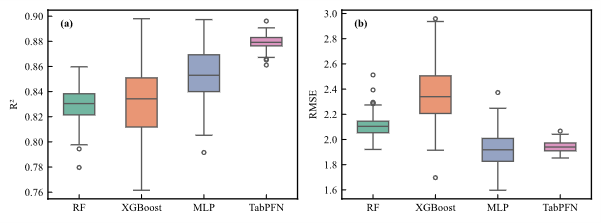

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from scipy.stats import ttest_ind  # 添加统计检验模块
import matplotlib
matplotlib.use('TkAgg')
config = {
    "font.family": 'serif',
    "font.size":24,  # 相当于小四大小
    "mathtext.fontset": 'stix',  # matplotlib渲染数学字体时使用的字体，和Times New Roman差别不大
    "font.serif": ['Times New Roman'],  # 宋体
    'axes.unicode_minus': False  # 处理负号，即-号
}
rcParams.update(config)

# 读取Excel数据
file_path = r'D:\研究生学习\博士学习\论文3\数据集\工业分析元素分析焦油产率数据收集.xlsx'
df = pd.read_excel(file_path, sheet_name="分盆地汇总")

# 确保数据列名正确（请根据实际Excel列名调整）
# 假设盆地列名为'盆地'，焦油产率列名为'焦油产率'
basin_col = '盆地'
target_col = 'Tar'

# 创建画布
plt.figure(figsize=(8, 6))  # 调整为更符合期刊比例的尺寸

# 绘制小提琴图（替换箱型图，使用顶级期刊配色方案）
# 自定义一组配色，可根据实际盆地数量调整颜色数量
#custom_palette = ["#5EABD6", "#FEFBC7", "#748873"]
custom_palette = ["#299D92", "#E8C56B", "#E66F51"]
violinplot = sns.violinplot(
    x=basin_col,
    y=target_col,
    data=df,
    palette=custom_palette,  # 使用自定义配色
    width=0.6,  # 小提琴图适当增加宽度
    linewidth=1.0,
    inner=None,  # 关闭内置四分位线，由箱型图显示
    density_norm="width"
)

# 添加叠加的箱型图
boxplot = sns.boxplot(
    x=basin_col,
    y=target_col,
    data=df,
    width=0.2,
    boxprops={'facecolor': 'white', 'edgecolor': 'black', 'zorder': 2},
    whiskerprops={'color': 'black', 'zorder': 2},
    medianprops={'color': 'black', 'linewidth': 1.5, 'zorder': 3},
    capprops={'color': 'black', 'zorder': 2},
    showfliers=False
)
# 添加优化后的散点图（虚化效果）
#custom_palette2= ["#9ECAD6", "#748DAE", "#F5CBCB"]
custom_palette2= ["#000000", "#000000", "#000000"]
stripplot = sns.stripplot(
    x=basin_col,
    y=target_col,
    data=df,
    palette=custom_palette2,  # 使用与小提琴图相同的自定义配色
    alpha=0.7,  # 高度虚化
    size=4,
    jitter=0.2,  # 适度抖动
    edgecolor="none",  # 去除边缘线增强虚化效果
    hue=basin_col,  # 按盆地分组设置颜色
    dodge=False  # 不分散散点
)

'''# 添加统计信息（中位数标注）
medians = df.groupby([basin_col])[target_col].median().values
median_labels = [f'{m:.2f}' for m in medians]

pos = range(len(medians))
for tick, label in zip(pos, violinplot.get_xticklabels()):  # 将boxplot改为violinplot
    violinplot.text(pos[tick], medians[tick] + 0.5, median_labels[tick],  # 将boxplot改为violinplot
                 horizontalalignment='center', size=12, weight='bold', color='#000000')
'''
# 添加散点图后执行统计分析
# 获取所有盆地名称
basins = df[basin_col].unique()
basin_pairs = [(i, j) for i in range(len(basins)) for j in range(i + 1, len(basins))]

# 计算显著性差异
p_values = []
for i, j in basin_pairs:
    group1 = df[df[basin_col] == basins[i]][target_col]
    group2 = df[df[basin_col] == basins[j]][target_col]
    stat, p = ttest_ind(group1, group2, equal_var=False)  # Welch's t-test
    p_values.append((i, j, p))

# 设置显著性水平阈值
alpha = 0.05
# 获取y轴最大值用于定位显著性线
max_y = df[target_col].max()
y_offset = max_y * 0.05  # 线与图的间距
line_height_increment = max_y * 0.15  # 线之间的垂直间距

# 绘制显著性差异线
for idx, (i, j, p) in enumerate(p_values):
    # 确定显著性标记
    if p < 0.001:
        sig_text = f'p < {p:.2e}'
    elif p < 0.01:
        sig_text = f'p = {p:.3f}'
    else:
        sig_text = f'p = {p:.2f}'

    # 计算垂直位置（修复y_pos未定义错误）
    y_pos = max_y + y_offset + idx * line_height_increment
    
    # 绘制连接线
    plt.plot([i, i], [max_y + y_offset + idx * line_height_increment - 0.2 * line_height_increment, y_pos],
             color='red', linewidth=1)
    plt.plot([i, j], [y_pos, y_pos], color='red', linewidth=1)
    plt.plot([j, j], [max_y + y_offset + idx * line_height_increment - 0.2 * line_height_increment, y_pos],
             color='red', linewidth=1)

    # 添加显著性标记，将文本颜色设置为红色，移到线下方并增大字体
    plt.text((i + j) / 2, y_pos - 0.03 * max_y, sig_text, ha='center', va='top', fontsize=20, fontweight='normal', color='red')
# 设置图表标签和标题
# `fontweight='bold'` 表示将文本的字体设置为粗体。以下代码将 X 轴和 Y 轴标签的字体设置为 12 号粗体。
plt.xlabel('Basin type', fontsize=24, fontweight='normal')
plt.ylabel('Tar (%)', fontsize=24, fontweight='normal')

# 设置刻度线朝内，调整刻度线上的轴数字字体大小为 11
plt.tick_params(axis='both', direction='in', length=4, width=0.8, labelsize=24)
# 设置坐标轴边线宽度
for spine in plt.gca().spines.values():
    spine.set_linewidth(1.2)

# 优化布局
plt.tight_layout(pad=0.5)

# 保存图表（支持多种格式）
plt.savefig("D:\研究生学习\博士学习\论文3\绘图\盆地箱型小提琴图焦油产率.svg")

# 显示图表
plt.show()

C:\Users\38310\AppData\Local\Temp\ipykernel_25980\2241602206.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  violinplot = sns.violinplot(


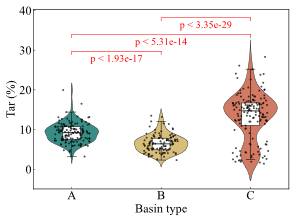

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from scipy.stats import ttest_ind
import matplotlib
import numpy as np

matplotlib.use('TkAgg')

config = {
    "font.family": 'serif',
    "font.size": 20,
    "mathtext.fontset": 'stix',
    "font.serif": ['Times New Roman'],
    'axes.unicode_minus': False
}
rcParams.update(config)

# 读取Excel数据
file_path = r'D:\研究生学习\博士学习\论文3\数据集\工业分析元素分析焦油产率数据收集.xlsx'
df = pd.read_excel(file_path, sheet_name="分盆地汇总")

# 确保数据列名正确
basin_col = '盆地'
target_cols = ['A', 'V', 'FC', 'H', 'O', 'N']  # 要绘制的列名

# 创建画布和子图（2行3列），设置画布宽高比为4:3
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # 将二维数组展平为一维

# 自定义配色方案
custom_palette = ["#299D92", "#E8C56B", "#E66F51"] # 用于小提琴图
custom_palette2 = ["#000000", "#000000", "#000000"]  # 用于散点图

# 对每个目标列绘制子图
for i, target_col in enumerate(target_cols):
    ax = axes[i]
    
    # 绘制小提琴图
    sns.violinplot(
        x=basin_col,
        y=target_col,
        data=df,
        palette=custom_palette,
        width=0.6,
        linewidth=1.0,
        inner=None,
        density_norm="width",
        ax=ax
    )
    
    # 添加叠加的箱型图
    sns.boxplot(
        x=basin_col,
        y=target_col,
        data=df,
        width=0.2,
        boxprops={'facecolor': 'white', 'edgecolor': 'black', 'zorder': 2},
        whiskerprops={'color': 'black', 'zorder': 2},
        medianprops={'color': 'black', 'linewidth': 1.5, 'zorder': 3},
        capprops={'color': 'black', 'zorder': 2},
        showfliers=False,
        ax=ax
    )
    
    # 添加散点图
    sns.stripplot(
        x=basin_col,
        y=target_col,
        data=df,
        palette=custom_palette2,
        alpha=0.6,
        size=4,
        jitter=0.2,
        edgecolor="none",
        hue=basin_col,
        dodge=False,
        ax=ax
    )
    
    # 计算显著性差异并绘制显著性线
    basins = df[basin_col].unique()
    basin_pairs = [(idx1, idx2) for idx1 in range(len(basins)) for idx2 in range(idx1 + 1, len(basins))]
    
    p_values = []
    for idx1, idx2 in basin_pairs:
        group1 = df[df[basin_col] == basins[idx1]][target_col]
        group2 = df[df[basin_col] == basins[idx2]][target_col]
        stat, p = ttest_ind(group1, group2, equal_var=False)
        p_values.append((idx1, idx2, p))
    
    # 设置显著性水平阈值
    alpha = 0.05
    max_y = df[target_col].max()
    # 进一步增大初始偏移量，使第一条线离图表更远
    y_offset = max_y * 0.1  # 原0.1调整为0.2
    # 增大线之间的间距，避免上下线过近
    line_height_increment = max_y * 0.15  # 原0.15调整为0.2

    
    # 绘制显著性差异线
    for idx, (idx1, idx2, p) in enumerate(p_values):
        if p < 0.001:
            sig_text = f'$\mathregular{{p < {p:.2e}}}$'
        elif p < 0.01:
            sig_text = f'p = {p:.3f}'
        elif p < 0.05:
            sig_text = f'p = {p:.2f}'
        else:
            sig_text = 'ns'  # 不显著时用 'ns' 表示
        
        y_pos = max_y + y_offset + idx * line_height_increment
        
        ax.plot([idx1, idx1], [max_y + y_offset + idx * line_height_increment - 0.2 * line_height_increment, y_pos],
                color='red', linewidth=1)
        ax.plot([idx1, idx2], [y_pos, y_pos], color='red', linewidth=1)
        ax.plot([idx2, idx2], [max_y + y_offset + idx * line_height_increment - 0.2 * line_height_increment, y_pos],
                color='red', linewidth=1)
        
        if p < 0.001:
            ax.text((idx1 + idx2) / 2, y_pos - 0.02 * max_y, sig_text, ha='center', va='top', fontsize=18, fontweight='normal', color='red')
        else:
            ax.text((idx1 + idx2) / 2, y_pos - 0.02 * max_y, sig_text, ha='center', va='top', fontsize=18, fontweight='normal')
    
    

    # 设置子图标题和标签
    # ax.set_title(target_col, fontsize=14, fontweight='normal')
    ax.set_xlabel('Basin type', fontsize=24, fontweight='normal')
    # 此处可根据需要自定义Y轴标签，示例中先定义一个映射字典
    label_mapping = {
        'A': '$\mathregular{A_d}$(%)',
        'V': '$\mathregular{V_d}$$\mathregular{_a}$$\mathregular{_f}$(%)',
        'FC':'$\mathregular{FC_a}$$\mathregular{_d}$(%)',
        'H': '$\mathregular{H_d}$$\mathregular{_a}$$\mathregular{_f}$(%)',
        'O': '$\mathregular{O_d}$$\mathregular{_a}$$\mathregular{_f}$(%)',
        'N': '$\mathregular{N_d}$$\mathregular{_a}$$\mathregular{_f}$(%)'
    }
    ax.set_ylabel(label_mapping.get(target_col, f'{target_col} (%)'), fontsize=24, fontweight='normal')
    # 在每个图的左上角添加（a）（b）（c）...标记
    marker = chr(ord('a') + i)
    ax.text(0.02, 0.96, f'({marker})', transform=ax.transAxes, fontsize=24, fontweight='normal', va='top')
    # 设置刻度线和坐标轴边线
    ax.tick_params(axis='both', direction='in', length=4, width=0.8, labelsize=24)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    
   
# 优化布局，设置左右间距为0.3，上下间距为0.3，画布边缘内边距为0.5，使图之间更加紧凑
plt.tight_layout(pad=0.9, w_pad=0.3, h_pad=0.3)
# 保存图表
plt.savefig(r"D:\研究生学习\博士学习\论文3\绘图\多指标小提琴箱型图.svg")

# 显示图表
plt.show()

C:\Users\38310\AppData\Local\Temp\ipykernel_25980\595530807.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\38310\AppData\Local\Temp\ipykernel_25980\595530807.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\38310\AppData\Local\Temp\ipykernel_25980\595530807.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\38310\AppData\Local\Temp\ipykernel_25980\595530807.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable 

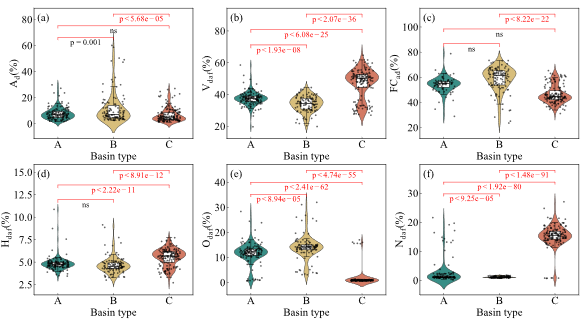